In [374]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Any
from dataclasses import dataclass, field, replace

from scipy.spatial import cKDTree

# Backbone definition

In [12]:
@dataclass(frozen=True)
class BackboneConfig:
    length: float = 100.0 # length of the backbone
    sampling_step: float = 0.5 # distance between samples

    initial_position: tuple[float, float, float] = (0.0, 0.0, 0.0) 
    initial_direction: tuple[float, float, float] = (0.0, 0.0, 1.0)

    curvature_std: float = 0.01 # instensity of the desviation
    max_curvature: float = 0.03 # limit of the curvature
    correlation_length: float = 15.0 # distance where the curvatura mantains the direction

    seed: int = 42

@dataclass
class BackboneGeometry:
    arc_length: np.ndarray #(N,) length of the arc for each sample
    positions: np.ndarray # (N, 3) coordinates at the backbone
    tangents: np.ndarray # (N, 3) unitary tangents
    normals: np.ndarray # (N, 3) first normal direction
    binormals: np.ndarray # (N, 3) second normal direction
    curvature_components: np.ndarray # (N, 2) curvature over normal and binormal
    curvature: np.ndarray # (N, ) norm of both components

In [13]:
def normalize(
    vector: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Returns a normalize copy of a 3D vector

    Parameters
    ----------
    vector
        Array with shape(3,)
    eps
        minimum norm

    Returns
    -------
    np.ndarray
        float64 vector with shape (3,) and norm = 1
    """
    vector = np.asarray(vector, dtype=np.float64)

    if vector.shape != (3,):
        raise ValueError(
            f"vector mush have shape (3,), received {vector.shape}"
        )

    if not np.all(np.isfinite(vector)):
        raise ValueError("vector contains non-finite values")

    norm = np.linalg.norm(vector)

    if norm < eps:
        raise ValueError("cannot normalize a near-zero vector")

    return vector/norm

### Choose perpendicular vector deterministic

In [14]:
def choose_perpendicular_unit_vector(
    direction: np.ndarray,
) -> np.ndarray:
    """
    Build a unitary normal vector to a 3D direction

    It is deterministic to avid differences between executions
    """

    direction = normalize(direction)

    coordinate_axes = np.eye(3, dtype=np.float64)

    # Choose the less aligned axis with the direction
    reference = coordinate_axes[
        np.argmin(np.abs(coordinate_axes @ direction))
    ]

    perpendicular = reference - np.dot(reference, direction) * direction

    return normalize(perpendicular)

### Discretize the length of the arc

In [15]:
def build_arc_length_grid(
    length: float,
    sampling_step: float,
) -> np.ndarray:
    """
    Create a discretization with length extension

    'sampling_step' is interpreted as the maximum separation, not as the exact separation
    """

    n_segments = int(np.ceil(length / sampling_step))
    n_points = n_segments + 1

    return np.linspace(
        0.0,
        length,
        n_points,
        dtype=np.float64,
    )

### Generate smooth field for the curvature

In [16]:
def generate_smooth_curvature_field(
    arc_length: np.ndarray,
    curvature_std: float,
    max_curvature: float,
    correlation_length: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate two components correlated of curvature

    Parameters
    ----------
    arc_length
        Length of the arcs, shape (N,)
    curvature_std
        Typical deviation of each component
    max_curvature
        Maximum allowed curvature
    correlation_length
        Correlation charasteristic length
    rng
        Random number generator

    Returns
    -------
    np.ndarray
        Curvature components with shape (N-1, 2)
        Each row corresponds with and interval of the backbone
    """

    arc_length = np.asarray(arc_length, dtype=np.float64)

    if arc_length.ndim != 1 or len(arc_length) < 3:
        raise ValueError(
            "arc_length mus be one-dimensional with at least 3 points"
        )

    segment_lengths = np.diff(arc_length)

    if np.any(segment_lengths <= 0.0):
        raise ValueError("arc_length must be strictly increasing")

    n_segments = len(segment_lengths)
    field = np.zeros((n_segments, 2), dtype=np.float64)

    if curvature_std == 0.0 or max_curvature == 0.0:
        return field

    # Initialization taken form the stationary distribution

    field[0] = rng.normal(
        loc=0.0,
        scale=curvature_std,
        size=2,
    )

    for index in range(1, n_segments):
        step = segment_lengths[index]

        alpha = np.exp(-step / correlation_length)
        innovation_scale = curvature_std * np.sqrt(1.0 - alpha**2)

        field[index] = (
            alpha * field[index - 1]
            + rng.normal(
                loc=0.0,
                scale=innovation_scale,
                size=2,
            )
        )

    magnitudes = np.linalg.norm(field, axis=1)
    exceeding = magnitudes > max_curvature

    if np.any(exceeding):
        field[exceeding] *= (
            max_curvature / magnitudes[exceeding]
        )[:, None]

    return field

### Rodrigues rotation

In [17]:
def rotate_vector(
    vector: np.ndarray,
    rotation_vector: np.ndarray,
    eps: float = 1e-12
) -> np.ndarray:

    """
    Rotate a vector by an axis-angle representation

    The diretion of rotation_vector is the y axis and the norm the angles in radians
    """
    vector = np.asarray(vector, dtype=np.float64)
    rotation_vector = np.asarray(
        rotation_vector,
        dtype=np.float64,
    )

    if vector.shape != (3,):
        raise ValueError("vector must have shape (3,)")

    if rotation_vector.shape != (3,):
        raise ValueError("rotation_vector must have shape (3,)")

    angle = np.linalg.norm(rotation_vector)

    if angle < eps:
        return vector.copy()

    axis = rotation_vector / angle

    return (
        vector * np.cos(angle)
        + np.cross(axis, vector) * np.sin(angle)
        + axis * np.dot(axis, vector) * (1.0 - np.cos(angle))
    )

### Reortonormalization of the frame

In [18]:
def orthonormalize_frame(
    tangent: np.ndarray,
    normal: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build an orthonormal frame from the tangent and the normal
    """
    tangent = normalize(tangent)

    normal = (
        np.asarray(normal, dtype=np.float64)
        - np.dot(normal, tangent) * tangent
    )

    normal = normalize(normal)

    binormal = normalize(np.cross(tangent, normal))

    normal = normalize(np.cross(binormal, tangent))

    return tangent, normal, binormal

### Integration of the backbone

In [28]:
def integrate_backbone(
    arc_length: np.ndarray,
    curvature_field: np.ndarray,
    initial_position: np.ndarray,
    initial_direction: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Integrate positions and frams from the curvature field

    Parameters
    ----------
    arc_length
        shape(N,)
    curvature_field
        Shape (N -1, 2) First component rotates to the normal
        and the second to the binormal
    initial_position
        Shape (3,)
    initial_direction
        Shape (3,)

    Returns
    -------
    positions, tangents, normals, binormas
        Four arrays with shape (N, 3)
    """
    arc_length = np.asarray(arc_length, dtype=np.float64)
    curvature_field = np.asarray(
        curvature_field,
        dtype=np.float64,
    )
    initial_position = np.asarray(
        initial_position,
        dtype=np.float64,
    )
    initial_direction = np.asarray(
        initial_direction,
        dtype=np.float64,
    )

    n_points = len(arc_length)

    if curvature_field.shape != (n_points - 1, 2):
        raise ValueError(
            "curvature_field must have shape "
            f"({n_points - 1}, 2), received {curvature_field.shape}"
        )

    if initial_position.shape != (3,):
        raise ValueError("initial_position must have shape (3,)")

    tangent = normalize(initial_direction)
    normal = choose_perpendicular_unit_vector(tangent)
    tangent, normal, binormal = orthonormalize_frame(
        tangent,
        normal,
    )

    positions = np.empty((n_points, 3), dtype=np.float64)
    tangents = np.empty((n_points, 3), dtype=np.float64)
    normals = np.empty((n_points, 3), dtype=np.float64)
    binormals = np.empty((n_points, 3), dtype=np.float64)

    positions[0] = initial_position
    tangents[0] = tangent
    normals[0] = normal
    binormals[0] = binormal

    for index in range(n_points - 1):
        step = arc_length[index + 1] - arc_length[index]

        curvature_normal = curvature_field[index, 0]
        curvature_binormal = curvature_field[index, 1]

        # We want:
        # dt/ds = curvature_normal * normal
        #       + curvature_binormal * binormal
        #
        # Angular vector that produce that derivative is:
        angular_velocity = (
            curvature_normal * binormal
            - curvature_binormal * normal
        )

        half_rotation = 0.5 * step * angular_velocity
        full_rotation = step * angular_velocity

        # Tangent in the middle poiunt for updating the position
        midpoint_tangent = normalize(
            rotate_vector(tangent, half_rotation)
        )

        positions[index + 1] = (
            positions[index] + step * midpoint_tangent
        )

        tangent = rotate_vector(tangent, full_rotation)
        normal = rotate_vector(normal, full_rotation)

        tangent, normal, binormal = orthonormalize_frame(
            tangent,
            normal,
        )

        tangents[index + 1] = tangent
        normals[index + 1] = normal
        binormals[index + 1] = binormal

    return positions, tangents, normals, binormals

# Generate backbone

In [30]:
def generate_backbone(
    config: BackboneConfig,
) -> BackboneGeometry:
    """
    Generate a full complete and reproducible
    """

    arc_length = build_arc_length_grid(
        length=config.length,
        sampling_step=config.sampling_step,
    )

    rng = np.random.default_rng(config.seed)

    segment_curvature_components = generate_smooth_curvature_field(
        arc_length=arc_length,
        curvature_std=config.curvature_std,
        max_curvature=config.max_curvature,
        correlation_length=config.correlation_length,
        rng=rng,
    )

    positions, tangents, normals, binormals = integrate_backbone(
        arc_length=arc_length,
        curvature_field=segment_curvature_components,
        initial_position=np.asarray(
            config.initial_position,
            dtype=np.float64,
        ),
        initial_direction=np.asarray(
            config.initial_direction,
            dtype=np.float64,
        ),
    )

    # We transform the field per segment into a field per node
    curvature_components = np.empty(
        (len(arc_length), 2),
        dtype=np.float64,
    )
    curvature_components[:-1] = segment_curvature_components
    curvature_components[-1] = segment_curvature_components[-1]

    curvature = np.linalg.norm(
        curvature_components,
        axis=1,
    )

    return BackboneGeometry(
        arc_length=arc_length,
        positions=positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        curvature_components=curvature_components,
        curvature=curvature,
    )

In [36]:
def validate_backbone(
    backbone: BackboneGeometry,
    config: BackboneConfig,
    atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Validate shape, values and geometrical properties

    Returns diagnostic metrics and launch ValueError if it finds structural inconsistencies
    """
    arrays_3d = {
        "positions": backbone.positions,
        "tangents": backbone.tangents,
        "normals": backbone.normals,
        "binormals": backbone.binormals,
    }

    n_points = len(backbone.arc_length)

    if backbone.arc_length.shape != (n_points,):
        raise ValueError("invalid arc_length shape")
    
    for name, array in arrays_3d.items():
        if array.shape != (n_points, 3):
            raise ValueError(
                f"{name} must have shape ({n_points}, 3)"
            )

    if backbone.curvature_components.shape != (n_points, 2):
        raise ValueError(
            "curvature_components has an invalidad shape"
        )

    if backbone.curvature.shape != (n_points,):
        raise ValueError("curvature has an invalid shape")

    arrays_to_check = [
        backbone.arc_length,
        backbone.positions,
        backbone.tangents,
        backbone.normals,
        backbone.binormals,
        backbone.curvature_components,
        backbone.curvature,
    ]

    all_finite = all(
        np.all(np.isfinite(array))
        for array in arrays_to_check
    )

    segment_lengths = np.linalg.norm(
        np.diff(backbone.positions, axis=0),
        axis=1,
    )
    expected_segment_lengths = np.diff(backbone.arc_length)

    tangent_norm_error = np.max(
        np.abs(np.linalg.norm(backbone.tangents, axis=1) - 1.0)
    )
    normal_norm_error = np.max(
        np.abs(np.linalg.norm(backbone.normals, axis=1) - 1.0)
    )
    binormal_norm_error = np.max(
        np.abs(np.linalg.norm(backbone.binormals, axis=1) - 1.0)
    )

    tangent_normal_dot = np.sum(
        backbone.tangents * backbone.normals,
        axis=1,
    )
    tangent_binormal_dot = np.sum(
        backbone.tangents * backbone.binormals,
        axis=1,
    )
    normal_binormal_dot = np.sum(
        backbone.normals * backbone.binormals,
        axis=1,
    )

    max_orthogonality_error = max(
        np.max(np.abs(tangent_normal_dot)),
        np.max(np.abs(tangent_binormal_dot)),
        np.max(np.abs(normal_binormal_dot)),
    )

    reconstructed_binormals = np.cross(
        backbone.tangents,
        backbone.normals,
    )
    handedness_error = np.max(
        np.linalg.norm(
            reconstructed_binormals - backbone.binormals,
            axis=1,
        )
    )

    initial_position_error = np.linalg.norm(
        backbone.positions[0]
        - np.asarray(config.initial_position, dtype=np.float64)
    )

    expected_initial_direction = normalize(
        np.asarray(config.initial_direction, dtype=np.float64)
    )
    initial_direction_error = np.linalg.norm(
        backbone.tangents[0] - expected_initial_direction
    )

    max_step_error = np.max(
        np.abs(segment_lengths - expected_segment_lengths)
    )

    maximum_curvature = float(np.max(backbone.curvature))

    checks = {
        "all_finite": bool(all_finite),
        "arc_length_starts_at_zero": bool(
            np.isclose(backbone.arc_length[0], 0.0, atol=atol)
        ),
        "arc_length_ends_at_length": bool(
            np.isclose(
                backbone.arc_length[-1],
                config.length,
                atol=atol,
            )
        ),
        "steps_are_correct": bool(max_step_error <= atol),
        "frame_vectors_are_unitary": bool(
            max(
                tangent_norm_error,
                normal_norm_error,
                binormal_norm_error,
            ) <= atol
        ),
        "frame_is_orthogonal": bool(
            max_orthogonality_error <= atol
        ),
        "frame_is_right_handed": bool(
            handedness_error <= atol
        ),
        "initial_position_is_correct": bool(
            initial_position_error <= atol
        ),
        "initial_direction_is_correct": bool(
            initial_direction_error <= atol
        ),
        "curvature_below_limit": bool(
            maximum_curvature <= config.max_curvature + atol
        ),
    }

    metrics = {
        "n_points": n_points,
        "actual_sampling_step": float(
            expected_segment_lengths[0]
        ),
        "max_step_error": float(max_step_error),
        "max_frame_norm_error": float(
            max(
                tangent_norm_error,
                normal_norm_error,
                binormal_norm_error,
            )
        ),
        "max_orthogonality_error": float(
            max_orthogonality_error
        ),
        "max_handedness_error": float(handedness_error),
        "max_curvature": maximum_curvature,
        "mean_curvature": float(np.mean(backbone.curvature)),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }


## Visualization

In [37]:
def set_axes_equal_3d(ax) -> None:
    """
    Ajusta los tres ejes a la misma escala visual.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    centers = np.array([
        np.mean(x_limits),
        np.mean(y_limits),
        np.mean(z_limits),
    ])

    radius = 0.5 * max(
        x_limits[1] - x_limits[0],
        y_limits[1] - y_limits[0],
        z_limits[1] - z_limits[0],
    )

    ax.set_xlim3d(centers[0] - radius, centers[0] + radius)
    ax.set_ylim3d(centers[1] - radius, centers[1] + radius)
    ax.set_zlim3d(centers[2] - radius, centers[2] + radius)

def plot_backbone_3d(
    backbone: BackboneGeometry,
    frame_stride: int = 20,
    frame_scale: float = 2.0,
):
    """
    Representa el backbone y una selección de frames locales.
    """
    if frame_stride <= 0:
        raise ValueError("frame_stride must be greater than zero")

    positions = backbone.positions

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        linewidth=2.0,
        color="black",
        label="backbone",
    )

    ax.scatter(
        positions[0, 0],
        positions[0, 1],
        positions[0, 2],
        color="green",
        s=70,
        label="start",
    )

    ax.scatter(
        positions[-1, 0],
        positions[-1, 1],
        positions[-1, 2],
        color="red",
        s=70,
        label="end",
    )

    selected = np.arange(
        0,
        len(positions),
        frame_stride,
    )

    ax.quiver(
        positions[selected, 0],
        positions[selected, 1],
        positions[selected, 2],
        backbone.normals[selected, 0],
        backbone.normals[selected, 1],
        backbone.normals[selected, 2],
        length=frame_scale,
        normalize=True,
        color="tab:blue",
        alpha=0.7,
    )

    ax.quiver(
        positions[selected, 0],
        positions[selected, 1],
        positions[selected, 2],
        backbone.binormals[selected, 0],
        backbone.binormals[selected, 1],
        backbone.binormals[selected, 2],
        length=frame_scale,
        normalize=True,
        color="tab:orange",
        alpha=0.7,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

## Diagnostics

In [38]:
def plot_backbone_diagnostics(
    backbone: BackboneGeometry,
):
    """
    Representa curvatura, separación y componentes de la tangente.
    """
    segment_lengths = np.linalg.norm(
        np.diff(backbone.positions, axis=0),
        axis=1,
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 9),
        sharex=False,
    )

    axes[0].plot(
        backbone.arc_length,
        backbone.curvature,
        color="tab:purple",
    )
    axes[0].set_ylabel("curvature")
    axes[0].set_title("Backbone curvature")

    axes[1].plot(
        backbone.arc_length[1:],
        segment_lengths,
        color="tab:green",
    )
    axes[1].set_ylabel("segment length")
    axes[1].set_title("Distance between consecutive samples")

    component_names = ["tx", "ty", "tz"]

    for component, name in enumerate(component_names):
        axes[2].plot(
            backbone.arc_length,
            backbone.tangents[:, component],
            label=name,
        )

    axes[2].set_xlabel("arc length")
    axes[2].set_ylabel("tangent component")
    axes[2].set_title("Tangent components")
    axes[2].legend()

    plt.tight_layout()

    return fig, axes

# First execution

In [47]:
backbone_config = BackboneConfig(
    length=100.0,
    sampling_step=0.5,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.3,
    max_curvature=0.1,
    correlation_length=15.0,
    seed=42,
)

backbone = generate_backbone(backbone_config)

validation = validate_backbone(
    backbone=backbone,
    config=backbone_config,
)

validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'arc_length_starts_at_zero': True,
  'arc_length_ends_at_length': True,
  'steps_are_correct': True,
  'frame_vectors_are_unitary': True,
  'frame_is_orthogonal': True,
  'frame_is_right_handed': True,
  'initial_position_is_correct': True,
  'initial_direction_is_correct': True,
  'curvature_below_limit': True},
 'metrics': {'n_points': 201,
  'actual_sampling_step': 0.5,
  'max_step_error': 3.219646771412954e-15,
  'max_frame_norm_error': 2.220446049250313e-16,
  'max_orthogonality_error': 1.1102230246251565e-16,
  'max_handedness_error': 3.379462171739212e-16,
  'max_curvature': 0.10000000000000003,
  'mean_curvature': 0.09490431859105489}}

(<Figure size 1000x900 with 3 Axes>,
 array([<Axes: title={'center': 'Backbone curvature'}, ylabel='curvature'>,
        <Axes: title={'center': 'Distance between consecutive samples'}, ylabel='segment length'>,
        <Axes: title={'center': 'Tangent components'}, xlabel='arc length', ylabel='tangent component'>],
       dtype=object))

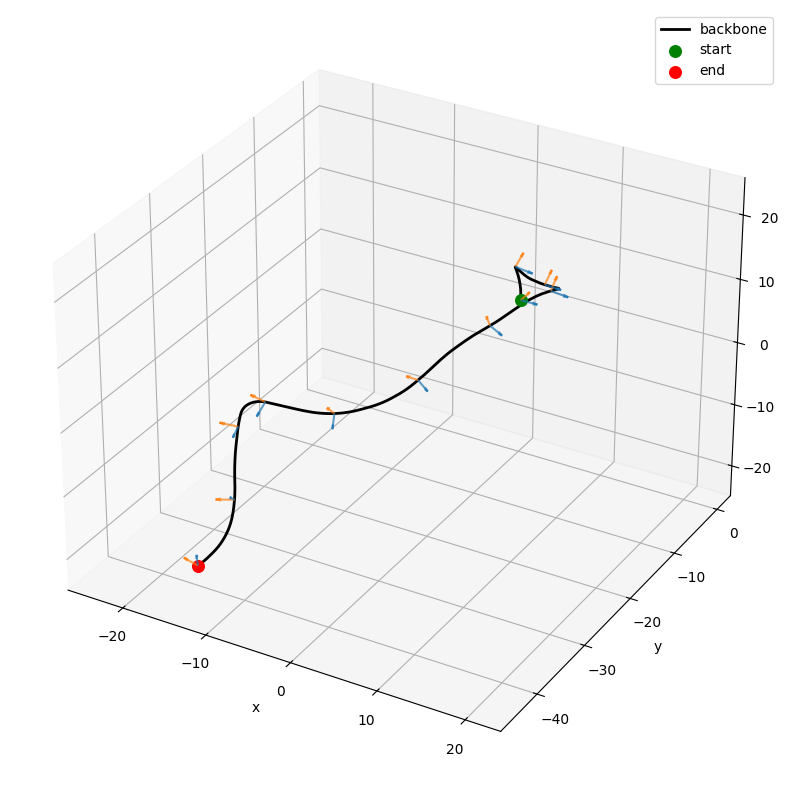

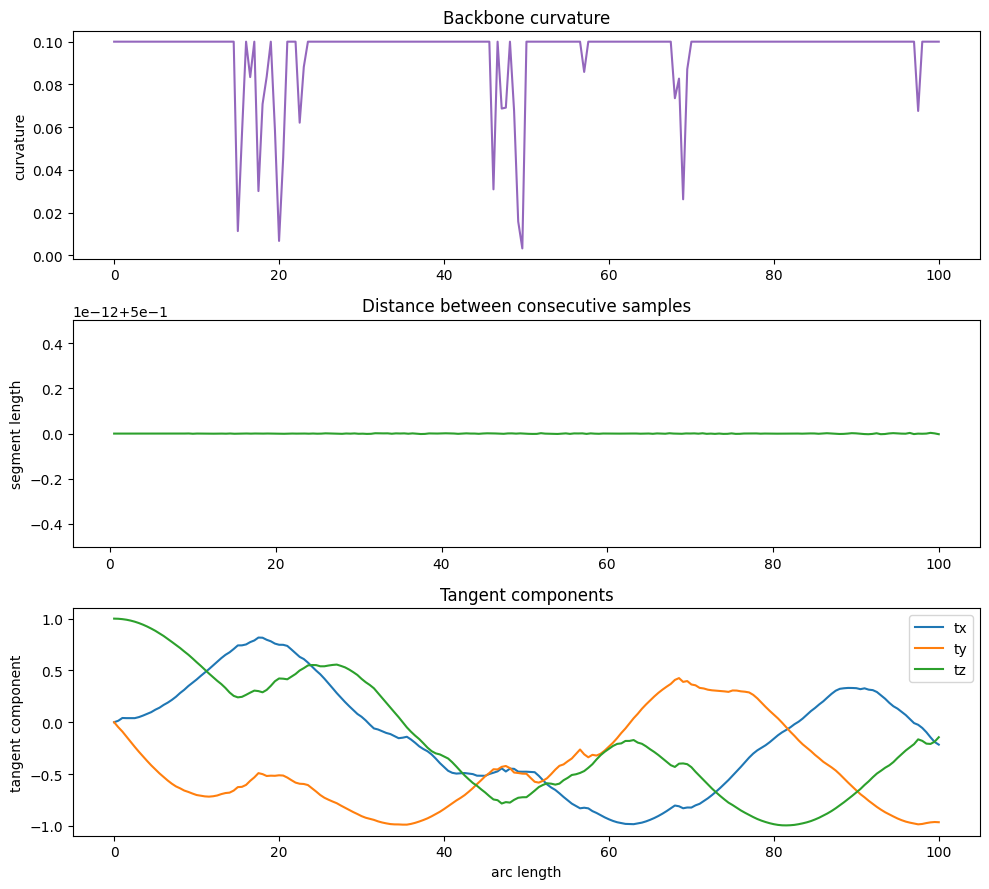

In [48]:
plot_backbone_3d(
    backbone,
    frame_stride=20,
    frame_scale=2.0,
)

plot_backbone_diagnostics(backbone)

# Straight case

In [41]:
straight_config = BackboneConfig(
    length=100.0,
    sampling_step=0.5,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.0,
    max_curvature=0.0,
    correlation_length=15.0,
    seed=42,
)

straight_backbone = generate_backbone(straight_config)

straight_validation = validate_backbone(
    backbone=straight_backbone,
    config=straight_config,
)

straight_validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'arc_length_starts_at_zero': True,
  'arc_length_ends_at_length': True,
  'steps_are_correct': True,
  'frame_vectors_are_unitary': True,
  'frame_is_orthogonal': True,
  'frame_is_right_handed': True,
  'initial_position_is_correct': True,
  'initial_direction_is_correct': True,
  'curvature_below_limit': True},
 'metrics': {'n_points': 201,
  'actual_sampling_step': 0.5,
  'max_step_error': 0.0,
  'max_frame_norm_error': 0.0,
  'max_orthogonality_error': 0.0,
  'max_handedness_error': 0.0,
  'max_curvature': 0.0,
  'mean_curvature': 0.0}}

In [42]:
expected_positions = np.column_stack([
    np.zeros_like(straight_backbone.arc_length),
    np.zeros_like(straight_backbone.arc_length),
    straight_backbone.arc_length,
])

np.allclose(
    straight_backbone.positions,
    expected_positions,
    atol=1e-10,
)

True

# Helix configuration

In [50]:
@dataclass(frozen=True)
class HelixConfig:
    rise: float = 1.0 # distance between subunits along the backbone arc
    twist_rad: float = np.deg2rad(30.0) # rotation per subunit around the backbone
    radius: float = 2.0 # distance from the backbone to each subunit
    initial_phase_rad: float = 0.0 # angular orientation of the first subunit
    strand_id: int = 0 

### Output structure

In [75]:
@dataclass
class CleanHelixGeometry:
    positions: np.ndarray
    backbone_positions: np.ndarray

    tangents: np.ndarray
    normals: np.ndarray
    binormals: np.ndarray

    arc_length: np.ndarray
    sequence_index: np.ndarray
    strand_id: np.ndarray

    phase_rad: np.ndarray
    radius: np.ndarray
    backbone_curvature: np.ndarray

    true_edge_index: np.ndarray
    local_rise: np.ndarray
    local_twist_rad: np.ndarray

    global_rise: float
    global_twist_rad: float
    global_radius: float
    n_strands: int

### Validation of the configuration

In [52]:
def validate_helix_config(
    config: HelixConfig,
    backbone: BackboneGeometry,
) -> None:
    """
    Validate the helicoidal configuration respect to the backbone
    """
    scalar_values = {
        "rise": config.rise,
        "twist_rad": config.twist_rad,
        "radius": config.radius,
        "initial_phase_rad": config.initial_phase_rad,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.rise <= 0.0:
        raise ValueError("rise must be greater than zero")

    if config.radius <= 0.0:
        raise ValueError("radius must be greater than zero")

    if not isinstance(config.strand_id, (int, np.integer)):
        raise ValueError("strand_id must be an integer")

    total_length = float(backbone.arc_length[-1])

    if config.rise > total_length:
        raise ValueError(
            "rise is greater than the total backbone length"
        )

    n_nodes = int(np.floor(total_length / config.rise)) + 1

    if n_nodes < 3:
        raise ValueError(
            "the backbone must contain at least three helix nodes"
        )


### Subunit axial positions

In [53]:
def build_helix_arc_length_grid(
    backbone_length: float,
    rise: float,
) -> np.ndarray:
    """
    Calculate the positions of the subunits over the backbone

    The last subunit is included only if it is not over the available length
    """

    if backbone_length <= 0.0:
        raise ValueError(
            "backbone_length must be greater than zero"
        )

    if rise <= 0.0:
        raise ValueError("rise must be greater than zero")

    n_nodes = int(np.floor(backbone_length / rise)) + 1

    return (
        np.arange(n_nodes, dtype=np.float64)
        * np.float64(rise)
    )

### Vectorized interpolation

In [54]:
def interpolate_vector_field(
    source_arc_length: np.ndarray,
    source_values: np.ndarray,
    target_arc_length: np.ndarray,
) -> np.ndarray:
    """
    Interpolate a vector field defined over the length of the arc

    Parameters
    ----------
    source_arc_length
        Shape (M,)
    source_values
        Shape(M, D)
    target_arc_length
        Shape (N,)

    Returns
    -------
    np.ndarray
        Interpolate field with shape (N, D)
    """
    source_arc_length = np.asarray(
        source_arc_length,
        dtype=np.float64,
    )
    source_values = np.asarray(
        source_values,
        dtype=np.float64,
    )
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if source_arc_length.ndim != 1:
        raise ValueError(
            "source_arc_length must be one-dimensional"
        )

    if target_arc_length.ndim != 1:
        raise ValueError(
            "target_arc_length mus be one-dimensional"
        )
    
    if source_values.ndim != 2:
        raise ValueError("source_values must be two-dimensional")

    if len(source_arc_length) != len(source_values):
        raise ValueError(
            "source_arc_length and source_values must have "
            "the same first dimension"
        )

    if np.any(np.diff(source_arc_length) <= 0.0):
        raise ValueError(
            "source_arc_length must be strictly increasing"
        )

    if target_arc_length[0] < source_arc_length[0]:
        raise ValueError(
            "target_arc_length begins outside the source interval"
        )

    if target_arc_length[-1] > source_arc_length[-1]:
        raise ValueError(
            "target_arc_length ends outside the source interval"
        )

    output = np.empty(
        (len(target_arc_length), source_values.shape[1]),
        dtype=np.float64,
    )

    for component in range(source_values.shape[1]):
        output[:, component] = np.interp(
            target_arc_length,
            source_arc_length,
            source_values[:, component],
        )

    return output

### Scalar field interpolation

In [55]:
def interpolate_scalar_field(
    source_arc_length: np.ndarray,
    source_values: np.ndarray,
    target_arc_length: np.ndarray,
) -> np.ndarray:
    """
    Interpolate a scalar field over length of the arc
    """
    source_arc_length = np.asarray(
        source_arc_length,
        dtype=np.float64,
    )
    source_values = np.asarray(
        source_values,
        dtype=np.float64,
    )
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if source_arc_length.ndim != 1:
        raise ValueError(
            "source_arc_length must be one-dimensional"
        )

    if source_values.shape != source_arc_length.shape:
        raise ValueError(
            "source_values and source_arc_length must have "
            "the same shape"
        )

    if target_arc_length.ndim != 1:
        raise ValueError(
            "target_arc_length must be one-dimensional"
        )

    if np.any(np.diff(source_arc_length) <= 0.0):
        raise ValueError(
            "source_arc_length must be strictly increasing"
        )

    if (
        target_arc_length[0] < source_arc_length[0]
        or target_arc_length[-1] > source_arc_length[-1]
    ):
        raise ValueError(
            "target_arc_length is outside the source interval"
        )

    return np.interp(
        target_arc_length,
        source_arc_length,
        source_values,
    )

### Transport the frames over the interpolated tangents

In [69]:
def transport_frame_between_tangents(
    previous_tangent: np.ndarray,
    current_tangent: np.ndarray,
    previous_normal: np.ndarray,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Transport the frame with the minimum rotation between two tangents

    Returns
    -------
    current_tangent, current_normal, current_binormal
        Three vectors with shape (3,)
    """
    previous_tangent = normalize(previous_tangent)
    current_tangent = normalize(current_tangent)
    previous_normal = normalize(previous_normal)

    rotation_axis = np.cross(
        previous_tangent,
        current_tangent,
    )
    axis_norm = np.linalg.norm(rotation_axis)

    tangent_dot = np.clip(
        np.dot(previous_tangent, current_tangent),
        -1.0,
        1.0,
    )

    if axis_norm < eps:
        if tangent_dot > 0.0:
            current_normal = previous_normal.copy()
        else:
            # Exceptional case: tangents closely opposites
            fallback_axis = choose_perpendicular_unit_vector(
                previous_tangent
            )
            current_normal = rotate_vector(
                previous_normal,
                np.pi * fallback_axis,
            )
    else:
        rotation_axis /= axis_norm

        angle = np.arctan2(
            axis_norm,
            tangent_dot,
        )

        current_normal = rotate_vector(
            previous_normal,
            angle * rotation_axis,
        )

    return orthonormalize_frame(
        current_tangent,
        current_normal,
    )

### Reconstruction of the interpolated frame

In [67]:
def build_transported_frames(
    tangents: np.ndarray,
    initial_normal: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build normals and binormals with discrete parallel transport

    Parameters
    ----------
    tangents
        Tangents with shape (N, 3)
    initial_normal
        Normal with the first point, shape (3,)

    Returns
    -------
    normals, binormals
        Two arrays with shape (N, 3)
    """
    tangents = np.asarray(tangents, dtype=np.float64)
    initial_normal = np.asarray(
        initial_normal,
        dtype=np.float64,
    )

    if tangents.ndim != 2 or tangents.shape[1] != 3:
        raise ValueError("tangents must have shape (N, 3)")

    if len(tangents) < 2:
        raise ValueError("at least two tangents are required")

    normalized_tangents = tangents.copy()
    tangent_norms = np.linalg.norm(
        normalized_tangents,
        axis=1,
    )

    if np.any(tangent_norms < 1e-12):
        raise ValueError("tangents contain a near-zero vector")

    normalized_tangents /= tangent_norms[:, None]

    normals = np.empty_like(normalized_tangents)
    binormals = np.empty_like(normalized_tangents)

    first_tangent, first_normal, first_binormal = (
        orthonormalize_frame(
            normalized_tangents[0],
            initial_normal,
        )
    )

    normalized_tangents[0] = first_tangent
    normals[0] = first_normal
    binormals[0] = first_binormal

    for index in range(1, len(normalized_tangents)):
        (
            normalized_tangents[index],
            normals[index],
            binormals[index],
        ) = transport_frame_between_tangents(
            previous_tangent=normalized_tangents[index - 1],
            current_tangent=normalized_tangents[index],
            previous_normal=normals[index - 1],
        )

    return normals, binormals

### Backbone resampling

In [65]:
def resample_backbone(
    backbone: BackboneGeometry,
    target_arc_length: np.ndarray,
) -> BackboneGeometry:
    """
    Evaluate the backbone in the new positions over arc length
    """
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if target_arc_length.ndim != 1:
        raise ValueError(
            "target_arc_length must be one-dimensional"
        )

    if len(target_arc_length) < 2:
        raise ValueError(
            "at least two target points are required"
        )

    if np.any(np.diff(target_arc_length) <= 0.0):
        raise ValueError(
            "target_arc_length must be strictly increasing"
        )

    positions = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.positions,
        target_arc_length=target_arc_length,
    )

    tangents = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.tangents,
        target_arc_length=target_arc_length,
    )

    tangent_norms = np.linalg.norm(tangents, axis=1)

    if np.any(tangent_norms < 1e-12):
        raise ValueError(
            "interpolated tangents contain a near-zero vector"
        )

    tangents /= tangent_norms[:, None]

    initial_normal = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.normals,
        target_arc_length=target_arc_length[:1],
    )[0]

    normals, binormals = build_transported_frames(
        tangents=tangents,
        initial_normal=initial_normal,
    )

    curvature_components = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.curvature_components,
        target_arc_length=target_arc_length,
    )

    curvature = np.linalg.norm(
        curvature_components,
        axis=1,
    )

    return BackboneGeometry(
        arc_length=target_arc_length.copy(),
        positions=positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        curvature_components=curvature_components,
        curvature=curvature,
    )



### Build efficient true edges

In [59]:
def build_bidirectional_chain_edges(
    n_nodes: int,
) -> np.ndarray:
    """
    Build conections directed between consecutive nodes

    Returns
    -------
    np.ndarray
        edge_index with shape (2, 2 * (n_nodes - 1))
    """
    if not isinstance(n_nodes, (int, np.integer)):
        raise ValueError("n_nodes must be an integer")

    if n_nodes < 2:
        raise ValueError("at least two nodes are required")

    source_forward = np.arange(
        0,
        n_nodes - 1,
        dtype=np.int64,
    )
    target_forward = source_forward + 1

    source = np.concatenate([
        source_forward,
        target_forward,
    ])

    target = np.concatenate([
        target_forward,
        source_forward,
    ])

    return np.stack(
        [source, target],
        axis=0,
    )

### Generate helicoidal strand

In [77]:
def generate_single_strand_helix(
    backbone: BackboneGeometry,
    config: HelixConfig,
) -> CleanHelixGeometry:
    """
    Generate a unique helicoidal around the backbone

    The input of the future model will be 'position'. The rest of the fields are
    conservated as supervision and metadata
    """
    validate_helix_config(
        config=config,
        backbone=backbone,
    )

    helix_arc_length = build_helix_arc_length_grid(
        backbone_length=float(backbone.arc_length[-1]),
        rise=config.rise,
    )

    sampled_backbone = resample_backbone(
        backbone=backbone,
        target_arc_length=helix_arc_length,
    )

    n_nodes = len(helix_arc_length)

    sequence_index = np.arange(
        n_nodes,
        dtype=np.int64,
    )

    strand_id = np.full(
        n_nodes,
        config.strand_id,
        dtype=np.int64,
    )

    phase_rad = (
        config.initial_phase_rad
        + sequence_index.astype(np.float64) * config.twist_rad
    )

    radius = np.full(
        n_nodes,
        config.radius,
        dtype=np.float64,
    )

    radial_direction = (
        np.cos(phase_rad)[:, None] * sampled_backbone.normals
        + np.sin(phase_rad[:, None]) * sampled_backbone.binormals
    )

    positions = (
        sampled_backbone.positions
        + radius[:, None] * radial_direction
    )

    true_edge_index = build_bidirectional_chain_edges(
        n_nodes=n_nodes,
    )

    local_rise = np.diff(helix_arc_length)

    local_twist_rad = np.full(
        n_nodes - 1,
        config.twist_rad,
        dtype=np.float64,
    )

    return CleanHelixGeometry(
        positions=positions,
        backbone_positions=sampled_backbone.positions,
        tangents=sampled_backbone.tangents,
        normals=sampled_backbone.normals,
        binormals=sampled_backbone.binormals,
        arc_length=helix_arc_length,
        sequence_index=sequence_index,
        strand_id=strand_id,
        phase_rad=phase_rad,
        radius=radius,
        backbone_curvature=sampled_backbone.curvature,
        true_edge_index=true_edge_index,
        local_rise=local_rise,
        local_twist_rad=local_twist_rad,
        global_rise=float(config.rise),
        global_twist_rad=float(config.twist_rad),
        global_radius=float(config.radius),
        n_strands=1,
    )

In [62]:
def validate_single_strand_helix(
        helix: CleanHelixGeometry,
        config: HelixConfig,
        atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Validate shapes, order, radius, phases, rise and connectivity
    """
    n_nodes = len(helix.positions)

    expected_vector_shapes = {
        "positions": (n_nodes, 3),
        "backbone_positions": (n_nodes, 3),
        "tangents": (n_nodes, 3),
        "normals": (n_nodes, 3),
        "binormals": (n_nodes, 3),
    }

    arrays_by_name = {
        "positions": helix.positions,
        "backbone_positions": helix.backbone_positions,
        "tangents": helix.tangents,
        "normals": helix.normals,
        "binormals": helix.binormals,
    }

    structural_errors = []

    for name, expected_shape in expected_vector_shapes.items():
        if arrays_by_name[name].shape != expected_shape:
            structural_errors.append(
                f"{name}: expected {expected_shape}, "
                f"received {arrays_by_name[name].shape}"
            )

    expected_node_shape = (n_nodes,)

    node_arrays = {
        "arc_length": helix.arc_length,
        "sequence_index": helix.sequence_index,
        "strand_id": helix.strand_id,
        "phase_rad": helix.phase_rad,
        "radius": helix.radius,
        "backbone_curvature": helix.backbone_curvature,
    }

    for name, array in node_arrays.items():
        if array.shape != expected_node_shape:
            structural_errors.append(
                f"{name}: expected {expected_node_shape}, "
                f"received {array.shape}"
            )

    if structural_errors:
        raise ValueError("; ".join(structural_errors))

    expected_edge_shape = (2, 2 * (n_nodes - 1))

    if helix.true_edge_index.shape != expected_edge_shape:
        raise ValueError(
            "true_edge_index has an invalid shape: "
            f"expected {expected_edge_shape}, "
            f"received {helix.true_edge_index.shape}"
        )

    if helix.local_rise.shape != (n_nodes - 1,):
        raise ValueError("local_rise has an invalid shape")

    if helix.local_twist_rad.shape != (n_nodes - 1,):
        raise ValueError("local_twist_rad has an invalid shape")

    arrays_to_check = [
        helix.positions,
        helix.backbone_positions,
        helix.tangents,
        helix.normals,
        helix.binormals,
        helix.arc_length,
        helix.phase_rad,
        helix.radius,
        helix.backbone_curvature,
        helix.local_rise,
        helix.local_twist_rad,
    ]

    all_finite = all(
        np.all(np.isfinite(array))
        for array in arrays_to_check
    )

    measured_radius = np.linalg.norm(
        helix.positions - helix.backbone_positions,
        axis=1,
    )

    expected_phase = (
        config.initial_phase_rad
        + helix.sequence_index.astype(np.float64)
        * config.twist_rad
    )

    expected_edges = build_bidirectional_chain_edges(
        n_nodes=n_nodes,
    )

    checks = {
        "all_finite": bool(all_finite),
        "sequence_starts_at_zero": bool(
            helix.sequence_index[0] == 0
        ),
        "sequence_is_consecutive": bool(
            np.array_equal(
                helix.sequence_index,
                np.arange(n_nodes, dtype=np.int64),
            )
        ),
        "single_strand": bool(
            np.all(helix.strand_id == config.strand_id)
        ),
        "radius_is_correct": bool(
            np.allclose(
                measured_radius,
                config.radius,
                atol=atol,
            )
        ),
        "stored_radius_is_correct": bool(
            np.allclose(
                helix.radius,
                config.radius,
                atol=atol,
            )
        ),
        "phase_is_correct": bool(
            np.allclose(
                helix.phase_rad,
                expected_phase,
                atol=atol,
            )
        ),
        "rise_is_correct": bool(
            np.allclose(
                helix.local_rise,
                config.rise,
                atol=atol,
            )
        ),
        "twist_is_correct": bool(
            np.allclose(
                helix.local_twist_rad,
                config.twist_rad,
                atol=atol,
            )
        ),
        "edges_are_correct": bool(
            np.array_equal(
                helix.true_edge_index,
                expected_edges,
            )
        ),
        "edge_indices_are_valid": bool(
            np.min(helix.true_edge_index) >= 0
            and np.max(helix.true_edge_index) < n_nodes
        ),
    }

    metrics = {
        "n_nodes": n_nodes,
        "n_directed_edges": helix.true_edge_index.shape[1],
        "max_radius_error": float(
            np.max(np.abs(measured_radius - config.radius))
        ),
        "mean_backbone_curvature": float(
            np.mean(helix.backbone_curvature)
        ),
        "max_backbone_curvature": float(
            np.max(helix.backbone_curvature)
        ),
        "n_turns": float(
            abs(config.twist_rad)
            * (n_nodes - 1)
            / (2.0 * np.pi)
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Helix Visualization

In [63]:
def plot_single_strand_helix(
    helix: CleanHelixGeometry,
    show_connections: bool = True,
):
    """
    Representa el backbone remuestreado y la cadena helicoidal.
    """
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    backbone_positions = helix.backbone_positions
    positions = helix.positions

    ax.plot(
        backbone_positions[:, 0],
        backbone_positions[:, 1],
        backbone_positions[:, 2],
        color="black",
        linewidth=2.0,
        label="backbone",
    )

    if show_connections:
        ax.plot(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:blue",
            linewidth=1.5,
            alpha=0.8,
            label="strand",
        )

    scatter = ax.scatter(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        c=helix.sequence_index,
        cmap="viridis",
        s=25,
        label="subunits",
    )

    ax.scatter(
        positions[0, 0],
        positions[0, 1],
        positions[0, 2],
        color="green",
        s=80,
        label="start",
    )

    ax.scatter(
        positions[-1, 0],
        positions[-1, 1],
        positions[-1, 2],
        color="red",
        s=80,
        label="end",
    )

    fig.colorbar(
        scatter,
        ax=ax,
        label="sequence index",
        shrink=0.7,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

def plot_helix_diagnostics(
    helix: CleanHelixGeometry,
):
    """
    Representa radio, fase, rise, twist y curvatura.
    """
    fig, axes = plt.subplots(
        4,
        1,
        figsize=(10, 11),
        sharex=False,
    )

    axes[0].plot(
        helix.arc_length,
        helix.radius,
        color="tab:blue",
    )
    axes[0].set_ylabel("radius")
    axes[0].set_title("Helical radius")

    axes[1].plot(
        helix.arc_length,
        np.rad2deg(helix.phase_rad),
        color="tab:orange",
    )
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_title("Accumulated phase")

    axes[2].plot(
        helix.arc_length[1:],
        helix.local_rise,
        label="rise",
        color="tab:green",
    )
    axes[2].set_ylabel("rise")
    axes[2].set_title("Local rise")

    twist_degrees = np.rad2deg(helix.local_twist_rad)

    axes[3].plot(
        helix.arc_length[1:],
        twist_degrees,
        label="twist",
        color="tab:red",
    )
    axes[3].set_xlabel("backbone arc length")
    axes[3].set_ylabel("twist (deg)")
    axes[3].set_title("Local twist")

    plt.tight_layout()

    return fig, axes

In [78]:
backbone_config = BackboneConfig(
    length=100.0,
    sampling_step=0.25,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.01,
    max_curvature=0.03,
    correlation_length=15.0,
    seed=42,
)

helix_config = HelixConfig(
    rise=1.0,
    twist_rad=np.deg2rad(30.0),
    radius=2.0,
    initial_phase_rad=0.0,
    strand_id=0,
)

backbone = generate_backbone(backbone_config)

helix = generate_single_strand_helix(
    backbone=backbone,
    config=helix_config,
)

helix_validation = validate_single_strand_helix(
    helix=helix,
    config=helix_config,
)

helix_validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'sequence_starts_at_zero': True,
  'sequence_is_consecutive': True,
  'single_strand': True,
  'radius_is_correct': True,
  'stored_radius_is_correct': True,
  'phase_is_correct': True,
  'rise_is_correct': True,
  'twist_is_correct': True,
  'edges_are_correct': True,
  'edge_indices_are_valid': True},
 'metrics': {'n_nodes': 101,
  'n_directed_edges': 200,
  'max_radius_error': 3.774758283725532e-15,
  'mean_backbone_curvature': 0.009238176455392343,
  'max_backbone_curvature': 0.021423357745849428,
  'n_turns': 8.333333333333332}}

(<Figure size 1000x1100 with 4 Axes>,
 array([<Axes: title={'center': 'Helical radius'}, ylabel='radius'>,
        <Axes: title={'center': 'Accumulated phase'}, ylabel='phase (deg)'>,
        <Axes: title={'center': 'Local rise'}, ylabel='rise'>,
        <Axes: title={'center': 'Local twist'}, xlabel='backbone arc length', ylabel='twist (deg)'>],
       dtype=object))

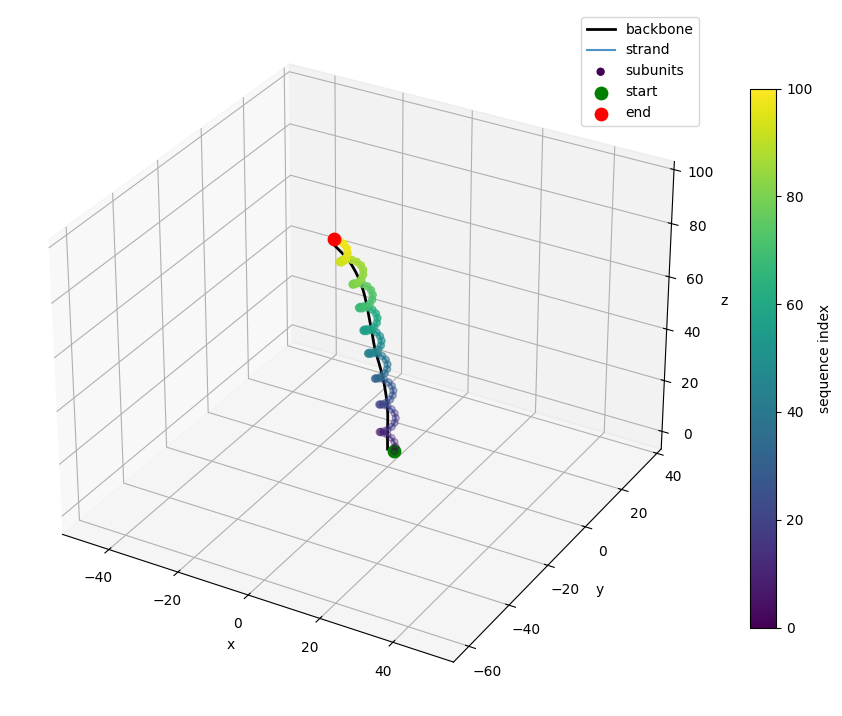

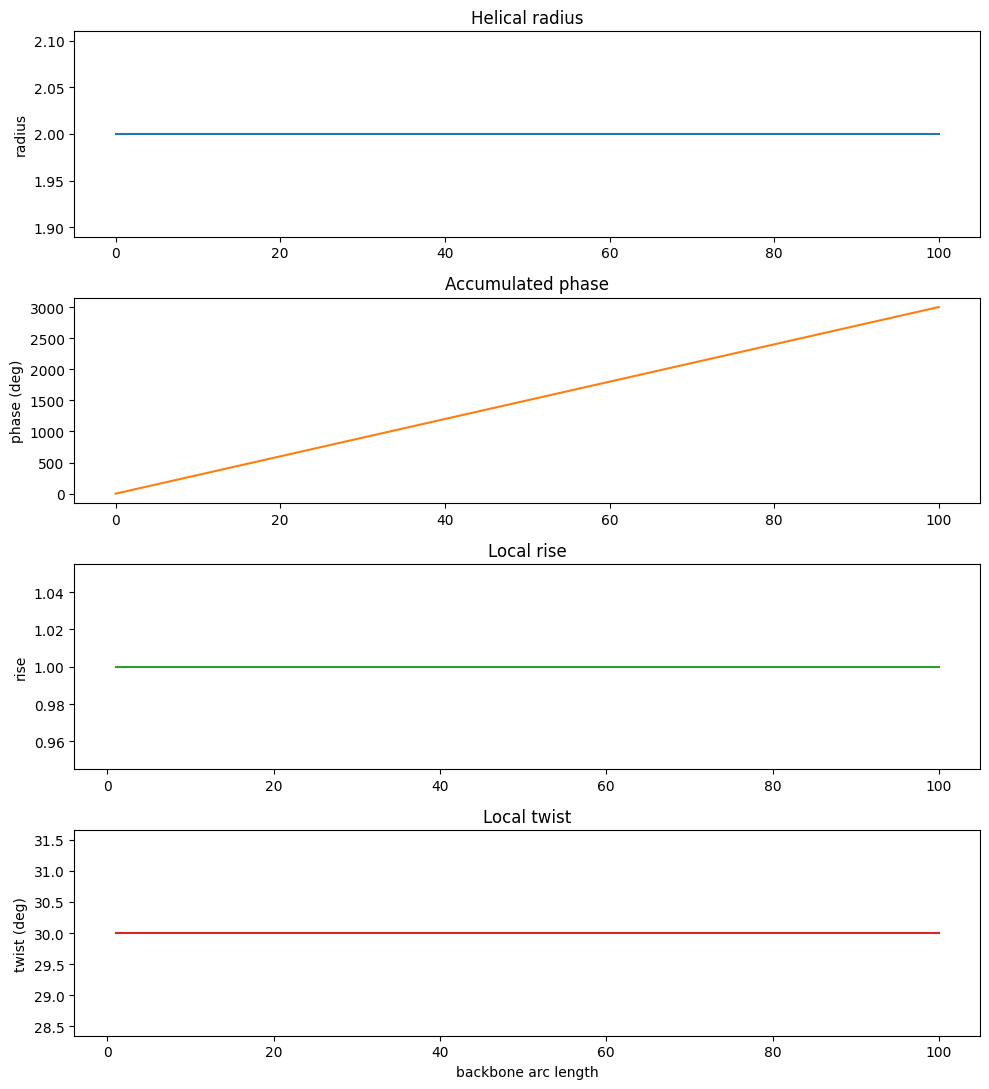

In [79]:
plot_single_strand_helix(helix)
plot_helix_diagnostics(helix)

### Straight backbone

In [80]:
straight_backbone_config = BackboneConfig(
    length=50.0,
    sampling_step=0.25,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.0,
    max_curvature=0.0,
    correlation_length=10.0,
    seed=42,
)

straight_backbone = generate_backbone(
    straight_backbone_config
)

straight_helix = generate_single_strand_helix(
    backbone=straight_backbone,
    config=helix_config,
)

straight_validation = validate_single_strand_helix(
    helix=straight_helix,
    config=helix_config,
)

straight_validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'sequence_starts_at_zero': True,
  'sequence_is_consecutive': True,
  'single_strand': True,
  'radius_is_correct': True,
  'stored_radius_is_correct': True,
  'phase_is_correct': True,
  'rise_is_correct': True,
  'twist_is_correct': True,
  'edges_are_correct': True,
  'edge_indices_are_valid': True},
 'metrics': {'n_nodes': 51,
  'n_directed_edges': 100,
  'max_radius_error': 2.220446049250313e-16,
  'mean_backbone_curvature': 0.0,
  'max_backbone_curvature': 0.0,
  'n_turns': 4.166666666666666}}

# Multiple strands

In [83]:
@dataclass(frozen=True)
class HelixConfig:
    rise: float = 1.0
    twist_rad: float = np.deg2rad(30.0)
    radius: float = 2.0

    n_strands: int = 1
    initial_phase_rad: float = 0.0
    strand_phase_offsets_rad: tuple[float, ...] | None = None

    first_strand_id: int = 0

In [84]:
@dataclass
class CleanHelixGeometry:
    positions: np.ndarray
    backbone_positions: np.ndarray

    tangents: np.ndarray
    normals: np.ndarray
    binormals: np.ndarray

    arc_length: np.ndarray
    sequence_index: np.ndarray
    backbone_index: np.ndarray
    strand_id: np.ndarray

    phase_rad: np.ndarray
    strand_phase_offset_rad: np.ndarray
    radius: np.ndarray
    backbone_curvature: np.ndarray

    undirected_edge_index: np.ndarray
    edge_strand_id: np.ndarray
    local_rise: np.ndarray
    local_twist_rad: np.ndarray

    global_rise: float
    global_twist_rad: float
    global_radius: float

    n_strands: int
    n_nodes_per_strand: int

### Config validation

In [85]:
def validate_helix_config(
    config: HelixConfig,
    backbone: BackboneGeometry,
) -> None:
    """
    Valida la configuración multistrand respecto al backbone.
    """
    scalar_values = {
        "rise": config.rise,
        "twist_rad": config.twist_rad,
        "radius": config.radius,
        "initial_phase_rad": config.initial_phase_rad,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.rise <= 0.0:
        raise ValueError("rise must be greater than zero")

    if config.radius <= 0.0:
        raise ValueError("radius must be greater than zero")

    if not isinstance(config.n_strands, (int, np.integer)):
        raise ValueError("n_strands must be an integer")

    if config.n_strands < 1:
        raise ValueError("n_strands must be at least one")

    if not isinstance(config.first_strand_id, (int, np.integer)):
        raise ValueError("first_strand_id must be an integer")

    if config.strand_phase_offsets_rad is not None:
        offsets = np.asarray(
            config.strand_phase_offsets_rad,
            dtype=np.float64,
        )

        if offsets.shape != (config.n_strands,):
            raise ValueError(
                "strand_phase_offsets_rad must contain exactly "
                f"{config.n_strands} values"
            )

        if not np.all(np.isfinite(offsets)):
            raise ValueError(
                "strand_phase_offsets_rad contains non-finite values"
            )

    backbone_length = float(backbone.arc_length[-1])

    if config.rise > backbone_length:
        raise ValueError(
            "rise is greater than the backbone length"
        )

    n_nodes_per_strand = (
        int(np.floor(backbone_length / config.rise)) + 1
    )

    if n_nodes_per_strand < 3:
        raise ValueError(
            "at least three nodes per strand are required"
        )

### Resolve strand phases

In [86]:
def resolve_strand_phase_offsets(
    config: HelixConfig,
) -> np.ndarray:
    """
    Returns the offset for each strand

    Returns
    -------
    np.ndarray
        float64 array with shape (n_strands,)
    """
    if config.strand_phase_offsets_rad is None:
        offsets = (
            2.0
            * np.pi
            * np.arange(config.n_strands, dtype=np.float64)
            / config.n_strands
        )
    else:
        offsets = np.asarray(
            config.strand_phase_offsets_rad,
            dtype=np.float64,
        ).copy()

    return np.mod(offsets, 2.0 *np.pi)


### Build undirected edges per strand

In [94]:
def build_undirected_strand_edges(
    n_strands: int,
    n_nodes_per_strand: int,
    first_strand_id: int = 0,
) -> [np.ndarray, np.ndarray]:
    """
    Connect consecutive nodes in each strand

    Returns
    -------
    unidrected_edge_index
        Shape (2, n_strands * (n_nodes_per_strand - 1))
        Each strand appears once and source < target
    edge_strand_id
        Shpae (E,)
    """
    if not isinstance(n_strands, (int, np.integer)):
        raise ValueError("n_strands must be an integer")

    if not isinstance(n_nodes_per_strand, (int, np.integer)):
        raise ValueError(
            "n_nodes_per_strand must be an integer"
        )

    if n_strands < 1:
        raise ValueError("n_strands must be at least one")

    if n_nodes_per_strand < 2:
        raise ValueError(
            "n_nodes_per_strand must be at least two"
        )

    local_source = np.arange(
        n_nodes_per_strand - 1,
        dtype=np.int64,
    )

    strand_node_offsets = (
        np.arange(n_strands, dtype=np.int64)
        * n_nodes_per_strand
    )

    source = (
        strand_node_offsets[:, None]
        + local_source[None, :]
    )

    target = source + 1

    undirected_edge_index = np.stack(
        [
            source.reshape(-1),
            target.reshape(-1,)
        ],
        axis=0,
    )

    strand_ids = (
        first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    edge_strand_id = np.repeat(
        strand_ids,
        n_nodes_per_strand - 1,
    )

    return undirected_edge_index, edge_strand_id

### Message passing conversion

In [88]:
def undirected_to_directed_edge_index(
    undirected_edge_index: np.ndarray,
) -> np.ndarray:
    """
    Transform each undirected edge u--v into u->v and v->u

    Oriniginal graph is still undirected conceptually
    """
    undirected_edge_index = np.asarray(
        undirected_edge_index,
        dtype=np.int64,
    )

    if (
        undirected_edge_index.ndim != 2
        or undirected_edge_index.shape[0] != 2
    ):
        raise ValueError(
            "undirected_edge_index must have shape (2, E)"
        )

    if np.any(
        undirected_edge_index[0]
        >= undirected_edge_index[1]
    ):
        raise ValueError(
            "canonical undirected edges must satisfy source < target"
        )

    reverse_edges = undirected_edge_index[[1, 0]]

    return np.concatenate(
        [undirected_edge_index, reverse_edges],
        axis=1,
    )

### Generate vectorized multistrand

In [100]:
def generate_clean_helix(
    backbone: BackboneGeometry,
    config: HelixConfig,
) -> CleanHelixGeometry:
    """
    Generate a clean helix with one or more strands

    Positions generation is vectorized over strands and axial positions
    """
    validate_helix_config(
        config=config,
        backbone=backbone,
    )

    helix_arc_length = build_helix_arc_length_grid(
        backbone_length=float(backbone.arc_length[-1]),
        rise=config.rise,
    )

    sampled_backbone = resample_backbone(
        backbone=backbone,
        target_arc_length=helix_arc_length,
    )

    n_strands = config.n_strands
    n_nodes_per_strand = len(helix_arc_length)

    sequence_index_1d = np.arange(
        n_nodes_per_strand,
        dtype=np.int64,
    )

    strand_ids = (
        config.first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    phase_offsets = resolve_strand_phase_offsets(config)

    base_phase = (
        config.initial_phase_rad
        + sequence_index_1d.astype(np.float64)
        * config.twist_rad
    )

    # Shape: (S, L)
    phase_matrix = (
        phase_offsets[:, None]
        + base_phase[None, :]
    )

    cos_phase = np.cos(phase_matrix)
    sin_phase = np.sin(phase_matrix)

    # Frames share strands
    # Resultant phase: (S, L, 3)
    radial_directions = (
        cos_phase[:, :, None]
        * sampled_backbone.normals[None, :, :]
        + sin_phase[:, :, None]
        * sampled_backbone.binormals[None, :, :]
    )

    positions_matrix = (
        sampled_backbone.positions[None, :, :]
        + config.radius * radial_directions
    )

    positions = positions_matrix.reshape(
        n_strands * n_nodes_per_strand,
        3,   
    )

    backbone_positions = np.broadcast_to(
        sampled_backbone.positions[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    tangents = np.broadcast_to(
        sampled_backbone.tangents[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    normals = np.broadcast_to(
        sampled_backbone.normals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    binormals = np.broadcast_to(
        sampled_backbone.binormals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    arc_length = np.tile(
        helix_arc_length,
        n_strands,
    )

    sequence_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    backbone_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    strand_id = np.repeat(
        strand_ids,
        n_nodes_per_strand,
    )

    phase_rad = phase_matrix.reshape(-1)

    strand_phase_offset_rad = np.repeat(
        phase_offsets,
        n_nodes_per_strand,
    )

    radius = np.full(
        n_strands * n_nodes_per_strand,
        config.radius,
        dtype=np.float64,
    )

    backbone_curvature = np.tile(
        sampled_backbone.curvature,
        n_strands,
    )

    (
        undirected_edge_index,
        edge_strand_id,
    ) = build_undirected_strand_edges(
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
        first_strand_id=config.first_strand_id,
    )

    n_edges = undirected_edge_index.shape[1]

    local_rise = np.full(
        n_edges,
        config.rise,
        dtype=np.float64,
    )

    local_twist_rad = np.full(
        n_edges,
        config.twist_rad,
        dtype=np.float64,
    )

    return CleanHelixGeometry(
        positions=positions,
        backbone_positions=backbone_positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        arc_length=arc_length,
        sequence_index=sequence_index,
        backbone_index=backbone_index,
        strand_id=strand_id,
        phase_rad=phase_rad,
        strand_phase_offset_rad=strand_phase_offset_rad,
        radius=radius,
        backbone_curvature=backbone_curvature,
        undirected_edge_index=undirected_edge_index,
        edge_strand_id=edge_strand_id,
        local_rise=local_rise,
        local_twist_rad=local_twist_rad,
        global_rise=float(config.rise),
        global_twist_rad=float(config.twist_rad),
        global_radius=float(config.radius),
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
    )






In [101]:
def validate_clean_helix(
    helix: CleanHelixGeometry,
    config: HelixConfig,
    atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Valida una hélice limpia de uno o varios strands.
    """
    n_strands = config.n_strands
    nodes_per_strand = helix.n_nodes_per_strand
    n_nodes = n_strands * nodes_per_strand
    n_edges = n_strands * (nodes_per_strand - 1)

    vector_fields = {
        "positions": helix.positions,
        "backbone_positions": helix.backbone_positions,
        "tangents": helix.tangents,
        "normals": helix.normals,
        "binormals": helix.binormals,
    }

    for name, values in vector_fields.items():
        if values.shape != (n_nodes, 3):
            raise ValueError(
                f"{name} must have shape ({n_nodes}, 3), "
                f"received {values.shape}"
            )

    node_fields = {
        "arc_length": helix.arc_length,
        "sequence_index": helix.sequence_index,
        "backbone_index": helix.backbone_index,
        "strand_id": helix.strand_id,
        "phase_rad": helix.phase_rad,
        "strand_phase_offset_rad": helix.strand_phase_offset_rad,
        "radius": helix.radius,
        "backbone_curvature": helix.backbone_curvature,
    }

    for name, values in node_fields.items():
        if values.shape != (n_nodes,):
            raise ValueError(
                f"{name} must have shape ({n_nodes},)"
            )

    if helix.undirected_edge_index.shape != (2, n_edges):
        raise ValueError(
            "undirected_edge_index has an invalid shape"
        )

    edge_fields = {
        "edge_strand_id": helix.edge_strand_id,
        "local_rise": helix.local_rise,
        "local_twist_rad": helix.local_twist_rad,
    }

    for name, values in edge_fields.items():
        if values.shape != (n_edges,):
            raise ValueError(
                f"{name} must have shape ({n_edges},)"
            )

    all_arrays = (
        list(vector_fields.values())
        + list(node_fields.values())
        + list(edge_fields.values())
    )

    all_finite = all(
        np.all(np.isfinite(values))
        for values in all_arrays
    )

    source = helix.undirected_edge_index[0]
    target = helix.undirected_edge_index[1]

    measured_radius = np.linalg.norm(
        helix.positions - helix.backbone_positions,
        axis=1,
    )

    expected_offsets = resolve_strand_phase_offsets(config)

    expected_strand_ids = (
        config.first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    correct_sequences = True
    correct_offsets = True

    for strand_position, strand_value in enumerate(
        expected_strand_ids
    ):
        mask = helix.strand_id == strand_value

        correct_sequences &= np.array_equal(
            helix.sequence_index[mask],
            np.arange(nodes_per_strand, dtype=np.int64),
        )

        correct_offsets &= np.allclose(
            helix.strand_phase_offset_rad[mask],
            expected_offsets[strand_position],
            atol=atol,
        )

    checks = {
        "all_finite": bool(all_finite),
        "correct_number_of_strands": bool(
            len(np.unique(helix.strand_id)) == n_strands
        ),
        "sequence_is_correct_per_strand": bool(
            correct_sequences
        ),
        "phase_offsets_are_correct": bool(correct_offsets),
        "radius_is_correct": bool(
            np.allclose(
                measured_radius,
                config.radius,
                atol=atol,
            )
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edge_indices_are_valid": bool(
            np.min(source) >= 0
            and np.max(target) < n_nodes
        ),
        "edges_remain_inside_strands": bool(
            np.all(
                helix.strand_id[source]
                == helix.strand_id[target]
            )
        ),
        "edges_join_consecutive_nodes": bool(
            np.all(
                helix.sequence_index[target]
                - helix.sequence_index[source]
                == 1
            )
        ),
        "local_rise_is_correct": bool(
            np.allclose(
                helix.local_rise,
                config.rise,
                atol=atol,
            )
        ),
        "local_twist_is_correct": bool(
            np.allclose(
                helix.local_twist_rad,
                config.twist_rad,
                atol=atol,
            )
        ),
    }

    unique_edges = np.unique(
        helix.undirected_edge_index.T,
        axis=0,
    )

    checks["edges_are_unique"] = bool(
        len(unique_edges) == n_edges
    )

    metrics = {
        "n_nodes": n_nodes,
        "n_undirected_edges": n_edges,
        "n_strands": n_strands,
        "n_nodes_per_strand": nodes_per_strand,
        "max_radius_error": float(
            np.max(
                np.abs(measured_radius - config.radius)
            )
        ),
        "mean_backbone_curvature": float(
            np.mean(helix.backbone_curvature)
        ),
        "max_backbone_curvature": float(
            np.max(helix.backbone_curvature)
        ),
        "turns_per_strand": float(
            abs(config.twist_rad)
            * (nodes_per_strand - 1)
            / (2.0 * np.pi)
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Multistrand helix visualization

In [102]:
def plot_clean_helix(
    helix: CleanHelixGeometry,
    show_backbone: bool = True,
    show_edges: bool = True,
):
    """
    Representa una hélice limpia coloreando cada strand.
    """
    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection="3d")

    color_map = plt.get_cmap("tab10")
    strand_values = np.unique(helix.strand_id)

    if show_backbone:
        backbone_mask = (
            helix.strand_id == strand_values[0]
        )

        backbone_positions = helix.backbone_positions[
            backbone_mask
        ]

        ax.plot(
            backbone_positions[:, 0],
            backbone_positions[:, 1],
            backbone_positions[:, 2],
            color="black",
            linewidth=2.0,
            label="backbone",
        )

    for strand_position, strand_value in enumerate(
        strand_values
    ):
        mask = helix.strand_id == strand_value
        positions = helix.positions[mask]
        color = color_map(strand_position % 10)

        if show_edges:
            ax.plot(
                positions[:, 0],
                positions[:, 1],
                positions[:, 2],
                color=color,
                linewidth=1.5,
                alpha=0.8,
            )

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color=color,
            s=24,
            label=f"strand {strand_value}",
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

### Execution

In [103]:
helix_config = HelixConfig(
    rise=1.0,
    twist_rad=np.deg2rad(30.0),
    radius=2.0,
    n_strands=3,
    initial_phase_rad=0.0,
    strand_phase_offsets_rad=None,
    first_strand_id=0,
)

clean_helix = generate_clean_helix(
    backbone=backbone,
    config=helix_config,
)

validation = validate_clean_helix(
    helix=clean_helix,
    config=helix_config,
)

validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'correct_number_of_strands': True,
  'sequence_is_correct_per_strand': True,
  'phase_offsets_are_correct': True,
  'radius_is_correct': True,
  'edges_are_canonical': True,
  'edge_indices_are_valid': True,
  'edges_remain_inside_strands': True,
  'edges_join_consecutive_nodes': True,
  'local_rise_is_correct': True,
  'local_twist_is_correct': True,
  'edges_are_unique': True},
 'metrics': {'n_nodes': 303,
  'n_undirected_edges': 300,
  'n_strands': 3,
  'n_nodes_per_strand': 101,
  'max_radius_error': 3.774758283725532e-15,
  'mean_backbone_curvature': 0.009238176455392344,
  'max_backbone_curvature': 0.021423357745849428,
  'turns_per_strand': 8.333333333333332}}

(<Figure size 1000x900 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

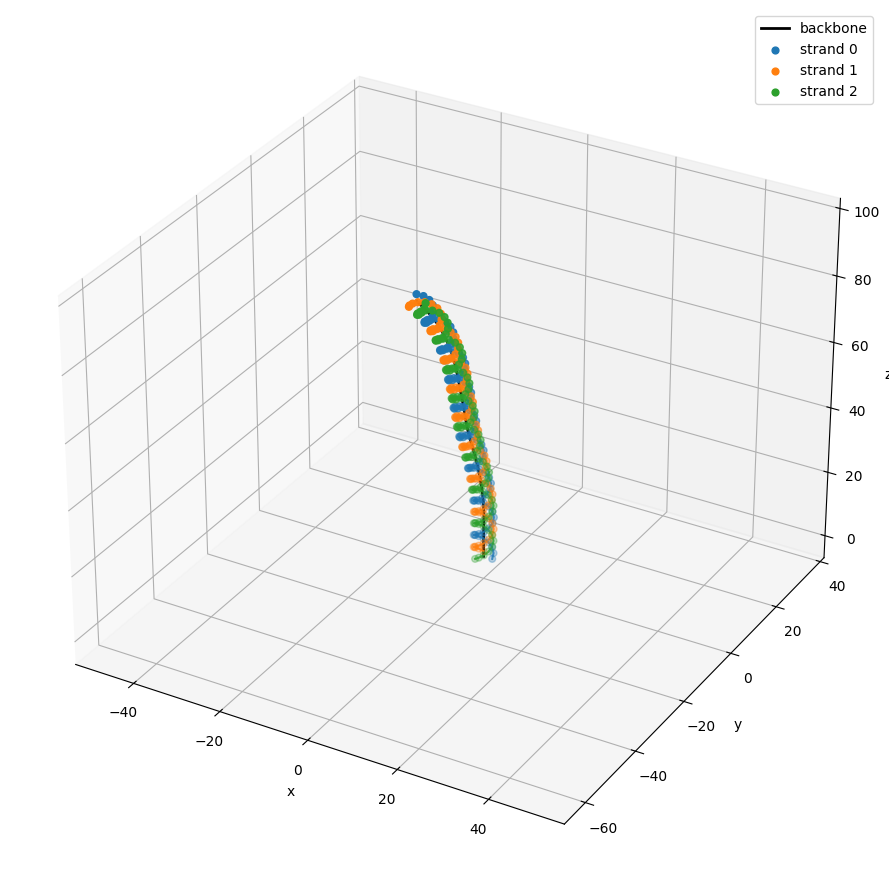

In [104]:
plot_clean_helix(clean_helix)

In [105]:
directed_edge_index = undirected_to_directed_edge_index(
    clean_helix.undirected_edge_index
)

print(clean_helix.undirected_edge_index.shape)
print(directed_edge_index.shape)

(2, 300)
(2, 600)


In [106]:
for n_strands in [1, 2, 3, 4]:
    test_config = HelixConfig(
        rise=1.0,
        twist_rad=np.deg2rad(30.0),
        radius=2.0,
        n_strands=n_strands,
    )

    test_helix = generate_clean_helix(
        backbone=backbone,
        config=test_config,
    )

    test_validation = validate_clean_helix(
        helix=test_helix,
        config=test_config,
    )

    print(
        n_strands,
        test_validation["is_valid"],
        test_validation["metrics"],
    )

1 True {'n_nodes': 101, 'n_undirected_edges': 100, 'n_strands': 1, 'n_nodes_per_strand': 101, 'max_radius_error': 3.774758283725532e-15, 'mean_backbone_curvature': 0.009238176455392343, 'max_backbone_curvature': 0.021423357745849428, 'turns_per_strand': 8.333333333333332}
2 True {'n_nodes': 202, 'n_undirected_edges': 200, 'n_strands': 2, 'n_nodes_per_strand': 101, 'max_radius_error': 3.774758283725532e-15, 'mean_backbone_curvature': 0.009238176455392343, 'max_backbone_curvature': 0.021423357745849428, 'turns_per_strand': 8.333333333333332}
3 True {'n_nodes': 303, 'n_undirected_edges': 300, 'n_strands': 3, 'n_nodes_per_strand': 101, 'max_radius_error': 3.774758283725532e-15, 'mean_backbone_curvature': 0.009238176455392344, 'max_backbone_curvature': 0.021423357745849428, 'turns_per_strand': 8.333333333333332}
4 True {'n_nodes': 404, 'n_undirected_edges': 400, 'n_strands': 4, 'n_nodes_per_strand': 101, 'max_radius_error': 4.440892098500626e-15, 'mean_backbone_curvature': 0.009238176455392

# Rise, twist and radio variation

In [107]:
@dataclass(frozen=True)
class ScalarProfileConfig:
    enabled: bool = False # Returns a constant profile or not
    std: float = 0.0 # Intensity of variation
    correlation_length: float = 10.0 # Physical distance that persists over the variation

    min_value: float | None = None 
    max_value: float | None = None

    anchor_start: bool = True # First value equal to nominal value

## Helix configuration

In [110]:
@dataclass(frozen=True)
class HelixConfig:
    rise: float = 1.0
    twist_rad: float = np.deg2rad(30.0)
    radius: float = 2.0

    n_strands: int = 1
    initial_phase_rad: float= 0.0
    strand_phase_offsets_rad: tuple[float, ...] | None = None
    first_strand_id: int = 0

    rise_variation: ScalarProfileConfig = field(
        default_factory=ScalarProfileConfig
    )
    twist_variation: ScalarProfileConfig = field(
        default_factory=ScalarProfileConfig
    )
    radius_variation: ScalarProfileConfig = field(
        default_factory=ScalarProfileConfig
    )

    seed: int = 42

## Helix geometry 

In [112]:
@dataclass
class CleanHelixGeometry:
    positions: np.ndarray
    backbone_positions: np.ndarray

    tangents: np.ndarray
    normals: np.ndarray
    binormals: np.ndarray

    arc_length: np.ndarray
    sequence_index: np.ndarray
    backbone_index: np.ndarray
    strand_id: np.ndarray

    phase_rad: np.ndarray
    strand_phase_offset_rad: np.ndarray
    radius: np.ndarray
    backbone_curvature: np.ndarray

    undirected_edge_index: np.ndarray
    edge_strand_id: np.ndarray
    local_rise: np.ndarray
    local_twist_rad: np.ndarray

    shared_arc_length: np.ndarray
    shared_radius_profile: np.ndarray
    shared_local_rise: np.ndarray
    shared_local_twist_rad: np.ndarray
    shared_phase_rad: np.ndarray

    nominal_rise: float
    nominal_twist_rad: float
    nominal_radius: float

    global_rise: float
    global_twist_rad: float
    global_radius: float

    n_strands: int
    n_nodes_per_strand: int

In [113]:
def validate_scalar_profile_config(
    config: ScalarProfileConfig,
    nominal_value: float,
    profile_name: str,
    require_positive: bool,
) -> None:
    """
    Valida la configuración de un perfil escalar.

    Parameters
    ----------
    config
        Configuración del perfil.
    nominal_value
        Valor alrededor del que fluctúa el perfil.
    profile_name
        Nombre usado en mensajes de error.
    require_positive
        Si True, todos los valores deben ser mayores que cero.
    """
    if not isinstance(config.enabled, (bool, np.bool_)):
        raise ValueError(
            f"{profile_name}.enabled must be boolean"
        )

    scalar_values = {
        "std": config.std,
        "correlation_length": config.correlation_length,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(
                f"{profile_name}.{name} must be finite"
            )

    if config.std < 0.0:
        raise ValueError(
            f"{profile_name}.std cannot be negative"
        )

    if config.correlation_length <= 0.0:
        raise ValueError(
            f"{profile_name}.correlation_length must be positive"
        )

    if config.min_value is not None:
        if not np.isfinite(config.min_value):
            raise ValueError(
                f"{profile_name}.min_value must be finite"
            )

    if config.max_value is not None:
        if not np.isfinite(config.max_value):
            raise ValueError(
                f"{profile_name}.max_value must be finite"
            )

    if (
        config.min_value is not None
        and config.max_value is not None
        and config.min_value > config.max_value
    ):
        raise ValueError(
            f"{profile_name}.min_value cannot be greater "
            "than max_value"
        )

    if (
        config.min_value is not None
        and nominal_value < config.min_value
    ):
        raise ValueError(
            f"nominal {profile_name} is below min_value"
        )

    if (
        config.max_value is not None
        and nominal_value > config.max_value
    ):
        raise ValueError(
            f"nominal {profile_name} is above max_value"
        )

    if require_positive:
        if nominal_value <= 0.0:
            raise ValueError(
                f"nominal {profile_name} must be positive"
            )

        if (
            config.min_value is not None
            and config.min_value <= 0.0
        ):
            raise ValueError(
                f"{profile_name}.min_value must be positive"
            )

    if config.enabled and config.std == 0.0:
        raise ValueError(
            f"{profile_name} variation is enabled but std is zero"
        )

In [114]:
def validate_helix_config(
    config: HelixConfig,
    backbone: BackboneGeometry,
) -> None:
    """
    Valida la configuración helicoidal y sus perfiles.
    """
    scalar_values = {
        "rise": config.rise,
        "twist_rad": config.twist_rad,
        "radius": config.radius,
        "initial_phase_rad": config.initial_phase_rad,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.rise <= 0.0:
        raise ValueError("rise must be positive")

    if config.radius <= 0.0:
        raise ValueError("radius must be positive")

    if not isinstance(config.n_strands, (int, np.integer)):
        raise ValueError("n_strands must be an integer")

    if config.n_strands < 1:
        raise ValueError("n_strands must be at least one")

    if not isinstance(config.first_strand_id, (int, np.integer)):
        raise ValueError(
            "first_strand_id must be an integer"
        )

    if not isinstance(config.seed, (int, np.integer)):
        raise ValueError("seed must be an integer")

    if config.strand_phase_offsets_rad is not None:
        offsets = np.asarray(
            config.strand_phase_offsets_rad,
            dtype=np.float64,
        )

        if offsets.shape != (config.n_strands,):
            raise ValueError(
                "strand_phase_offsets_rad must contain "
                f"{config.n_strands} values"
            )

        if not np.all(np.isfinite(offsets)):
            raise ValueError(
                "strand_phase_offsets_rad contains "
                "non-finite values"
            )

    validate_scalar_profile_config(
        config=config.rise_variation,
        nominal_value=config.rise,
        profile_name="rise",
        require_positive=True,
    )

    validate_scalar_profile_config(
        config=config.twist_variation,
        nominal_value=config.twist_rad,
        profile_name="twist",
        require_positive=False,
    )

    validate_scalar_profile_config(
        config=config.radius_variation,
        nominal_value=config.radius,
        profile_name="radius",
        require_positive=True,
    )

    backbone_length = float(backbone.arc_length[-1])

    minimum_rise = (
        config.rise_variation.min_value
        if config.rise_variation.enabled
        and config.rise_variation.min_value is not None
        else config.rise
    )

    if minimum_rise > backbone_length:
        raise ValueError(
            "rise is too large for the backbone"
        )

    if backbone_length / minimum_rise < 2.0:
        raise ValueError(
            "the backbone cannot contain three helix nodes"
        )

## Application of limits

In [115]:
def clip_profile_values(
    values: np.ndarray,
    config: ScalarProfileConfig,
) -> np.ndarray:
    """
    Apply the limits configurated in the profile
    """
    values = np.asarray(values, dtype=np.float64).copy()

    lower = (
        config.min_value
        if config.min_value is not None
        else -np.inf
    )

    upper = (
        config.max_value
        if config.max_value is not None
        else np.inf
    )

    return np.clip(values, lower, upper)

## Generate correlated profile

In [159]:
def generate_correlated_scalar_profile(
    coordinate: np.ndarray,
    nominal_value: float,
    config: ScalarProfileConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a smooth scalar profile over the rising coordinates

    Use an Ornstein-Uhlenbeck discretized process, so the correlation is expressed in physical units of 'coordinate'

    Parameters 
    ----------
    coordinate
        Shape (N,)rising estrictly
    nominal_value
        Nominal mean of the profile
    config
        Variation configuration
    rng
        Random generator

    Returns
    -------
    np.ndarray
        float64 array with shape (N,)
    """
    coordinate = np.asarray(coordinate, dtype=np.float64)

    if coordinate.ndim != 1:
        raise ValueError(
            "coordinate must be one-dimensional"
        )

    if len(coordinate) < 1:
        raise ValueError(
            "coordinate must contain at least one value"
        )

    if not np.all(np.isfinite(coordinate)):
        raise ValueError(
            "coordinate contains non-finite values"
        )

    if len(coordinate) > 1:
        if np.any(np.diff(coordinate) <= 0.0):
            raise ValueError(
                "coordinate must be strictly increasing"
            )
    
    if not config.enabled:
        return np.full(
            len(coordinate),
            nominal_value,
            dtype=np.float64,
        )

    profile = np.empty(
        len(coordinate),
        dtype=np.float64,
    )

    if config.anchor_start:
        profile[0] = nominal_value
    else:
        profile[0] = rng.normal(
            loc=nominal_value,
            scale=config.std,
        )

    profile[0] = clip_profile_values(
        np.array([profile[0]], dtype=np.float64),
        config,
    )[0]

    for index in range(1, len(coordinate)):
        step = coordinate[index] - coordinate[index - 1]

        alpha = np.exp(
            -step / config.correlation_length
        )
        innovation_scale = (
            config.std * np.sqrt(1.0 - alpha**2)
        )

        deviation_previous = (
            profile[index - 1] - nominal_value
        )

        profile[index] = (
            nominal_value
            + alpha * deviation_previous
            + rng.normal(
                loc=0.0,
                scale=innovation_scale,
            )
        )

        profile[index] = clip_profile_values(
            np.array([profile[index]], dtype=np.float64),
            config,
        )[0]

    return profile

## Variable rise generation

In [154]:
def generate_variable_rise_grid(
    backbone_length: float,
    nominal_rise: float,
    config: ScalarProfileConfig,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate axial positions and local rises

    Returns
    -------
    arc_length
        Shape (N,), axial position of each node
    local_rise
        Shape (N-1,), separation between consecutive nodes
    """
    if backbone_length <= 0.0:
        raise ValueError(
            "backbone_length must be positive"
        )

    if nominal_rise <= 0.0:
        raise ValueError(
            "nominal_rise must be positive"
        )

    if not config.enabled:
        arc_length = build_helix_arc_length_grid(
            backbone_length=backbone_length,
            rise=nominal_rise,
        )

        return arc_length, np.diff(arc_length)

    minimum_rise = (
        config.min_value
        if config.min_value is not None
        else max(
            nominal_rise - 5.0 * config.stf,
            0.05 * nominal_rise,
        )
    )

    if minimum_rise <= 0.0:
        raise ValueError(
            "rise_variation requires a positive effective minimum"
        )

    maximum_iterations = (
        int(np.ceil(backbone_length / minimum_rise)) + 2
    )

    arc_values = [0.0]
    rise_values = []

    if config.anchor_start:
        current_rise = nominal_rise
    else:
        current_rise = rng.normal(
            loc=nominal_rise,
            scale=config.std,
        )

    current_rise = clip_profile_values(
        np.array([current_rise], dtype=np.float64),
        config,
    )[0]

    if current_rise <= 0.0:
        raise ValueError(
            "generated rise must be positive"
        )

    for _ in range(maximum_iterations):
        current_position = arc_values[-1]
        next_position = current_position + current_rise

        if next_position > backbone_length:
            break

        rise_values.append(current_rise)
        arc_values.append(next_position)

        alpha = np.exp(
            -current_rise / config.correlation_length
        )
        innovation_scale = (
            config.std * np.sqrt(1.0 - alpha**2)
        )

        current_deviation = (
            current_rise - nominal_rise
        )

        next_rise = (
            nominal_rise
            + alpha * current_deviation
            + rng.normal(
                loc=0.0,
                scale=innovation_scale,
            )
        )

        current_rise = clip_profile_values(
            np.array([next_rise], dtype=np.float64),
            config,
        )[0]

        if current_rise <= 0.0:
            raise ValueError(
                "generated rise must remain positive"
            )

    arc_length = np.asarray(
        arc_values,
        dtype=np.float64,
    )
    local_rise = np.asarray(
        rise_values,
        dtype=np.float64,
    )

    if len(arc_length) < 3:
        raise ValueError(
        "rise profile generated fewer than three nodes"
    )

    if local_rise.shape != (len(arc_length) - 1,):
        raise RuntimeError(
            "inconsistent rise grid generation"
        )

    return arc_length, local_rise

## Twist profile generation

In [118]:
def generate_local_twist_profile(
    arc_length: np.ndarray,
    nominal_twist_rad: float,
    config: ScalarProfileConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a twist for each segment

    Returns
    -------
    np.ndarray
        Shape (N-1,), twist between each pair of consecutive nodes
    """
    arc_length = np.asanyarray(
        arc_length,
        dtype=np.float64,
    )

    if arc_length.ndim != 1 or len(arc_length) < 2:
        raise ValueError(
            "arc_length must contain at least two points"
        )

    # Each i segment twist is associated with its initial point
    segment_coordinate = arc_length[:-1]

    return generate_correlated_scalar_profile(
        coordinate=segment_coordinate,
        nominal_value=nominal_twist_rad,
        config=config,
        rng=rng,
    )

## Transform local twist into phase

In [119]:
def integrate_twist_to_phase(
        local_twist_rad: np.ndarray,
        initial_phase_rad: float,
) -> np.ndarray:
    """
    Twists integration between segments for obtaining a phase per node

    Parameters
    ----------
    local_twist_rad
        Shape (N-1,)
    initial_phase_rad
        Phase of the first node

    Returns
    -------
    np.ndarray
        Accumulated phase with shape (N,)
    """
    local_twist_rad = np.asarray(
        local_twist_rad,
        dtype=np.float64,
    )

    if local_twist_rad.ndim != 1:
        raise ValueError(
            "local_twist_rad must be one-dimensional"
        )

    if not np.all(np.isfinite(local_twist_rad)):
        raise ValueError(
            "local_twist_rad contains non-finite values"
        )

    phase = np.empty(
        len(local_twist_rad) + 1,
        dtype=np.float64,
    )

    phase[0] = initial_phase_rad
    phase[1:] = (
        initial_phase_rad
        + np.cumsum(local_twist_rad)
    )

    return phase

## Local radius generation

In [120]:
def generate_local_radius_profile(
        arc_length: np.ndarray,
        nominal_radius: float,
        config: ScalarProfileConfig,
        rng:np.random.Generator,
) -> np.ndarray:
    """
    Generate a radius per node

    Returns
    -------
    np.ndarray
        Radius profile with shape (N,)
    """
    radius_profile = generate_correlated_scalar_profile(
        coordinate=arc_length,
        nominal_value=nominal_radius,
        config=config,
        rng=rng,
    )

    if np.any(radius_profile <= 0.0):
        raise ValueError(
            "radius profile must remain positive"
        )

    return radius_profile

## Generate independant random profiles

In [121]:
def create_helix_profile_generators(
        seed: int,
) -> tuple[
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
]:
    """
    Create independent generators for rise, twist and radius
    """
    seed_sequence = np.random.SeedSequence(seed)
    rise_seed, twist_seed, radius_seed = (
        seed_sequence.spawn(3)
    )

    return (
        np.random.default_rng(rise_seed),
        np.random.default_rng(twist_seed),
        np.random.default_rng(radius_seed),
    )

## Expansion of the profile over the strand

In [123]:
def expand_node_profile_by_strand(
        profile: np.ndarray,
        n_strands: int,
) -> np.ndarray:
    """
    Repeat the profile per node for all the strands

    Input shape (L,), output shape (S*L,)
    """
    profile = np.asarray(profile)

    if profile.ndim != 1:
        raise ValueError(
            "profile must be one-dimensional"
        )

    if n_strands < 1:
        raise ValueError(
            "n_strands must be at least one"
        )

    return np.tile(profile, n_strands)

def expand_edge_profile_by_strand(
        profile: np.ndarray,
        n_strands: int,
) -> np.ndarray:
    """
    Repeat the profile per segment for each of the strands

    Input shape (L-1,), output shape(S*(L-1),)
    """
    profile = np.asarray(profile)

    if profile.ndim != 1:
        raise ValueError(
            "profile must be one-dimensional"
        )

    if n_strands < 1:
        raise ValueError(
            "n_strands must be at least one"
        )

    return np.tile(profile, n_strands)

## Helix generation

In [149]:
def generate_clean_helix(
        backbone: BackboneGeometry,
        config: HelixConfig,
) -> CleanHelixGeometry:
    """
    Generate a multistrand helix with constant or smootly variable rise, twist and radius 
    """
    validate_helix_config(
        config=config,
        backbone=backbone,
    )

    (
        rise_rng,
        twist_rng,
        radius_rng,
    ) = create_helix_profile_generators(config.seed)

    backbone_length = float(
        backbone.arc_length[-1]
    )

    (
        shared_arc_length,
        shared_local_rise,
    ) = generate_variable_rise_grid(
        backbone_length=backbone_length,
        nominal_rise=config.rise,
        config=config.rise_variation,
        rng=rise_rng,
    )

    sampled_backbone = resample_backbone(
        backbone=backbone,
        target_arc_length=shared_arc_length,
    )

    shared_local_twist_rad = (
        generate_local_twist_profile(
            arc_length=shared_arc_length,
            nominal_twist_rad=config.twist_rad,
            config=config.twist_variation,
            rng=twist_rng,
        )
    )

    shared_phase_rad = integrate_twist_to_phase(
        local_twist_rad=shared_local_twist_rad,
        initial_phase_rad=config.initial_phase_rad,
    )

    shared_radius_profile = (
        generate_local_radius_profile(
            arc_length=shared_arc_length,
            nominal_radius=config.radius,
            config=config.radius_variation,
            rng=radius_rng,
        )
    )

    n_strands = config.n_strands
    n_nodes_per_strand = len(shared_arc_length)

    sequence_index_1d = np.arange(
        n_nodes_per_strand,
        dtype=np.int64,
    )

    strand_ids= (
        config.first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    phase_offsets = resolve_strand_phase_offsets(
        config
    )

    phase_matrix = (
        phase_offsets[:, None]
        + shared_phase_rad[None, :]
    )

    radial_directions = (
        np.cos(phase_matrix)[:, :, None]
        * sampled_backbone.normals[None, :, :,]
        + np.sin(phase_matrix)[:, :, None]
        * sampled_backbone.binormals[None, :, :]
    )

    positions_matrix = (
        sampled_backbone.positions[None, : , :]
        + shared_radius_profile[None, :, None]
        * radial_directions
    )

    positions = positions_matrix.reshape(-1, 3)

    backbone_positions = np.broadcast_to(
        sampled_backbone.positions[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    tangents = np.broadcast_to(
        sampled_backbone.tangents[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    normals = np.broadcast_to(
        sampled_backbone.normals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    binormals = np.broadcast_to(
        sampled_backbone.binormals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    arc_length = expand_node_profile_by_strand(
        shared_arc_length,
        n_strands,
    )

    sequence_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    backbone_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    strand_id = np.repeat(
        strand_ids,
        n_nodes_per_strand,
    )

    phase_rad = phase_matrix.reshape(-1)

    strand_phase_offset_rad = np.repeat(
        phase_offsets,
        n_nodes_per_strand,
    )

    radius = expand_node_profile_by_strand(
        shared_radius_profile,
        n_strands,
    )

    backbone_curvature = (
        expand_node_profile_by_strand(
            sampled_backbone.curvature,
            n_strands,
        )
    )

    (
        undirected_edge_index,
        edge_strand_id,
    ) = build_undirected_strand_edges(
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
        first_strand_id=config.first_strand_id,
    )

    local_rise = expand_edge_profile_by_strand(
        shared_local_rise,
        n_strands,
    )

    local_twist_rad = (
        expand_edge_profile_by_strand(
            shared_local_twist_rad,
            n_strands,
        )
    )

    return CleanHelixGeometry(
        positions=positions,
        backbone_positions=backbone_positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        arc_length=arc_length,
        sequence_index=sequence_index,
        backbone_index=backbone_index,
        strand_id=strand_id,
        phase_rad=phase_rad,
        strand_phase_offset_rad=strand_phase_offset_rad,
        radius=radius,
        backbone_curvature=backbone_curvature,
        undirected_edge_index=undirected_edge_index,
        edge_strand_id=edge_strand_id,
        local_rise=local_rise,
        local_twist_rad=local_twist_rad,
        shared_arc_length=shared_arc_length,
        shared_radius_profile=shared_radius_profile,
        shared_local_rise=shared_local_rise,
        shared_local_twist_rad=shared_local_twist_rad,
        shared_phase_rad=shared_phase_rad,
        nominal_rise=float(config.rise),
        nominal_twist_rad=float(config.twist_rad),
        nominal_radius=float(config.radius),
        global_rise=float(
            np.mean(shared_local_rise)
        ),
        global_twist_rad=float(
            np.mean(shared_local_twist_rad)
        ),
        global_radius=float(
            np.mean(shared_radius_profile)
        ),
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
    )


In [128]:
def validate_clean_helix(
    helix: CleanHelixGeometry,
    config: HelixConfig,
    atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Valida geometría, perfiles, fases y aristas.
    """
    n_strands = helix.n_strands
    nodes_per_strand = helix.n_nodes_per_strand

    n_nodes = n_strands * nodes_per_strand
    edges_per_strand = nodes_per_strand - 1
    n_edges = n_strands * edges_per_strand

    vector_fields = {
        "positions": helix.positions,
        "backbone_positions": helix.backbone_positions,
        "tangents": helix.tangents,
        "normals": helix.normals,
        "binormals": helix.binormals,
    }

    for name, array in vector_fields.items():
        if array.shape != (n_nodes, 3):
            raise ValueError(
                f"{name} must have shape ({n_nodes}, 3)"
            )

    node_fields = {
        "arc_length": helix.arc_length,
        "sequence_index": helix.sequence_index,
        "backbone_index": helix.backbone_index,
        "strand_id": helix.strand_id,
        "phase_rad": helix.phase_rad,
        "strand_phase_offset_rad": (
            helix.strand_phase_offset_rad
        ),
        "radius": helix.radius,
        "backbone_curvature": helix.backbone_curvature,
    }

    for name, array in node_fields.items():
        if array.shape != (n_nodes,):
            raise ValueError(
                f"{name} must have shape ({n_nodes},)"
            )

    edge_fields = {
        "edge_strand_id": helix.edge_strand_id,
        "local_rise": helix.local_rise,
        "local_twist_rad": helix.local_twist_rad,
    }

    for name, array in edge_fields.items():
        if array.shape != (n_edges,):
            raise ValueError(
                f"{name} must have shape ({n_edges},)"
            )

    if helix.undirected_edge_index.shape != (2, n_edges):
        raise ValueError(
            "undirected_edge_index has an invalid shape"
        )

    if helix.shared_arc_length.shape != (nodes_per_strand,):
        raise ValueError(
            "shared_arc_length has an invalid shape"
        )

    if helix.shared_radius_profile.shape != (
        nodes_per_strand,
    ):
        raise ValueError(
            "shared_radius_profile has an invalid shape"
        )

    if helix.shared_phase_rad.shape != (
        nodes_per_strand,
    ):
        raise ValueError(
            "shared_phase_rad has an invalid shape"
        )

    if helix.shared_local_rise.shape != (
        edges_per_strand,
    ):
        raise ValueError(
            "shared_local_rise has an invalid shape"
        )

    if helix.shared_local_twist_rad.shape != (
        edges_per_strand,
    ):
        raise ValueError(
            "shared_local_twist_rad has an invalid shape"
        )

    source = helix.undirected_edge_index[0]
    target = helix.undirected_edge_index[1]

    measured_radius = np.linalg.norm(
        helix.positions - helix.backbone_positions,
        axis=1,
    )

    phase_difference = (
        helix.phase_rad[target]
        - helix.phase_rad[source]
    )

    arc_difference = (
        helix.arc_length[target]
        - helix.arc_length[source]
    )

    expected_phase_from_twist = (
        integrate_twist_to_phase(
            helix.shared_local_twist_rad,
            config.initial_phase_rad,
        )
    )

    all_arrays = (
        list(vector_fields.values())
        + list(node_fields.values())
        + list(edge_fields.values())
        + [
            helix.shared_arc_length,
            helix.shared_radius_profile,
            helix.shared_local_rise,
            helix.shared_local_twist_rad,
            helix.shared_phase_rad,
        ]
    )

    checks = {
        "all_finite": bool(
            all(
                np.all(np.isfinite(array))
                for array in all_arrays
            )
        ),
        "number_of_strands_is_correct": bool(
            n_strands == config.n_strands
        ),
        "radius_matches_geometry": bool(
            np.allclose(
                measured_radius,
                helix.radius,
                atol=atol,
            )
        ),
        "radius_is_positive": bool(
            np.all(helix.radius > 0.0)
        ),
        "rise_is_positive": bool(
            np.all(helix.local_rise > 0.0)
        ),
        "arc_length_is_consistent": bool(
            np.allclose(
                arc_difference,
                helix.local_rise,
                atol=atol,
            )
        ),
        "phase_is_consistent": bool(
            np.allclose(
                phase_difference,
                helix.local_twist_rad,
                atol=atol,
            )
        ),
        "shared_phase_is_consistent": bool(
            np.allclose(
                helix.shared_phase_rad,
                expected_phase_from_twist,
                atol=atol,
            )
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edges_are_inside_strands": bool(
            np.all(
                helix.strand_id[source]
                == helix.strand_id[target]
            )
        ),
        "edges_join_consecutive_nodes": bool(
            np.all(
                helix.sequence_index[target]
                - helix.sequence_index[source]
                == 1
            )
        ),
        "global_rise_is_correct": bool(
            np.isclose(
                helix.global_rise,
                np.mean(helix.shared_local_rise),
                atol=atol,
            )
        ),
        "global_twist_is_correct": bool(
            np.isclose(
                helix.global_twist_rad,
                np.mean(
                    helix.shared_local_twist_rad
                ),
                atol=atol,
            )
        ),
        "global_radius_is_correct": bool(
            np.isclose(
                helix.global_radius,
                np.mean(
                    helix.shared_radius_profile
                ),
                atol=atol,
            )
        ),
    }

    unique_edges = np.unique(
        helix.undirected_edge_index.T,
        axis=0,
    )

    checks["edges_are_unique"] = bool(
        len(unique_edges) == n_edges
    )

    metrics = {
        "n_nodes": n_nodes,
        "n_undirected_edges": n_edges,
        "n_strands": n_strands,
        "n_nodes_per_strand": nodes_per_strand,
        "rise_min": float(
            np.min(helix.shared_local_rise)
        ),
        "rise_mean": float(
            np.mean(helix.shared_local_rise)
        ),
        "rise_max": float(
            np.max(helix.shared_local_rise)
        ),
        "twist_min_deg": float(
            np.rad2deg(
                np.min(
                    helix.shared_local_twist_rad
                )
            )
        ),
        "twist_mean_deg": float(
            np.rad2deg(
                np.mean(
                    helix.shared_local_twist_rad
                )
            )
        ),
        "twist_max_deg": float(
            np.rad2deg(
                np.max(
                    helix.shared_local_twist_rad
                )
            )
        ),
        "radius_min": float(
            np.min(helix.shared_radius_profile)
        ),
        "radius_mean": float(
            np.mean(helix.shared_radius_profile)
        ),
        "radius_max": float(
            np.max(helix.shared_radius_profile)
        ),
        "max_radius_geometry_error": float(
            np.max(
                np.abs(
                    measured_radius - helix.radius
                )
            )
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

## Visualization

In [129]:
def plot_helix_profiles(
    helix: CleanHelixGeometry,
):
    """
    Muestra los perfiles compartidos de rise, twist, radio y fase.
    """
    fig, axes = plt.subplots(
        4,
        1,
        figsize=(11, 12),
        sharex=False,
    )

    axes[0].plot(
        helix.shared_arc_length,
        helix.shared_radius_profile,
        color="tab:blue",
    )
    axes[0].axhline(
        helix.nominal_radius,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="nominal",
    )
    axes[0].set_ylabel("radius")
    axes[0].legend()

    axes[1].plot(
        helix.shared_arc_length[:-1],
        helix.shared_local_rise,
        color="tab:green",
    )
    axes[1].axhline(
        helix.nominal_rise,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="nominal",
    )
    axes[1].set_ylabel("rise")
    axes[1].legend()

    axes[2].plot(
        helix.shared_arc_length[:-1],
        np.rad2deg(
            helix.shared_local_twist_rad
        ),
        color="tab:red",
    )
    axes[2].axhline(
        np.rad2deg(helix.nominal_twist_rad),
        color="black",
        linestyle="--",
        alpha=0.6,
        label="nominal",
    )
    axes[2].set_ylabel("twist (deg)")
    axes[2].legend()

    axes[3].plot(
        helix.shared_arc_length,
        np.rad2deg(helix.shared_phase_rad),
        color="tab:purple",
    )
    axes[3].set_xlabel("backbone arc length")
    axes[3].set_ylabel("phase (deg)")

    plt.tight_layout()

    return fig, axes

In [155]:
helix_config = HelixConfig(
    rise=1.0,
    twist_rad=np.deg2rad(30.0),
    radius=2.0,

    n_strands=3,
    initial_phase_rad=0.0,
    strand_phase_offsets_rad=None,
    first_strand_id=0,

    rise_variation=ScalarProfileConfig(
        enabled=True,
        std=0.08,
        correlation_length=12.0,
        min_value=0.75,
        max_value=1.25,
        anchor_start=True,
    ),

    twist_variation=ScalarProfileConfig(
        enabled=True,
        std=np.deg2rad(3.0),
        correlation_length=15.0,
        min_value=np.deg2rad(20.0),
        max_value=np.deg2rad(40.0),
        anchor_start=True,
    ),

    radius_variation=ScalarProfileConfig(
        enabled=True,
        std=0.15,
        correlation_length=18.0,
        min_value=1.5,
        max_value=2.5,
        anchor_start=True,
    ),

    seed=13,
)

In [156]:
clean_helix = generate_clean_helix(
    backbone=backbone,
    config=helix_config,
)

validation = validate_clean_helix(
    helix=clean_helix,
    config=helix_config,
)

validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'number_of_strands_is_correct': True,
  'radius_matches_geometry': True,
  'radius_is_positive': True,
  'rise_is_positive': True,
  'arc_length_is_consistent': True,
  'phase_is_consistent': True,
  'shared_phase_is_consistent': True,
  'edges_are_canonical': True,
  'edges_are_inside_strands': True,
  'edges_join_consecutive_nodes': True,
  'global_rise_is_correct': True,
  'global_twist_is_correct': True,
  'global_radius_is_correct': True,
  'edges_are_unique': True},
 'metrics': {'n_nodes': 291,
  'n_undirected_edges': 288,
  'n_strands': 3,
  'n_nodes_per_strand': 97,
  'rise_min': 0.9398399266171136,
  'rise_mean': 1.0350824370138867,
  'rise_max': 1.1855272851913765,
  'twist_min_deg': 26.605941952309298,
  'twist_mean_deg': 29.26180407857044,
  'twist_max_deg': 32.62821004895348,
  'radius_min': 1.7712711357990194,
  'radius_mean': 1.9942125430269642,
  'radius_max': 2.1663062696401307,
  'max_radius_geometry_error': 4.66293

(<Figure size 1100x1200 with 4 Axes>,
 array([<Axes: ylabel='radius'>, <Axes: ylabel='rise'>,
        <Axes: ylabel='twist (deg)'>,
        <Axes: xlabel='backbone arc length', ylabel='phase (deg)'>],
       dtype=object))

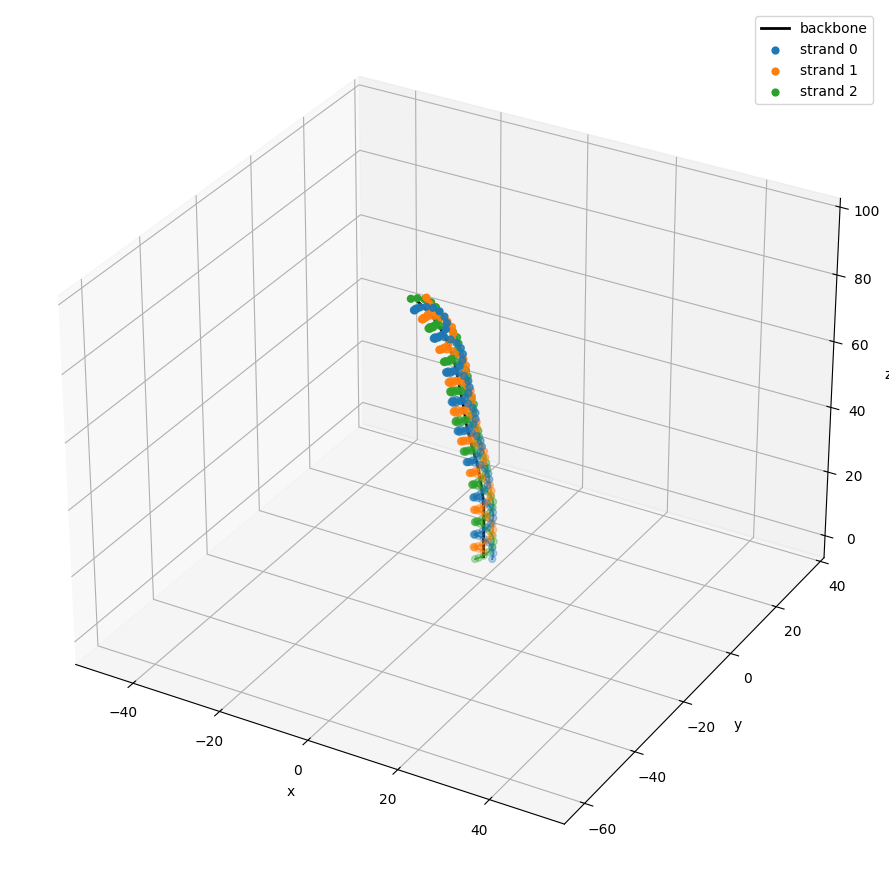

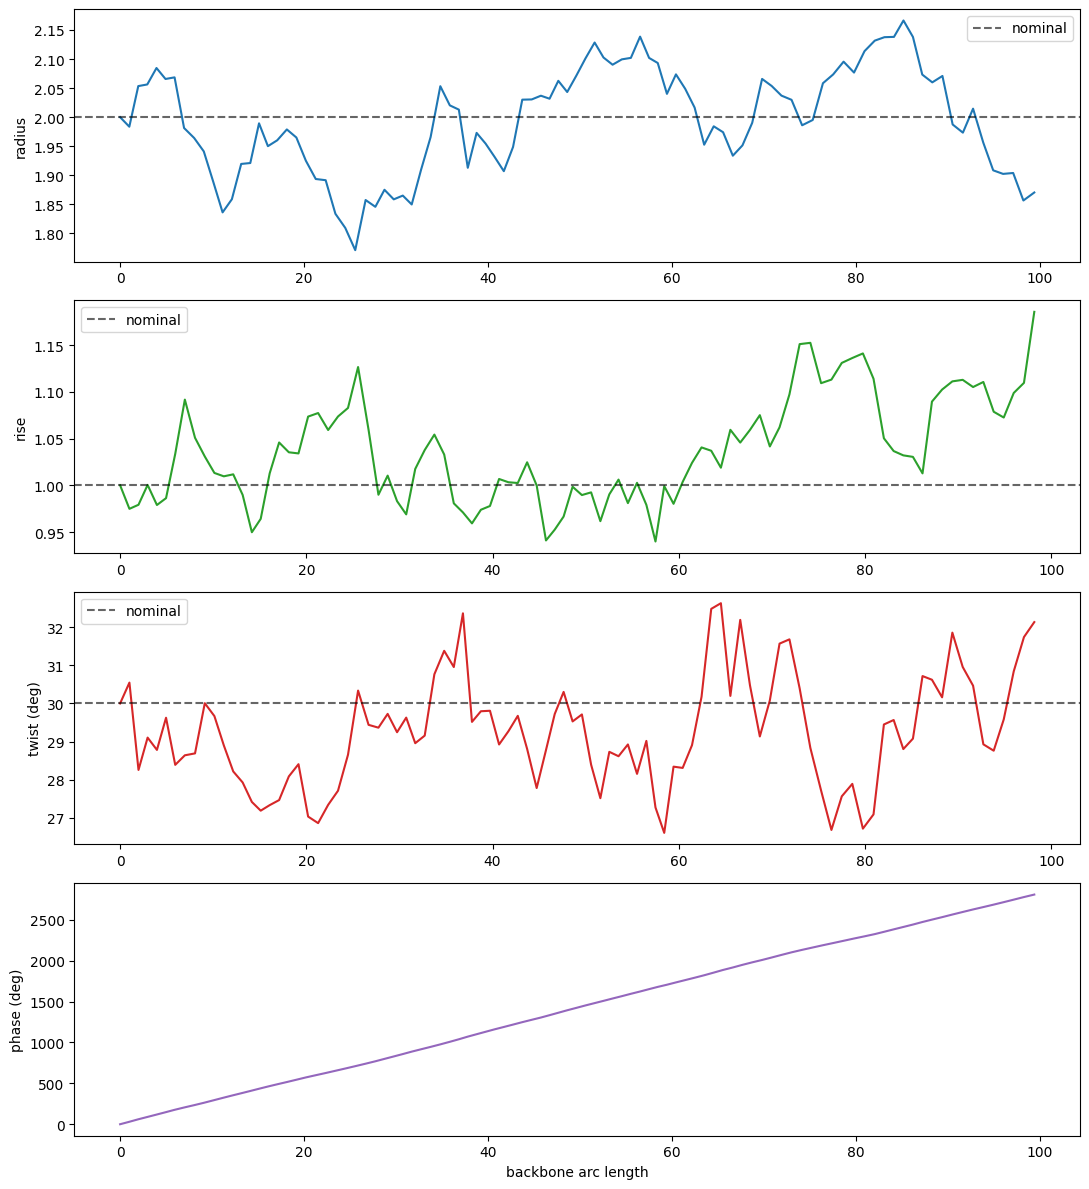

In [157]:
plot_clean_helix(clean_helix)
plot_helix_profiles(clean_helix)

In [160]:
helix_config_without_radius_variation = (
    HelixConfig(
        rise=helix_config.rise,
        twist_rad=helix_config.twist_rad,
        radius=helix_config.radius,
        n_strands=helix_config.n_strands,
        initial_phase_rad=helix_config.initial_phase_rad,
        strand_phase_offsets_rad=(
            helix_config.strand_phase_offsets_rad
        ),
        first_strand_id=helix_config.first_strand_id,
        rise_variation=helix_config.rise_variation,
        twist_variation=helix_config.twist_variation,
        radius_variation=ScalarProfileConfig(
            enabled=False
        ),
        seed=helix_config.seed,
    )
)

helix_without_radius_variation = generate_clean_helix(
    backbone=backbone,
    config=helix_config_without_radius_variation,
)

{
    "same_rise": np.array_equal(
        clean_helix.shared_local_rise,
        helix_without_radius_variation.shared_local_rise,
    ),
    "same_twist": np.array_equal(
        clean_helix.shared_local_twist_rad,
        helix_without_radius_variation.shared_local_twist_rad,
    ),
}

{'same_rise': True, 'same_twist': True}

# Degradation

In [161]:
@dataclass(frozen=True)
class DegradationConfig:
    missing_fraction: float = 0.0 # Fraction of the nodes deleted
    max_gap_size: int = 1 # Max consecutive nodes deleted
    shared_missing_mask_across_strands: bool = False # Gaps appear always on the same indices
    protect_strand_ends: bool = True # Save first and last nodes

    displacement_fraction: float = 0.0 # Fraction of real nodes that are displaced
    displacement_std: float = 0.0 # Typical deviation of the displacement

    near_false_positive_fraction: float = 0.0 # False positives close to real nodes, relative to the true observed nodes
    near_false_positive_std: float = 1.0

    background_false_positive_fraction: float = 0.0 # False positives distributed around the full volume
    background_margin_fraction: float = 0.25

    shuffle_observed_nodes: bool = True # Forbid that the order of the array shows which are the true nodes

    seed: int = 42

In [162]:
# Training metadata
FALSE_POSITIVE_NONE = np.int8(0)
FALSE_POSITIVE_NEAR_STRUCTURE = np.int8(1)
FALSE_POSITIVE_BACKGROUND = np.int8(2)

### Gap table

In [163]:
@dataclass
class GapTable:
    strand_id: np.ndarray
    gap_id: np.ndarray

    start_sequence_index: np.ndarray
    end_sequence_index: np.ndarray
    gap_size: np.ndarray
    
    left_clean_node_index: np.ndarray
    right_clean_node_index: np.ndarray

    missing_clean_node_indices: tuple[np.ndarray, ...]

### Observed helix

In [219]:
@dataclass
class ObservedHelixGeometry:
    # Input of the future model
    observed_positions: np.ndarray

    # Latent labels per observed nodes
    observed_to_clean_index: np.ndarray # False positive == -1
    observed_is_true: np.ndarray
    observed_is_displaced: np.ndarray
    observed_false_positive_type: np.ndarray

    # Correspondence from clean geometry
    clean_to_observed_index: np.ndarray # Missing node == -1
    clean_is_observed: np.ndarray
    clean_is_missing: np.ndarray

    # Displacement applied to true nodes
    clean_displacement: np.ndarray

    # Gap structural information
    gap_table: GapTable

    # Complete reference; only available during training
    clean_helix: CleanHelixGeometry

    # Summary
    n_observed_true: int
    n_missing: int
    n_near_false_positives: int
    n_background_false_positives: int

In [165]:
def validate_degradation_config(
    config: DegradationConfig,
    clean_helix: CleanHelixGeometry,
) -> None:
    """
    Valida los parámetros de degradación respecto a una hélice limpia.
    """
    fraction_values = {
        "missing_fraction": config.missing_fraction,
        "displacement_fraction": config.displacement_fraction,
        "near_false_positive_fraction": (
            config.near_false_positive_fraction
        ),
        "background_false_positive_fraction": (
            config.background_false_positive_fraction
        ),
    }

    for name, value in fraction_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

        if value < 0.0:
            raise ValueError(f"{name} cannot be negative")

    if config.missing_fraction >= 1.0:
        raise ValueError(
            "missing_fraction must be smaller than one"
        )

    if config.displacement_fraction > 1.0:
        raise ValueError(
            "displacement_fraction cannot exceed one"
        )

    positive_values = {
        "near_false_positive_std": (
            config.near_false_positive_std
        ),
        "background_margin_fraction": (
            config.background_margin_fraction
        ),
    }

    for name, value in positive_values.items():
        if not np.isfinite(value) or value < 0.0:
            raise ValueError(
                f"{name} must be finite and non-negative"
            )

    if (
        not np.isfinite(config.displacement_std)
        or config.displacement_std < 0.0
    ):
        raise ValueError(
            "displacement_std must be finite and non-negative"
        )

    if not isinstance(config.max_gap_size, (int, np.integer)):
        raise ValueError("max_gap_size must be an integer")

    if config.max_gap_size < 1:
        raise ValueError(
            "max_gap_size must be at least one"
        )

    if not isinstance(config.seed, (int, np.integer)):
        raise ValueError("seed must be an integer")

    boolean_values = {
        "shared_missing_mask_across_strands": (
            config.shared_missing_mask_across_strands
        ),
        "protect_strand_ends": config.protect_strand_ends,
        "shuffle_observed_nodes": config.shuffle_observed_nodes,
    }

    for name, value in boolean_values.items():
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError(f"{name} must be boolean")

    if not config.protect_strand_ends:
        raise ValueError(
            "the current implementation requires "
            "protect_strand_ends=True"
        )

    n_nodes_per_strand = clean_helix.n_nodes_per_strand

    n_missing = int(
        round(
            config.missing_fraction
            * n_nodes_per_strand
        )
    )

    maximum_missing = n_nodes_per_strand - 2

    if n_missing > maximum_missing:
        raise ValueError(
            "missing_fraction removes too many nodes while "
            "protecting strand endpoints"
        )

### Limited random composition

In [166]:
def sample_bounded_positive_composition(
    total: int,
    n_parts: int,
    max_part: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Divide 'total' in 'n_parts' positives integers <= 'max_part'Any

    Returns
    -------
    np.ndarray
        Shape (n_parts,), sum 'total' exactly
    """
    if not isinstance(total, (int, np.integer)):
        raise ValueError("total must be an integer")

    if not isinstance(n_parts, (int, np.integer)):
        raise ValueError("n_parts must be an integer")

    if not isinstance(max_part, (int, np.integer)):
        raise ValueError("max_part must be an integer")

    if total < 1:
        raise ValueError("total must be positive")

    if n_parts < 1:
        raise ValueError("n_parts must be positive")

    if max_part < 1:
        raise ValueError("max_part must be positive")

    if total < n_parts:
        raise ValueError(
            "total is too small for the requested number of parts"
        )

    if total > n_parts * max_part:
        raise ValueError(
            "total is too large for the requested bounded composition"
        )

    parts = np.ones(n_parts, dtype=np.int64)
    remaining = total - n_parts

    while remaining > 0:
        available = np.flatnonzero(parts < max_part)

        if len(available) == 0:
            raise RuntimeError(
                "no capacity remains in bounded composition"
            )

        selected = int(rng.choice(available))
        parts[selected] += 1
        remaining -= 1

    rng.shuffle(parts)

    return parts

### Constrution of gap mask

In [191]:
def sample_internal_gap_mask(
    n_nodes: int,
    missing_fraction: float,
    max_gap_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate internal gaps preserving the first and the last node

    Returns
    -------
    np.ndarray
        Boolean mask shape (n_nodes,). True indicates missing node
    """
    if n_nodes < 3:
        raise ValueError("at least three nodes are required")

    if missing_fraction < 0.0 or missing_fraction >= 1.0:
        raise ValueError(
            "missing_fraction must be in [0, 1)"
        )

    if max_gap_size < 1:
        raise ValueError(
            "max_gap_size must be at least one"
        )

    n_missing = int(round(missing_fraction * n_nodes))
    n_missing = min(n_missing, n_nodes - 2)

    missing_mask = np.zeros(n_nodes, dtype=bool)

    if n_missing == 0:
        return missing_mask

    n_observed = n_nodes - n_missing

    minimum_n_gaps = int(
        np.ceil(n_missing / max_gap_size)
    )

    maximum_n_gaps = min(
        n_missing,
        n_observed - 1,
    )

    if minimum_n_gaps > maximum_n_gaps:
        raise ValueError(
            "request missing fraction and max_gap_size "
            "cannot preserve observed nodes between gaps"
        )

    n_gaps = int(
        rng.integers(
            minimum_n_gaps,
            maximum_n_gaps + 1,
        )
    )

    gap_lengths = sample_bounded_positive_composition(
        total=n_missing,
        n_parts=n_gaps,
        max_part=max_gap_size,
        rng=rng,
    )

    observed_block_lengths = np.ones(
        n_gaps + 1,
        dtype=np.int64,
    )

    remaining_observed = (
        n_observed - (n_gaps + 1)
    )

    if remaining_observed > 0:
        extra_observed = rng.multinomial(
            remaining_observed,
            np.full(
                n_gaps + 1,
                1.0 / (n_gaps +1),
            ),
        )

        observed_block_lengths += extra_observed

    cursor = 0

    for gap_index in range(n_gaps):
        cursor += int(
            observed_block_lengths[gap_index]
        )

        gap_length = int(gap_lengths[gap_index])

        missing_mask[
            cursor : cursor + gap_length
        ] = True

        cursor += gap_length

    cursor += int(observed_block_lengths[-1])

    if cursor != n_nodes:
        raise RuntimeError(
            "gap mask construction produced an invalid length"
        )

    if missing_mask[0] or missing_mask[-1]:
        raise RuntimeError(
            "protected strand endpoints were removed"
        )

    if int(missing_mask.sum()) != n_missing:
        raise RuntimeError(
            "gap mask has an incorrect number of missing nodes"
        )

    return missing_mask


### Maximum length gap

In [168]:
def maximum_true_run_length(
    mask: np.ndarray,
) -> int:
    """
    Returns maximum length of True values
    """
    mask = np.asarray(mask, dtype=bool)

    if mask.ndim != 1:
        raise ValueError("mask must be one-dimensional")

    if len(mask) == 0 or not np.any(mask):
        return 0

    padded = np.concatenate([
        np.array([False]),
        mask,
        np.array([False]),
    ])

    changes = np.diff(padded.astype(np.int8))

    run_starts = np.flatnonzero(changes == 1)
    run_ends = np.flatnonzero(changes == -1)

    return int(
        np.max(run_ends - run_starts)
    )

### Multistrand missing mask

In [169]:
def generate_multistrand_missing_mask(
    clean_helix: CleanHelixGeometry,
    config: DegradationConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a missing mask with shape (N_clean,)
    """
    n_strands = clean_helix.n_strands
    nodes_per_strand = clean_helix.n_nodes_per_strand

    mask_matrix = np.zeros(
        (n_strands, nodes_per_strand),
        dtype=bool,
    )

    if config.missing_fraction == 0.0:
        return mask_matrix.reshape(-1)

    if config.shared_missing_mask_across_strands:
        shared_mask = sample_internal_gap_mask(
            n_nodes=nodes_per_strand,
            missing_fraction=config.missing_fraction,
            max_gap_size=config.max_gap_size,
            rng=rng,
        )

        mask_matrix[:] = shared_mask[None, :]
    else:
        for strand_position in range(n_strands):
            mask_matrix[strand_position] = (
                sample_internal_gap_mask(
                    n_nodes=nodes_per_strand,
                    missing_fraction=config.missing_fraction,
                    max_gap_size=config.max_gap_size,
                    rng=rng,
                )
            )

    return mask_matrix.reshape(-1)

### Extract gap intervals

In [217]:
def find_true_runs(
    mask: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Find continuous True intervals into a mask

    Returns
    -------
    starts, ends
        Initial indices included and excluded 
    """
    mask = np.asarray(mask, dtype=bool)

    if mask.ndim != 1:
        raise ValueError("mask must be one-dimensional")

    padded = np.concatenate([
        np.array([False]),
        mask,
        np.array([False]),
    ])

    changes = np.diff(padded.astype(np.int8))

    starts = np.flatnonzero(changes == 1).astype(
        np.int64
    )

    ends = np.flatnonzero(changes == -1).astype(
        np.int64
    )

    return starts, ends

### Gap table

In [172]:
def build_gap_table(
    clean_helix: CleanHelixGeometry,
    clean_is_missing: np.ndarray,
) -> GapTable:
    """
    Builds a table with a register per continuous gap
    """
    clean_is_missing = np.asarray(
        clean_is_missing,
        dtype=bool,
    )

    n_clean = len(clean_helix.positions)

    if clean_is_missing.shape != (n_clean,):
        raise ValueError(
            "clean_is_missing has an invalid shape"
        )

    strand_ids_output = []
    gap_ids_output = []
    start_sequence_output = []
    end_sequence_output = []
    gap_size_output = []
    left_clean_output = []
    right_clean_output = []
    missing_indices_output = []

    nodes_per_strand = clean_helix.n_nodes_per_strand
    unique_strands = np.unique(clean_helix.strand_id)

    global_gap_id = 0

    for strand_position, strand_value in enumerate(
        unique_strands
    ):
        global_start = (
            strand_position * nodes_per_strand
        )
        global_end = global_start + nodes_per_strand

        strand_missing = clean_is_missing[
            global_start:global_end
        ]

        starts, ends = find_true_runs(strand_missing)

        for local_start, local_end in zip(starts, ends):
            if local_start == 0 or local_end == nodes_per_strand:
                raise ValueError(
                    "gap table requires observed boundary nodes"
                )

            missing_global_indices = np.arange(
                global_start + local_start,
                global_start + local_end,
                dtype=np.int64,
            )

            strand_ids_output.append(int(strand_value))
            gap_ids_output.append(global_gap_id)

            start_sequence_output.append(
                int(local_start)
            )
            end_sequence_output.append(
                int(local_end - 1)
            )
            gap_size_output.append(
                int(local_end - local_start)
            )

            left_clean_output.append(
                int(global_start + local_start - 1)
            )
            right_clean_output.append(
                int(global_start + local_end)
            )

            missing_indices_output.append(
                missing_global_indices
            )

            global_gap_id += 1

    return GapTable(
        strand_id=np.asarray(
            strand_ids_output,
            dtype=np.int64,
        ),
        gap_id=np.asarray(
            gap_ids_output,
            dtype=np.int64,
        ),
        start_sequence_index=np.asarray(
            start_sequence_output,
            dtype=np.int64,
        ),
        end_sequence_index=np.asarray(
            end_sequence_output,
            dtype=np.int64,
        ),
        gap_size=np.asarray(
            gap_size_output,
            dtype=np.int64,
        ),
        left_clean_node_index=np.asarray(
            left_clean_output,
            dtype=np.int64,
        ),
        right_clean_node_index=np.asarray(
            right_clean_output,
            dtype=np.int64,
        ),
        missing_clean_node_indices=tuple(
            missing_indices_output
        ),
    )

### Displaced node selection

In [193]:
def sample_displaced_true_nodes(
    n_observed_true: int,
    displacement_fraction: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Select which true observed nodes are displaced

    Returns
    -------
    np.ndarray
        Boolean mask shape (n_observed_true,)
    """
    if n_observed_true < 0:
        raise ValueError(
            "n_observed_true cannot be negative"
        )

    if not 0.0 <= displacement_fraction <= 1.0:
        raise ValueError(
            "displacement_fraction must be in [0, 1]"
        )
    
    mask = np.zeros(n_observed_true, dtype=bool)

    n_displaced = int(
        round(
            displacement_fraction
            * n_observed_true
        )
    )

    if n_displaced == 0:
        return mask

    selected = rng.choice(
        n_observed_true,
        size=n_displaced,
        replace=False,
    )

    mask[selected] = True

    return mask

In [197]:
def displace_true_positions(
    clean_positions: np.ndarray,
    displacement_mask: np.ndarray,
    displacement_std: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Apply gaussian noise to nodes

    Returns
    -------
    displaced_positions
        Shape (N, 3)
    displacement_vectors
        Shape (N, 3)
    """
    clean_positions = np.asarray(
        clean_positions,
        dtype=np.float64,
    )
    displacement_mask = np.asarray(
        displacement_mask,
        dtype=bool,
    )

    if (
        clean_positions.ndim != 2
        or clean_positions.shape[1] != 3
    ):
        raise ValueError(
            "clean_positions must have shape (N, 3)"
        )

    if displacement_mask.shape != (
        len(clean_positions),
    ):
        raise ValueError(
            "displacement_mask has an invalid shape"
        )

    if displacement_std < 0.0:
        raise ValueError(
            "displacement_std cannot be negative"
        )

    displacement_vectors = np.zeros_like(
        clean_positions
    )

    n_displaced = int(displacement_mask.sum())

    if n_displaced > 0 and displacement_std > 0.0:
        displacement_vectors[displacement_mask] = (
            rng.normal(
                loc=0.0,
                scale=displacement_std,size=(n_displaced, 3),
            )
        )

    displaced_positions = (
        clean_positions + displacement_vectors
    )

    return displaced_positions, displacement_vectors

### Generate close false positives

In [177]:
def generate_near_structure_false_positive(
    reference_positions: np.ndarray,
    n_false_positives: int,
    noise_std: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate false positives around true observed positions
    """
    reference_positions = np.asarray(
        reference_positions,
        dtype=np.float64,
    )

    if (
        reference_positions.ndim != 2
        or reference_positions.shape[1] != 3
    ):
        raise ValueError(
            "reference_positions must have shape (N, 3)"
        )

    if n_false_positives < 0:
        raise ValueError(
            "n_false_positives cannot be negative"
        )

    if noise_std < 0.0:
        raise ValueError(
            "noise_std cannot be negative"
        )

    if n_false_positives == 0:
        return np.empty((0, 3), dtype=np.float64)

    if len(reference_positions) == 0:
        raise ValueError(
            "reference_positions cannot be empty"
        )

    anchor_indices = rng.integers(
        0,
        len(reference_positions),
        size=n_false_positives,
    )

    anchor_positions = reference_positions[
        anchor_indices
    ]

    offsets = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_false_positives, 3),
    )

    return anchor_positions + offsets

### Experimental bounding box

In [178]:
def compute_expanded_bounding_box(
    positions: np.ndarray,
    margin_fraction: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculate expanded bounding box around a cloud
    """
    positions = np.asarray(
        positions,
        dtype=np.float64,
    )

    if (
        positions.ndim != 2
        or positions.shape[1] != 3
        or len(positions) == 0
    ):
        raise ValueError(
            "positions must have shape (N, 3) with N > 0"
        )

    if margin_fraction < 0.0:
        raise ValueError(
            "margin_fraction cannot be negative"
        )

    minimum = np.min(positions, axis=0)
    maximum = np.max(positions, axis=0)

    extent = maximum - minimum
    reference_extent = max(
        float(np.max(extent)),
        1e-8,
    )

    margin = margin_fraction * reference_extent
    
    return minimum - margin, maximum + margin

### Background false positives

In [179]:
def generate_background_false_positives(
        reference_positions: np.ndarray,
        n_false_positives: int,
        margin_fraction: float,
        rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate uniform positions
    """
    if n_false_positives < 0:
        raise ValueError(
            "n_false_positives cannot be negative"
        )

    if n_false_positives == 0:
        return np.empty((0, 3), dtype=np.float64)

    lower, upper = compute_expanded_bounding_box(
        positions=reference_positions,
        margin_fraction=margin_fraction,
    )

    return rng.uniform(
        low=lower,
        high=upper,
        size=(n_false_positives, 3),
    )

### Independent random generator

In [180]:
def create_degradation_generators(
    seed: int,
) -> tuple[
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
]:
    """
    Create independent RNG for gaps, displacements, close false positives, background and shuffled
    """
    seed_sequence = np.random.SeedSequence(seed)

    child_sequences = seed_sequence.spawn(5)

    return tuple(
        np.random.default_rng(child)
        for child in child_sequences
    )

### Shuffled

In [181]:
def permute_observed_nodes(
    positions: np.ndarray,
    observed_to_clean_index: np.ndarray,
    observed_is_true: np.ndarray,
    observed_is_displaced: np.ndarray,
    false_positive_type: np.ndarray,
    rng: np.random.Generator,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Apply same permutation to all the fields
    """
    n_nodes = len(positions)

    expected_shapes = {
        "observed_to_clean_index": observed_to_clean_index,
        "observed_is_true": observed_is_true,
        "observed_is_displaced": observed_is_displaced,
        "false_positive_type": false_positive_type,
    }

    for name, values in expected_shapes.items():
        if values.shape != (n_nodes,):
            raise ValueError(
                f"{name} must have shape ({n_nodes},)"
            )

    permutation = rng.permutation(n_nodes)

    return (
        positions[permutation],
        observed_to_clean_index[permutation],
        observed_is_true[permutation],
        observed_is_displaced[permutation],
        false_positive_type[permutation],
    )

### Inverse mapping reconstruction

In [182]:
def build_clean_to_observed_mapping(
        observed_to_clean_index: np.ndarray,
        n_clean_nodes: int,
) -> np.ndarray:
    """
    Build clean_index -> observed_index
    
    Missing nodes recibe -1
    """
    observed_to_clean_index = np.asarray(
        observed_to_clean_index,
        dtype=np.int64,
    )

    if observed_to_clean_index.ndim != 1:
        raise ValueError(
            "observed_to_clean_index must be one-dimensional"
        )

    clean_to_observed = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )

    true_observed_indices = np.flatnonzero(
        observed_to_clean_index >= 0
    )

    clean_indices = observed_to_clean_index[
        true_observed_indices
    ]

    if np.any(clean_indices >= n_clean_nodes):
        raise ValueError(
            "observed_to_clean_index contains invalid indices"
        )

    if len(np.unique(clean_indices)) != len(clean_indices):
        raise ValueError(
            "multiple observed nodes map to the same clean node"
        )

    clean_to_observed[clean_indices] = (
        true_observed_indices
    )

    return clean_to_observed

### Degrade clean helix

In [211]:
def degrade_clean_helix(
    clean_helix: CleanHelixGeometry,
    config: DegradationConfig,
) -> ObservedHelixGeometry:
    """
    Generate observed cloud from clean helix

    'observed_positions' is the only node feature that will be available for the model
    """
    validate_degradation_config(
        config=config,
        clean_helix=clean_helix,
    )

    (
        missing_rng,
        displacement_rng,
        near_fp_rng,
        background_rng,
        shuffle_rng,
    ) = create_degradation_generators(config.seed)
    
    n_clean = len(clean_helix.positions)

    clean_is_missing = (
        generate_multistrand_missing_mask(
            clean_helix=clean_helix,
            config=config,
            rng=missing_rng,
        )
    )

    clean_is_observed = ~clean_is_missing

    observed_clean_indices = np.flatnonzero(
        clean_is_observed
    ).astype(np.int64)

    clean_true_positions = clean_helix.positions[
        observed_clean_indices
    ]

    observed_displacement_mask = (
        sample_displaced_true_nodes(
            n_observed_true=len(
                observed_clean_indices
            ),
            displacement_fraction=(
                config.displacement_fraction
            ),
            rng=displacement_rng,
        )
    )

    (
        displaced_true_positions,
        observed_displacement_vectors,
    ) = displace_true_positions(
        clean_positions=clean_true_positions,
        displacement_mask=observed_displacement_mask,
        displacement_std=config.displacement_std,
        rng=displacement_rng,
    )

    clean_displacement = np.zeros(
        (n_clean, 3),
        dtype=np.float64,
    )

    clean_displacement[
        observed_clean_indices
    ] = observed_displacement_vectors

    n_observed_true = len(observed_clean_indices)

    n_near_false_positives = int(
        round(
            config.near_false_positive_fraction
            * n_observed_true
        )
    )

    n_background_false_positives = int(
        round(
            config.background_false_positive_fraction
            * n_observed_true
        )
    )

    near_false_positive_positions = (
        generate_near_structure_false_positive(
            reference_positions=displaced_true_positions,
            n_false_positives=n_near_false_positives,
            noise_std=config.near_false_positive_std,
            rng=near_fp_rng,
        )
    )

    background_false_positive_positions = (
        generate_background_false_positives(
            reference_positions=clean_helix.positions,
            n_false_positives=(
                n_background_false_positives
            ),
            margin_fraction=(
                config.background_margin_fraction
            ),
            rng=background_rng,
        )
    )

    observed_positions = np.concatenate(
        [
            displaced_true_positions,
            near_false_positive_positions,
            background_false_positive_positions,
        ],
        axis=0,
    )

    observed_to_clean_index = np.concatenate([
        observed_clean_indices,
        np.full(
            n_near_false_positives,
            -1,
            dtype=np.int64,
        ),
        np.full(
            n_background_false_positives,
            -1,
            dtype=np.int64,
        ),
    ])

    observed_is_true = (
        observed_to_clean_index >= 0
    )

    observed_is_displaced = np.concatenate([
        np.full(
            n_observed_true,
            FALSE_POSITIVE_NONE,
            dtype=np.int8,
        ),
        np.full(
            n_near_false_positives,
            FALSE_POSITIVE_NEAR_STRUCTURE,
            dtype=np.int8,
        ),
        np.full(
            n_background_false_positives,
            FALSE_POSITIVE_BACKGROUND,
            dtype=np.int8,
        ),
    ])

    observed_false_positive_type = np.concatenate([
        np.full(
            n_observed_true,
            FALSE_POSITIVE_NONE,
            dtype=np.int8,
        ),
        np.full(
            n_near_false_positives,
            FALSE_POSITIVE_NEAR_STRUCTURE,
            dtype=np.int8,
        ),
        np.full(
            n_background_false_positives,
            FALSE_POSITIVE_BACKGROUND,
            dtype=np.int8,
        ),
    ])

    if config.shuffle_observed_nodes:
        (
            observed_positions,
            observed_to_clean_index,
            observed_is_true,
            observed_is_displaced,
            observed_false_positive_type,
        ) = permute_observed_nodes(
            positions=observed_positions,
            observed_to_clean_index=(
                observed_to_clean_index
            ),
            observed_is_true=observed_is_true,
            observed_is_displaced=(
                observed_is_displaced
            ),
            false_positive_type=(
                observed_false_positive_type
            ),
            rng=shuffle_rng,
        )

    clean_to_observed_index = (
        build_clean_to_observed_mapping(
            observed_to_clean_index=(
                observed_to_clean_index
            ),
            n_clean_nodes=n_clean,
        )
    )

    gap_table = build_gap_table(
        clean_helix=clean_helix,
        clean_is_missing=clean_is_missing,
    )

    return ObservedHelixGeometry(
        observed_positions=observed_positions,
        observed_to_clean_index=(
            observed_to_clean_index
        ),
        observed_is_true=observed_is_true,
        observed_is_displaced=(
            observed_is_displaced
        ),
        observed_false_positive_type=(
            observed_false_positive_type
        ),
        clean_to_observed_index=(
            clean_to_observed_index
        ),
        clean_is_observed=clean_is_observed,
        clean_is_missing=clean_is_missing,
        clean_displacement=clean_displacement,
        gap_table=gap_table,
        clean_helix=clean_helix,
        n_observed_true=n_observed_true,
        n_missing=int(clean_is_missing.sum()),
        n_near_false_positives=(
            n_near_false_positives
        ),
        n_background_false_positives=(
            n_background_false_positives
        ),
    )

    

In [212]:
def validate_gap_table(
    gap_table: GapTable,
    observed: ObservedHelixGeometry,
    max_gap_size: int,
) -> dict[str, bool]:
    """
    Valida límites, tamaños y nodos asociados a cada gap.
    """
    n_gaps = len(gap_table.gap_id)

    array_fields = {
        "strand_id": gap_table.strand_id,
        "start_sequence_index": (
            gap_table.start_sequence_index
        ),
        "end_sequence_index": (
            gap_table.end_sequence_index
        ),
        "gap_size": gap_table.gap_size,
        "left_clean_node_index": (
            gap_table.left_clean_node_index
        ),
        "right_clean_node_index": (
            gap_table.right_clean_node_index
        ),
    }

    for name, values in array_fields.items():
        if values.shape != (n_gaps,):
            raise ValueError(
                f"gap_table.{name} has an invalid shape"
            )

    all_gap_nodes_missing = True
    all_boundaries_observed = True
    all_sizes_correct = True

    for gap_index in range(n_gaps):
        missing_indices = (
            gap_table.missing_clean_node_indices[
                gap_index
            ]
        )

        left_index = int(
            gap_table.left_clean_node_index[gap_index]
        )
        right_index = int(
            gap_table.right_clean_node_index[gap_index]
        )

        all_gap_nodes_missing &= bool(
            np.all(
                observed.clean_is_missing[
                    missing_indices
                ]
            )
        )

        all_boundaries_observed &= bool(
            observed.clean_is_observed[left_index]
            and observed.clean_is_observed[right_index]
        )

        all_sizes_correct &= bool(
            len(missing_indices)
            == gap_table.gap_size[gap_index]
        )

    return {
        "gap_ids_are_unique": bool(
            len(np.unique(gap_table.gap_id))
            == n_gaps
        ),
        "gap_sizes_are_positive": bool(
            np.all(gap_table.gap_size > 0)
        ),
        "gap_sizes_respect_maximum": bool(
            np.all(gap_table.gap_size <= max_gap_size)
        ),
        "all_gap_nodes_are_missing": bool(
            all_gap_nodes_missing
        ),
        "all_gap_boundaries_are_observed": bool(
            all_boundaries_observed
        ),
        "all_gap_sizes_are_correct": bool(
            all_sizes_correct
        ),
    }

In [213]:
def validate_observed_helix(
    observed: ObservedHelixGeometry,
    config: DegradationConfig,
) -> dict[str, Any]:
    """
    Valida mappings, máscaras, posiciones y falsos positivos.
    """
    n_clean = len(observed.clean_helix.positions)
    n_observed = len(observed.observed_positions)

    if observed.observed_positions.shape != (
        n_observed,
        3,
    ):
        raise ValueError(
            "observed_positions has an invalid shape"
        )

    observed_fields = {
        "observed_to_clean_index": (
            observed.observed_to_clean_index
        ),
        "observed_is_true": observed.observed_is_true,
        "observed_is_displaced": (
            observed.observed_is_displaced
        ),
        "observed_false_positive_type": (
            observed.observed_false_positive_type
        ),
    }

    for name, values in observed_fields.items():
        if values.shape != (n_observed,):
            raise ValueError(
                f"{name} must have shape ({n_observed},)"
            )

    clean_fields = {
        "clean_to_observed_index": (
            observed.clean_to_observed_index
        ),
        "clean_is_observed": observed.clean_is_observed,
        "clean_is_missing": observed.clean_is_missing,
    }

    for name, values in clean_fields.items():
        if values.shape != (n_clean,):
            raise ValueError(
                f"{name} must have shape ({n_clean},)"
            )

    if observed.clean_displacement.shape != (
        n_clean,
        3,
    ):
        raise ValueError(
            "clean_displacement has an invalid shape"
        )

    true_observed_indices = np.flatnonzero(
        observed.observed_is_true
    )
    false_observed_indices = np.flatnonzero(
        ~observed.observed_is_true
    )

    mapped_clean_indices = (
        observed.observed_to_clean_index[
            true_observed_indices
        ]
    )

    reconstructed_clean_to_observed = (
        build_clean_to_observed_mapping(
            observed_to_clean_index=(
                observed.observed_to_clean_index
            ),
            n_clean_nodes=n_clean,
        )
    )

    expected_true_positions = (
        observed.clean_helix.positions[
            mapped_clean_indices
        ]
        + observed.clean_displacement[
            mapped_clean_indices
        ]
    )

    gap_checks = validate_gap_table(
        gap_table=observed.gap_table,
        observed=observed,
        max_gap_size=config.max_gap_size,
    )

    expected_n_missing_per_strand = int(
        round(
            config.missing_fraction
            * observed.clean_helix.n_nodes_per_strand
        )
    )

    missing_matrix = observed.clean_is_missing.reshape(
        observed.clean_helix.n_strands,
        observed.clean_helix.n_nodes_per_strand,
    )

    maximum_gap_found = max(
        (
            maximum_true_run_length(row)
            for row in missing_matrix
        ),
        default=0,
    )

    checks = {
        "all_observed_positions_finite": bool(
            np.all(
                np.isfinite(
                    observed.observed_positions
                )
            )
        ),
        "clean_masks_are_disjoint": bool(
            not np.any(
                observed.clean_is_observed
                & observed.clean_is_missing
            )
        ),
        "clean_masks_cover_all_nodes": bool(
            np.all(
                observed.clean_is_observed
                | observed.clean_is_missing
            )
        ),
        "true_flags_match_mapping": bool(
            np.array_equal(
                observed.observed_is_true,
                observed.observed_to_clean_index >= 0,
            )
        ),
        "false_positives_have_no_mapping": bool(
            np.all(
                observed.observed_to_clean_index[
                    false_observed_indices
                ] == -1
            )
        ),
        "clean_mapping_is_correct": bool(
            np.array_equal(
                observed.clean_to_observed_index,
                reconstructed_clean_to_observed,
            )
        ),
        "true_positions_are_correct": bool(
            np.allclose(
                observed.observed_positions[
                    true_observed_indices
                ],
                expected_true_positions,
            )
        ),
        "missing_nodes_have_no_observation": bool(
            np.all(
                observed.clean_to_observed_index[
                    observed.clean_is_missing
                ] == -1
            )
        ),
        "observed_nodes_have_mapping": bool(
            np.all(
                observed.clean_to_observed_index[
                    observed.clean_is_observed
                ] >= 0
            )
        ),
        "missing_count_is_correct_per_strand": bool(
            np.all(
                missing_matrix.sum(axis=1)
                == expected_n_missing_per_strand
            )
        ),
        "gap_maximum_is_respected": bool(
            maximum_gap_found <= config.max_gap_size
        ),
        "strand_ends_are_observed": bool(
            np.all(~missing_matrix[:, 0])
            and np.all(~missing_matrix[:, -1])
        ),
        "summary_true_count_is_correct": bool(
            observed.n_observed_true
            == int(observed.observed_is_true.sum())
        ),
        "summary_missing_count_is_correct": bool(
            observed.n_missing
            == int(observed.clean_is_missing.sum())
        ),
        "near_false_positive_count_is_correct": bool(
            observed.n_near_false_positives
            == int(
                np.sum(
                    observed.observed_false_positive_type
                    == FALSE_POSITIVE_NEAR_STRUCTURE
                )
            )
        ),
        "background_false_positive_count_is_correct": bool(
            observed.n_background_false_positives
            == int(
                np.sum(
                    observed.observed_false_positive_type
                    == FALSE_POSITIVE_BACKGROUND
                )
            )
        ),
    }

    checks.update({
        f"gap_{name}": value
        for name, value in gap_checks.items()
    })

    metrics = {
        "n_clean_nodes": n_clean,
        "n_observed_nodes": n_observed,
        "n_observed_true": observed.n_observed_true,
        "n_missing": observed.n_missing,
        "n_gaps": len(observed.gap_table.gap_id),
        "maximum_gap_found": maximum_gap_found,
        "n_displaced": int(
            observed.observed_is_displaced.sum()
        ),
        "n_near_false_positives": (
            observed.n_near_false_positives
        ),
        "n_background_false_positives": (
            observed.n_background_false_positives
        ),
        "actual_missing_fraction": float(
            observed.clean_is_missing.mean()
        ),
        "actual_false_positive_fraction": float(
            (
                observed.n_near_false_positives
                + observed.n_background_false_positives
            )
            / max(observed.n_observed_true, 1)
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Visualize the degradation

In [214]:
def plot_observed_helix(
    observed: ObservedHelixGeometry,
    show_clean_structure: bool = True,
):
    """
    Representa nodos observados, ausentes y falsos positivos.
    """
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")

    clean_positions = observed.clean_helix.positions

    if show_clean_structure:
        ax.scatter(
            clean_positions[:, 0],
            clean_positions[:, 1],
            clean_positions[:, 2],
            color="lightgray",
            s=10,
            alpha=0.35,
            label="clean target",
        )

    true_mask = observed.observed_is_true
    displaced_mask = (
        observed.observed_is_true
        & observed.observed_is_displaced
    )
    unchanged_mask = (
        observed.observed_is_true
        & ~observed.observed_is_displaced
    )

    near_fp_mask = (
        observed.observed_false_positive_type
        == FALSE_POSITIVE_NEAR_STRUCTURE
    )
    background_fp_mask = (
        observed.observed_false_positive_type
        == FALSE_POSITIVE_BACKGROUND
    )

    if np.any(unchanged_mask):
        positions = observed.observed_positions[
            unchanged_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:blue",
            s=25,
            label="observed true",
        )

    if np.any(displaced_mask):
        positions = observed.observed_positions[
            displaced_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:orange",
            s=30,
            label="displaced true",
        )

    if np.any(near_fp_mask):
        positions = observed.observed_positions[
            near_fp_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:red",
            marker="x",
            s=45,
            label="near false positive",
        )

    if np.any(background_fp_mask):
        positions = observed.observed_positions[
            background_fp_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:purple",
            marker="x",
            s=45,
            label="background false positive",
        )

    missing_positions = clean_positions[
        observed.clean_is_missing
    ]

    if len(missing_positions) > 0:
        ax.scatter(
            missing_positions[:, 0],
            missing_positions[:, 1],
            missing_positions[:, 2],
            facecolors="none",
            edgecolors="black",
            s=55,
            label="missing target",
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

In [215]:
degradation_config = DegradationConfig(
    missing_fraction=0.25,
    max_gap_size=5,
    shared_missing_mask_across_strands=False,
    protect_strand_ends=True,

    displacement_fraction=0.50,
    displacement_std=0.15,

    near_false_positive_fraction=0.10,
    near_false_positive_std=0.8,

    background_false_positive_fraction=0.05,
    background_margin_fraction=0.25,

    shuffle_observed_nodes=True,
    seed=456,
)

In [220]:
observed_helix = degrade_clean_helix(
    clean_helix=clean_helix,
    config=degradation_config,
)

observed_validation = validate_observed_helix(
    observed=observed_helix,
    config=degradation_config,
)

observed_validation

{'is_valid': True,
 'checks': {'all_observed_positions_finite': True,
  'clean_masks_are_disjoint': True,
  'clean_masks_cover_all_nodes': True,
  'true_flags_match_mapping': True,
  'false_positives_have_no_mapping': True,
  'clean_mapping_is_correct': True,
  'true_positions_are_correct': True,
  'missing_nodes_have_no_observation': True,
  'observed_nodes_have_mapping': True,
  'missing_count_is_correct_per_strand': True,
  'gap_maximum_is_respected': True,
  'strand_ends_are_observed': True,
  'summary_true_count_is_correct': True,
  'summary_missing_count_is_correct': True,
  'near_false_positive_count_is_correct': True,
  'background_false_positive_count_is_correct': True,
  'gap_gap_ids_are_unique': True,
  'gap_gap_sizes_are_positive': True,
  'gap_gap_sizes_respect_maximum': True,
  'gap_all_gap_nodes_are_missing': True,
  'gap_all_gap_boundaries_are_observed': True,
  'gap_all_gap_sizes_are_correct': True},
 'metrics': {'n_clean_nodes': 291,
  'n_observed_nodes': 252,
  'n_ob

(<Figure size 1100x900 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

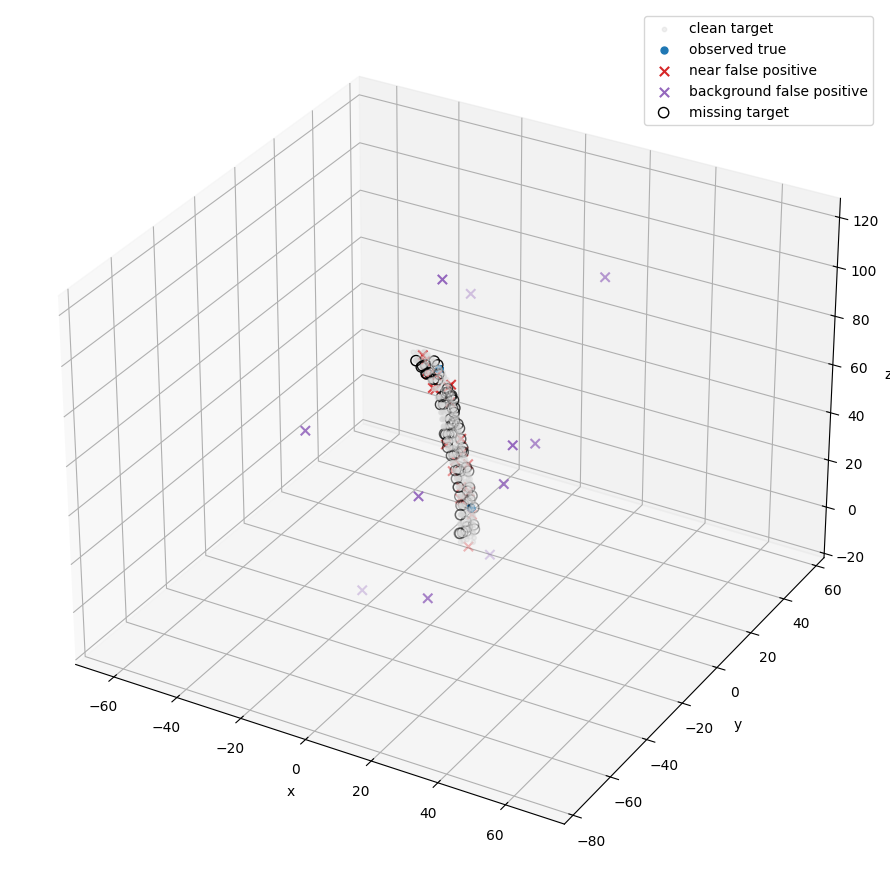

In [221]:
plot_observed_helix(observed_helix)

In [222]:
model_node_input = (
    observed_helix.observed_positions.astype(
        np.float32
    )
)

model_node_input.shape

(252, 3)

In [ ]:
from scipy.spatial import cKDTree

# Graph construction

### Edge type

In [224]:
EDGE_SOURCE_SEGMENTATION = np.uint8(1)
EDGE_SOURCE_SYMMETRIC_KNN = np.uint8(2)
EDGE_SOURCE_MUTUAL_KNN = np.uint8(4)
EDGE_SOURCE_FIXED_RADIUS = np.uint8(8)
EDGE_SOURCE_ADAPTIVE_RADIUS = np.uint8(16)
EDGE_SOURCE_FALLBACK = np.uint8(32)

### Graph configuration

In [252]:
@dataclass(frozen=True)
class ObservedGraphConfig:
    include_segmentation_adjacency: bool = True

    include_symmetric_knn: bool = True
    include_mutual_knn:bool = True
    k_neighbors: int = 6

    include_fixed_radius: bool = False
    fixed_radius: float = 3.0

    include_adaptive_radius: bool = True
    adaptive_k: int = 4
    adaptive_radius_factor: float = 1.5
    adaptive_rule: str = "mutual" # mutual: edge must have local radius of both nodes. "union": only one local radius

    ensure_no_isolated_nodes: bool = True
    fallback_k: int = 1

    maximum_edge_distance: float | None = None

    query_workers: int | None = 1

In [226]:
@dataclass
class ObservedGraph:
    node_positions: np.ndarray # Shape (N, 3)

    undirected_edge_index: np.ndarray #(2, E)
    edge_distance: np.ndarray # (E,)
    edge_displacement: np.ndarray # (E, 3) 
    edge_source_mask: np.ndarray # (E,)

    node_degree: np.ndarray # (N,)
    node_local_scale: np.ndarray # (N,)

    config: ObservedGraphConfig

In [255]:
def resolve_query_workers(
    query_workers: int | None,
) -> int:
    """
    Resolver the numbers of workers used by cKDTree.query

    Returns
    -------
    int
        -1 for all the cores or int
    """

    if query_workers is None:
        return 1

    if not isinstance(
        query_workers,
        (int, np.integer),
    ):
        raise ValueError(
            "query_workers must be None or an integer"
        )

    if query_workers == -1:
        return -1

    if query_workers < 1:
        raise ValueError(
            "query_workers must be -1 or a positive integer"
        )

    return int(query_workers)

### Validate graph positions

In [228]:
def validate_graph_positions(
    positions: np.ndarray,
) -> np.ndarray:
    """
    Validate and return float64 positions contiguous
    """
    positions = np.asarray(
        positions,
        dtype=np.float64,
        order="C",
    )

    if(
        positions.ndim != 2
        or positions.shape[1] != 3
    ):
        raise ValueError(
            "positions must have shape (N, 3)"
        )

    if len(positions) < 2:
        raise ValueError(
            "at least two nodes are required"
        )

    if not np.all(np.isfinite(positions)):
        raise ValueError(
            "positions contain non-finite values"
        )

    return positions

In [229]:
def validate_observed_graph_config(
    config: ObservedGraphConfig,
    n_nodes: int,
) -> None:
    if n_nodes < 2:
        raise ValueError(
            "at least two nodes are required"
        )

    boolean_fields = {
        "include_segmentation_adjacency": (
            config.include_segmentation_adjacency
        ),
        "include_symmetric_knn": (
            config.include_symmetric_knn
        ),
        "include_mutual_knn": (
            config.include_mutual_knn
        ),
        "include_fixed_radius": (
            config.include_fixed_radius
        ),
        "include_adaptive_radius": (
            config.include_adaptive_radius
        ),
        "ensure_no_isolated_nodes": (
            config.ensure_no_isolated_nodes
        ),
    }

    for name, value in boolean_fields.items():
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError(f"{name} must be boolean")

    integer_fields = {
        "k_neighbors": config.k_neighbors,
        "adaptive_k": config.adaptive_k,
        "fallback_k": config.fallback_k,
    }

    for name, value in integer_fields.items():
        if not isinstance(value, (int, np.integer)):
            raise ValueError(f"{name} must be an integer")

        if value < 1:
            raise ValueError(
                f"{name} must be at least one"
            )

    if config.fixed_radius <= 0.0:
        raise ValueError(
            "fixed_radius must be positive"
        )

    if config.adaptive_radius_factor <= 0.0:
        raise ValueError(
            "adaptive_radius_factor must be positive"
        )

    if config.adaptive_rule not in {
        "mutual",
        "union",
    }:
        raise ValueError(
            "adaptive_rule must be 'mutual' or 'union'"
        )

    if config.maximum_edge_distance is not None:
        if (
            not np.isfinite(
                config.maximum_edge_distance
            )
            or config.maximum_edge_distance <= 0.0
        ):
            raise ValueError(
                "maximum_edge_distance must be positive"
            )

    resolve_query_workers(config.query_workers)

    any_primary_method = any([
        config.include_segmentation_adjacency,
        config.include_symmetric_knn,
        config.include_mutual_knn,
        config.include_fixed_radius,
        config.include_adaptive_radius,
    ])

    if not any_primary_method:
        raise ValueError(
            "at least one graph construction method "
            "must be enabled"
        )

### Canonicalize edges

In [230]:
def canonicalize_undirected_edges(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Transform edges to the canonical form source < target,
    delete self-loop and duplicates

    Returns
    -------
    np.ndarray
        Unic edges with shape (2, E)
    """
    edge_index = np.asarray(
        edge_index,
        dtype=np.int64,
    )

    if edge_index.size == 0:
        return np.empty((2,0 ), dtype=np.int64)

    if (
        edge_index.ndim != 2
        or edge_index.shape[0] != 2
    ):
        raise ValueError(
            "edge_index must have shape (2, E)"
        )

    if np.any(edge_index < 0):
        raise ValueError(
            "edge_index contains negative indices"
        )

    if np.any(edge_index >= n_nodes):
        raise ValueError(
            "edge_index contains out-of-range indices"
        )

    source = np.minimum(
        edge_index[0],
        edge_index[1],
    )
    target = np.maximum(
        edge_index[0],
        edge_index[1],
    )

    non_self = source != target

    source = source[non_self]
    target = target[non_self]

    if len(source) == 0:
        return np.empty((2, 0), dtype=np.int64)

    encoded = source * np.int64(n_nodes) + target
    unique_encoded = np.unique(encoded)

    unique_source = unique_encoded // n_nodes
    unique_target = unique_encoded % n_nodes

    return np.stack(
        [unique_source, unique_target],
        axis = 0,
    ). astype(np.int64, copy=False)

### KNN shared query

In [231]:
def query_knn(
    positions: np.ndarray,
    k_neighbors: int,
    query_workers: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Find k closest neighbors excluding the source node

    Returns
    -------
    distances
        Shape (N, k_effective)
    neighbor_indices
        Shape (N, k_effective)
    """
    positions = validate_graph_positions(positions)

    if k_neighbors < 1:
        raise ValueError(
            "k_neighbors must be at least one"
        )

    n_nodes = len(positions)

    k_effective = min(
        int(k_neighbors),
        n_nodes - 1,
    )

    workers = resolve_query_workers(
        query_workers
    )

    tree = cKDTree(positions)

    distances, neighbor_indices = tree.query(
        positions,
        k=k_effective + 1,
        workers=workers,
    )

    if distances.ndim == 1:
        distances = distances[:, None]
        neighbor_indices = neighbor_indices[:, None]

    # First column corresponds to source node
    distances = distances[:, 1:]
    neighbor_indices = neighbor_indices[:, 1:]

    return (
        np.asarray(distances, dtype=np.float64),
        np.asarray(neighbor_indices, dtype=np.int64),
    )

### Symmetric KNN edges

In [232]:
def build_symmetric_knn_edges(
    neighbor_indices: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Build undirected joins of kNN
    """
    neighbor_indices = np.asarray(
        neighbor_indices,
        dtype=np.int64,
    )

    if neighbor_indices.ndim != 2:
        raise ValueError(
            "neighbor_indices must have shape (N, k)"
        )

    if neighbor_indices.shape[0] != n_nodes:
        raise ValueError(
            "neighbor_indices has an invalid first dimension"
        )
    
    source = np.repeat(
        np.arange(n_nodes, dtype=np.int64),
        neighbor_indices.shape[1],
    )
    target = neighbor_indices.reshape(-1)

    return canonicalize_undirected_edges(
        edge_index=np.stack(
            [source, target],
            axis=0,
        ),
        n_nodes=n_nodes,
    )

In [233]:
def build_mutual_knn_edges(
    neighbor_indices: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Maintain i--j only if i selects j and viceversa
    """
    neighbor_indices = np.asarray(
        neighbor_indices,
        dtype=np.int64,
    )

    if (
        neighbor_indices.ndim != 2
        or neighbor_indices.shape[0] != n_nodes
    ):
        raise ValueError(
            "neighbor_indices must have shape (N, k)"
    )

    k_effective = neighbor_indices.shape[1]

    source = np.repeat(
        np.arange(n_nodes, dtype=np.int64),
        k_effective,
    )
    target = neighbor_indices.reshape(-1)

    directed_codes = (
        source * np.int64(n_nodes) + target
    )

    reverse_codes = (
        target * np.int64(n_nodes) + source
    )

    directed_codes_sorted = np.sort(
        np.unique(directed_codes)
    )

    mutual_mask = np.isin(
        reverse_codes,
        directed_codes_sorted,
        assume_unique=False,
    )

    mutual_source = source[mutual_mask]
    mutual_target = target[mutual_mask]

    return canonicalize_undirected_edges(
        edge_index=np.stack(
            [mutual_source, mutual_target],
            axis=0,
        ),
        n_nodes=n_nodes,
    )

In [234]:
def build_fixed_radius_edges(
    positions: np.ndarray,
    radius: float,
) -> np.ndarray:
    """
    Connect all pairs with distance <= radius
    """
    positions = validate_graph_positions(positions)

    if radius <= 0.0:
        raise ValueError("radius must be positive")

    tree = cKDTree(positions)

    pairs = tree.query_pairse(
        r=radius,
        output_type="ndarray",
    )

    if pairs.size == 0:
        return np.empty((2, 0), dtype=np.int64)

    return canonicalize_undirected_edges(
        edge_index=pairs.T,
        n_nodes=len(positions),
    )

In [235]:
def compute_node_local_scale(
    knn_distances: np.ndarray,
    adaptive_k: int,
) -> np.ndarray:
    """
    Calculates local spatial scale per node

    Returns
    -------
    np.ndarray
        Shape(N,)
    """
    knn_distances = np.asarray(
        knn_distances,
        dtype=np.float64,
    )

    if knn_distances.ndim != 2:
        raise ValueError(
            "knn_distances must have shape (N, k)"
        )

    if adaptive_k < 1:
        raise ValueError(
            "adaptive_k must be at least one"
        )

    if knn_distances.shape[1] < adaptive_k:
        raise ValueError(
            "knn_distances does not contain enough neighbors"
        )
    
    local_scale = knn_distances[
        :,
        adaptive_k - 1,
    ].copy()

    positive_scales = local_scale[
        local_scale > 0.0
    ]

    if len(positive_scales) == 0:
        raise ValueError(
            "all local scales are zero; positions may be duplicated"
        )

    replacement = float(
        np.median(positive_scales)
    )

    local_scale[local_scale <= 0.0] = replacement
    
    return local_scale

In [262]:
def build_adaptive_radius_edges(
    positions: np.ndarray,
    local_scale: np.ndarray,
    radius_factor: float,
    rule: str,
    maximum_edge_distance: float | None = None,
) -> np.ndarray:
    """
    Build edges using different radius per node

    mutual:
        distance <= factor * min(scale_i, scale_j)

    union:
        distance <= factor * max(scale_i, scale_j)
    """
    positions = validate_graph_positions(positions)
    local_scale = np.asarray(
        local_scale,
        dtype=np.float64,
    )

    n_nodes = len(positions)

    if local_scale.shape != (n_nodes,):
        raise ValueError(
            "local_scale must have shape (N,)"
        )

    if np.any(local_scale <= 0.0):
        raise ValueError(
            "local_scale must be positive"
        )

    if radius_factor <= 0.0:
        raise ValueError(
            "radius_factor must be positive"
        )

    if rule not in {"mutual", "union"}:
        raise ValueError(
            "rule must be 'mutual' or 'union'"
        )

    node_radius = radius_factor * local_scale

    maximum_search_radius = float(
        np.max(node_radius)
    )

    if maximum_edge_distance is not None:
        maximum_search_radius = min(
            maximum_search_radius,
            maximum_edge_distance,
        )

    tree = cKDTree(positions)

    candidate_pairs = tree.query_pairs(
        r=maximum_search_radius,
        output_type="ndarray",
    )

    if candidate_pairs.size == 0:
        return np.empty((2, 0), dtype=np.int64)

    source = candidate_pairs[:, 0]
    target = candidate_pairs[:, 1]

    displacement = (
        positions[target] - positions[source]
    )
    distance = np.linalg.norm(
        displacement,
        axis=1,
    )

    if rule == "mutual":
        allowed_radius = np.minimum(
            node_radius[source],
            node_radius[target],
        )
    else:
        allowed_radius = np.maximum(
            node_radius[source],
            node_radius[target],
        )

    keep = distance <= allowed_radius

    if maximum_edge_distance is not None:
        keep &= distance <= maximum_edge_distance

    selected_pairs = candidate_pairs[keep]

    if len(selected_pairs) == 0:
        return np.empty((2, 0), dtype=np.int64)

    return selected_pairs.T.astype(
        np.int64,
        copy=False,
    )

### Filter edges by maximum distance

In [239]:
 def filter_edges_by_distance(
    positions: np.ndarray,
    edge_index: np.ndarray,
    maximum_distance: float | None,
 ) -> np.ndarray:
    """
    Delete edges longer than maximum_distance
    """
    if maximum_distance is None:
        return edge_index
    
    if maximum_distance <= 0.0:
        raise ValueError(
            "maximum_distance must be possitive"
        )

    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=len(positions),
    )

    if edge_index.shape[1] == 0:
        return edge_index

    source = edge_index[0]
    target = edge_index[1]

    distances = np.linalg.norm(
        positions[target] - positions[source],
        axis=1,
    )

    return edge_index[
        :,
        distances <= maximum_distance,
    ]

### Merge sourced edges

In [365]:
def merge_tagged_undirected_edges(
    n_nodes: int,
    tagged_edge_sets: list[
        tuple[np.ndarray, np.uint8]
    ],
) -> tuple[np.ndarray, np.ndarray]:
    """
    Merge edge sets and combine their source masks

    Returns
    -------
    edge_index
        Shape (2, E)
    edge_source_mask
        Shape (E,)
    """
    encoded_parts = []
    source_mask_parts = []

    for edge_index, source_flag in tagged_edge_sets:
        canonical = canonicalize_undirected_edges(
            edge_index=edge_index,
            n_nodes=n_nodes,
        )

        if canonical.shape[1] == 0:
            continue

        encoded = (
            canonical[0] * np.int64(n_nodes)
            + canonical[1]
        )

        encoded_parts.append(encoded)

        source_mask_parts.append(
            np.full(
                len(encoded),
                source_flag,
                dtype=np.uint8,
            )
        )
    if len(encoded_parts) == 0:
        return (
            np.empty((2, 0), dtype=np.int64),
            np.empty(0, dtype=np.uint8),
        )

    encoded_all = np.concatenate(encoded_parts)
    source_mask_all = np.concatenate(
        source_mask_parts
    )

    order = np.argsort(encoded_all)

    encoded_sorted = encoded_all[order]
    source_mask_sorted = source_mask_all[order]

    unique_encoded, first_indices = np.unique(
        encoded_sorted,
        return_index=True,
    )

    merged_source_mask = np.bitwise_or.reduceat(
        source_mask_sorted,
        first_indices,
    )

    source = unique_encoded // n_nodes
    target = unique_encoded % n_nodes

    edge_index = np.stack(
        [source, target],
        axis=0,
    ).astype(np.int64, copy=False)

    return edge_index, merged_source_mask

In [241]:
def compute_undirected_node_degree(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Calculates each node degree
    """
    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=n_nodes,
    )

    degree = np.zeros(
        n_nodes,
        dtype=np.int64,
    )

    if edge_index.shape[1] == 0:
        return degree

    np.add.at(
        degree,
        edge_index[0],
        1,
    )
    np.add.at(
        degree,
        edge_index[1],
        1,
    )

    return degree

### Connect isolated nodes

In [242]:
def build_isolated_node_fallback_edges(
    current_edge_index: np.ndarray,
    neighbor_indices: np.ndarray,
    n_nodes: int,
    fallback_k: int, 
) -> np.ndarray:
    """
    Connect isolated nodes with their closest neighbors
    """
    if fallback_k < 1:
        raise ValueError(
            "fallback_k must be at least one"
        )

    degree = compute_undirected_node_degree(
        edge_index=current_edge_index,
        n_nodes=n_nodes,
    )

    isolated_nodes = np.flatnonzero(
        degree == 0
    )
    if len(isolated_nodes) == 0:
        return np.empty((2, 0), dtype=np.int64)

    k_effective = min(
        fallback_k,
        neighbor_indices.shape[1],
    )

    source = np.repeat(
        isolated_nodes,
        k_effective,
    )

    target = neighbor_indices[
        isolated_nodes,
        :k_effective,
    ].reshape(-1)

    return canonicalize_undirected_edges(
        edge_index=np.stack(
            [source, target],
            axis=0,
        ),
        n_nodes=n_nodes,
    )

In [356]:
def validate_canonical_edge_index(
    edge_index: np.ndarray,
    n_nodes: int,
    require_unique: bool = True,
) -> np.ndarray:
    """
    Validate canonical edges unchanging their order

    It never reorder or eliminate edges

    Returns
    -------
    np.ndarray
        Same edge_index as int64 contiguous
    """
    edge_index = np.asarray(
        edge_index,
        dtype=np.int64,
        order="C",
    )

    if (
        edge_index.ndim != 2
        or edge_index.shape[0] != 2
    ):
        raise ValueError(
            "edge_index must have shape (2, E)"
        )

    if edge_index.shape[1] == 0:
        return edge_index

    source = edge_index[0]
    target = edge_index[1]

    if np.any(source < 0) or np.any(target < 0):
        raise ValueError(
            "edge_index contains negative indices"
        )

    if (
        np.any(source >= n_nodes)
        or np.any(target >= n_nodes)
    ):
        raise ValueError(
            "edge_index contains out-of-range indices"
        )

    if np.any(source >= target):
        raise ValueError(
            "canonical undirected edges must satisfy source < target"
        )

    if require_unique:
        encoded = (
            source * np.int64(n_nodes)
            + target
        )

        if len(np.unique(encoded)) != len(encoded):
            raise ValueError(
                "edge_index contains duplicate edges"
            )

    return edge_index

def compute_undirected_edge_geometry(
    positions: np.ndarray,
    edge_index: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculates geometry without changing edge order

    Calcula la geometría sin cambiar el orden de las aristas.

    Parameters
    ----------
    positions
        Shape (N, 3).
    edge_index
        Aristas ya canonicalizadas, shape (2, E).

    Returns
    -------
    displacement
        Sahpe (E, 3), same order as edge_index
    distance
        Shape (E,), same order as edge_index
    """
    positions = validate_graph_positions(
        positions
    )

    edge_index = validate_canonical_edge_index(
        edge_index=edge_index,
        n_nodes=len(positions),
        require_unique=True,
    )

    source = edge_index[0]
    target = edge_index[1]

    displacement = (
        positions[target]
        - positions[source]
    )

    distance = np.linalg.norm(
        displacement,
        axis=1,
    )

    return displacement, distance

In [243]:
def prepare_segmentation_edges(
        segmentation_edge_index: np.ndarray | None,
        n_nodes:int,
) -> np.ndarray:
    """
    Validate and canonicalize supervoxels adjacency
    """
    if segmentation_edge_index is None:
        return np.empty((2, 0), dtype=np.int64)

    return canonicalize_undirected_edges(
        edge_index=segmentation_edge_index,
        n_nodes=n_nodes,
    )

### Build observed graph

In [246]:
def merge_existing_graph_with_tagged_edges(
    n_nodes: int,
    existing_edge_index: np.ndarray,
    existing_source_mask: np.ndarray,
    new_edge_index: np.ndarray,
    new_source_flag: np.uint8,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Add new edges with edges mask
    """
    existing_edge_index = canonicalize_undirected_edges(
        edge_index=existing_edge_index,
        n_nodes=n_nodes,
    )

    existing_source_mask = np.asarray(
        existing_source_mask,
        dtype=np.uint8,
    )

    if existing_source_mask.shape != (
        existing_edge_index.shape[1],
    ):
        raise ValueError(
            "existing_source_mask has an invalid shape"
        )

    new_edge_index = canonicalize_undirected_edges(
        edge_index=new_edge_index,
        n_nodes=n_nodes,
    )

    existing_codes = (
        existing_edge_index[0] * np.int64(n_nodes)
        + existing_edge_index[1]
    )

    new_codes = (
        new_edge_index[0] * np.int64(n_nodes)
        + new_edge_index[1]
    )

    all_codes = np.concatenate([
        existing_codes,
        new_codes,
    ])

    all_masks = np.concatenate([
        existing_source_mask,
        np.full(
            len(new_codes),
            new_source_flag,
            dtype=np.uint8,
        ),
    ])

    if len(all_codes) == 0:
        return (
            np.empty((2, 0), dtype=np.int64),
            np.empty(0, dtype=np.uint8),
        )

    order = np.argsort(all_codes)
    sorted_codes = all_codes[order]
    sorted_masks = all_masks[order]

    unique_codes, first_indices = np.unique(
        sorted_codes,
        return_index=True,
    )

    merged_masks = np.bitwise_or.reduceat(
        sorted_masks,
        first_indices,
    )

    source = unique_codes // n_nodes
    target = unique_codes % n_nodes

    return (
        np.stack(
            [source, target],
            axis=0,
        ).astype(np.int64, copy=False),
        merged_masks,
    )

In [247]:
def build_observed_graph(
    observed: ObservedHelixGeometry,
    config: ObservedGraphConfig,
    segmentation_edge_index: np.ndarray | None = None,
) -> ObservedGraph:
    """
    Build undirected observed graph

    Only uses observed positions and, optionally, adjacency from the segmentation
    """
    positions = validate_graph_positions(
        observed.observed_positions
    )

    n_nodes = len(positions)

    validate_observed_graph_config(
        config=config,
        n_nodes=n_nodes,
    )

    maximum_required_k = max(
        config.k_neighbors
        if (
            config.include_symmetric_knn
            or config.include_mutual_knn
        )
        else 1,
        config.adaptive_k
        if config.include_adaptive_radius
        else 1,
        config.fallback_k
        if config.ensure_no_isolated_nodes
        else 1,
    )

    (
        knn_distances,
        neighbor_indices,
    ) = query_knn(
        positions=positions,
        k_neighbors=maximum_required_k,
        query_workers=resolve_query_workes(
            config.query_workers
        ),
    )

    adaptive_k_effective = min(
        config.adaptive_k,
        knn_distances.shape[1],
    )

    node_local_scale = compute_node_local_scale(
        knn_distances=knn_distances,
        adaptive_k=adaptive_k_effective,
    )

    tagged_edge_sets = []

    if config.include_segmentation_adjacency:
        segmentation_edges = prepare_segmentation_edges(
            segmentation_edge_index=(
                segmentation_edge_index
            ),
            n_nodes=n_nodes,
        )

        segmentation_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=segmentation_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            segmentation_edges,
            EDGE_SOURCE_SEGMENTATION,
        ))

    if config.include_symmetric_knn:
        symmetric_edges = build_symmetric_knn_edges(
            neighbor_indices=neighbor_indices[
                :, :min(
                    config.k_neighbors,
                    neighbor_indices.shape[1],
                )
            ],
            n_nodes=n_nodes,
        )

        symmetric_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=symmetric_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            symmetric_edges,
            EDGE_SOURCE_SYMMETRIC_KNN,
        ))

    if config.include_mutual_knn:
        mutual_edges = build_mutual_knn_edges(
            neighbor_indices=neighbor_indices[
                :, :min(
                    config.k_neighbors,
                    neighbor_indices.shape[1],
                )
            ],
            n_nodes=n_nodes,
        )

        mutual_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=mutual_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            mutual_edges,
            EDGE_SOURCE_MUTUAL_KNN,
        ))

    if config.include_fixed_radius:
        fixed_radius_edges = (
            build_fixed_radius_edges(
                positions=positions,
                radius=config.fixed_radius,
            )
        )

        fixed_radius_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=fixed_radius_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            fixed_radius_edges,
            EDGE_SOURCE_FIXED_RADIUS,
        ))

    if config.include_adaptive_radius:
        adaptive_radius_edges = (
            build_adaptive_radius_edges(
                positions=positions,
                local_scale=node_local_scale,
                radius_factor=(
                    config.adaptive_radius_factor
                ),
                rule=config.adaptive_rule,
                maximum_edge_distance=(
                    config.maximum_edge_distance
                ),
            )
        )

        tagged_edge_sets.append((
            adaptive_radius_edges,
            EDGE_SOURCE_ADAPTIVE_RADIUS,
        ))

    (
        edge_index,
        edge_source_mask,
    ) = merge_tagged_undirected_edges(
        n_nodes=n_nodes,
        tagged_edge_sets=tagged_edge_sets,
    )

    if config.ensure_no_isolated_nodes:
        fallback_edges = (
            build_isolated_node_fallback_edges(
                current_edge_index=edge_index,
                neighbor_indices=neighbor_indices,
                n_nodes=n_nodes,
                fallback_k=config.fallback_k,
            )
        )

        (
            edge_index,
            edge_source_mask,
        ) = merge_existing_graph_with_tagged_edges(
            n_nodes=n_nodes,
            existing_edge_index=edge_index,
            existing_source_mask=edge_source_mask,
            new_edge_index=fallback_edges,
            new_source_flag=EDGE_SOURCE_FALLBACK,
        )

    edge_displacement, edge_distance = (
        compute_undirected_edge_geometry(
            positions=positions,
            edge_index=edge_index,
        )
    )

    node_degree = compute_undirected_node_degree(
        edge_index=edge_index,
        n_nodes=n_nodes,
    )

    return ObservedGraph(
        node_positions=positions,
        undirected_edge_index=edge_index,
        edge_distance=edge_distance,
        edge_displacement=edge_displacement,
        edge_source_mask=edge_source_mask,
        node_degree=node_degree,
        node_local_scale=node_local_scale,
        config=config,
    )

### Message passing conversion

In [248]:
@dataclass
class DirectedMessagePassingGraph:
    node_positions: np.ndarray
    edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray
    edge_source_mask: np.ndarray

def prepare_directed_message_passing_graph(
        graph: ObservedGraph,
) -> DirectedMessagePassingGraph:
    """
    Duplicate each undirected edge in both directions
    """
    edge_index = graph.undirected_edge_index

    reverse_edge_index = edge_index[[1, 0]]

    directed_edge_index = np.concatenate(
        [edge_index, reverse_edge_index],
        axis=1,
    )

    directed_distance = np.concatenate(
        [graph.edge_distance, graph.edge_distance],
        axis=0,
    )

    directed_displacement = np.concatenate(
        [
            graph.edge_displacement,
            -graph.edge_displacement,
        ],
        axis=0,
    )

    directed_source_mask = np.concatenate(
        [
            graph.edge_source_mask,
            graph.edge_source_mask,
        ],
        axis=0,
    )

    return DirectedMessagePassingGraph(
        node_positions=graph.node_positions,
        edge_index=directed_edge_index,
        edge_distance=directed_distance,
        edge_displacement=directed_displacement,
        edge_source_mask=directed_source_mask,
    )

In [249]:
def validate_observed_graph(
    graph: ObservedGraph,
) -> dict[str, Any]:
    """
    Valida canonicalización, distancias, grados y duplicados.
    """
    n_nodes = len(graph.node_positions)
    n_edges = graph.undirected_edge_index.shape[1]

    if graph.node_positions.shape != (n_nodes, 3):
        raise ValueError(
            "node_positions has an invalid shape"
        )

    if graph.undirected_edge_index.shape != (
        2,
        n_edges,
    ):
        raise ValueError(
            "undirected_edge_index has an invalid shape"
        )

    if graph.edge_distance.shape != (n_edges,):
        raise ValueError(
            "edge_distance has an invalid shape"
        )

    if graph.edge_displacement.shape != (
        n_edges,
        3,
    ):
        raise ValueError(
            "edge_displacement has an invalid shape"
        )

    if graph.edge_source_mask.shape != (n_edges,):
        raise ValueError(
            "edge_source_mask has an invalid shape"
        )

    if graph.node_degree.shape != (n_nodes,):
        raise ValueError(
            "node_degree has an invalid shape"
        )

    if graph.node_local_scale.shape != (n_nodes,):
        raise ValueError(
            "node_local_scale has an invalid shape"
        )

    source = graph.undirected_edge_index[0]
    target = graph.undirected_edge_index[1]

    recomputed_displacement = (
        graph.node_positions[target]
        - graph.node_positions[source]
    )

    recomputed_distance = np.linalg.norm(
        recomputed_displacement,
        axis=1,
    )

    unique_edges = np.unique(
        graph.undirected_edge_index.T,
        axis=0,
    )

    recomputed_degree = compute_undirected_node_degree(
        edge_index=graph.undirected_edge_index,
        n_nodes=n_nodes,
    )

    checks = {
        "positions_are_finite": bool(
            np.all(np.isfinite(graph.node_positions))
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edge_indices_are_valid": bool(
            n_edges == 0
            or (
                np.min(source) >= 0
                and np.max(target) < n_nodes
            )
        ),
        "edges_are_unique": bool(
            len(unique_edges) == n_edges
        ),
        "displacements_are_correct": bool(
            np.allclose(
                graph.edge_displacement,
                recomputed_displacement,
            )
        ),
        "distances_are_correct": bool(
            np.allclose(
                graph.edge_distance,
                recomputed_distance,
            )
        ),
        "distances_are_positive": bool(
            np.all(graph.edge_distance > 0.0)
        ),
        "degrees_are_correct": bool(
            np.array_equal(
                graph.node_degree,
                recomputed_degree,
            )
        ),
        "source_masks_are_nonzero": bool(
            np.all(graph.edge_source_mask > 0)
        ),
        "local_scales_are_positive": bool(
            np.all(graph.node_local_scale > 0.0)
        ),
    }

    if graph.config.ensure_no_isolated_nodes:
        checks["no_isolated_nodes"] = bool(
            np.all(graph.node_degree > 0)
        )

    metrics = {
        "n_nodes": n_nodes,
        "n_undirected_edges": n_edges,
        "mean_degree": float(
            np.mean(graph.node_degree)
        ),
        "minimum_degree": int(
            np.min(graph.node_degree)
        ),
        "maximum_degree": int(
            np.max(graph.node_degree)
        ),
        "mean_edge_distance": float(
            np.mean(graph.edge_distance)
        ),
        "maximum_edge_distance": float(
            np.max(graph.edge_distance)
        ),
        "n_segmentation_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_SEGMENTATION
                ) != 0
            )
        ),
        "n_mutual_knn_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_MUTUAL_KNN
                ) != 0
            )
        ),
        "n_adaptive_radius_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_ADAPTIVE_RADIUS
                ) != 0
            )
        ),
        "n_fallback_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_FALLBACK
                ) != 0
            )
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Visualization

In [250]:
def plot_observed_graph(
    graph: ObservedGraph,
    observed: ObservedHelixGeometry | None = None,
):
    """
    Representa nodos y aristas del grafo observado.
    """
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")

    positions = graph.node_positions
    edges = graph.undirected_edge_index

    source_colors = [
        (
            EDGE_SOURCE_SEGMENTATION,
            "black",
            "segmentation",
        ),
        (
            EDGE_SOURCE_MUTUAL_KNN,
            "tab:blue",
            "mutual kNN",
        ),
        (
            EDGE_SOURCE_SYMMETRIC_KNN,
            "tab:cyan",
            "symmetric kNN",
        ),
        (
            EDGE_SOURCE_FIXED_RADIUS,
            "tab:green",
            "fixed radius",
        ),
        (
            EDGE_SOURCE_ADAPTIVE_RADIUS,
            "tab:orange",
            "adaptive radius",
        ),
        (
            EDGE_SOURCE_FALLBACK,
            "tab:red",
            "fallback",
        ),
    ]

    used_labels = set()

    for edge_position in range(edges.shape[1]):
        source = edges[0, edge_position]
        target = edges[1, edge_position]
        source_mask = graph.edge_source_mask[
            edge_position
        ]

        color = "gray"
        label = "other"

        for flag, candidate_color, candidate_label in (
            source_colors
        ):
            if source_mask & flag:
                color = candidate_color
                label = candidate_label
                break

        plot_label = (
            label if label not in used_labels else None
        )
        used_labels.add(label)

        ax.plot(
            [
                positions[source, 0],
                positions[target, 0],
            ],
            [
                positions[source, 1],
                positions[target, 1],
            ],
            [
                positions[source, 2],
                positions[target, 2],
            ],
            color=color,
            linewidth=0.7,
            alpha=0.45,
            label=plot_label,
        )

    if observed is None:
        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:blue",
            s=25,
            label="nodes",
        )
    else:
        true_mask = observed.observed_is_true
        false_mask = ~true_mask

        ax.scatter(
            positions[true_mask, 0],
            positions[true_mask, 1],
            positions[true_mask, 2],
            color="tab:blue",
            s=25,
            label="true observed",
        )

        if np.any(false_mask):
            ax.scatter(
                positions[false_mask, 0],
                positions[false_mask, 1],
                positions[false_mask, 2],
                color="tab:red",
                marker="x",
                s=40,
                label="false positive",
            )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

In [253]:
observed_graph_config = ObservedGraphConfig(
    include_segmentation_adjacency=False,

    include_symmetric_knn=False,
    include_mutual_knn=True,
    k_neighbors=6,

    include_fixed_radius=False,
    fixed_radius=3.0,

    include_adaptive_radius=True,
    adaptive_k=4,
    adaptive_radius_factor=1.5,
    adaptive_rule="mutual",

    ensure_no_isolated_nodes=True,
    fallback_k=1,

    maximum_edge_distance=None,

    query_workers=1,
)

In [265]:
observed_graph = build_observed_graph(
    observed=observed_helix,
    config=observed_graph_config,
    segmentation_edge_index=None,
)

graph_validation = validate_observed_graph(
    observed_graph
)

graph_validation

{'is_valid': True,
 'checks': {'positions_are_finite': True,
  'edges_are_canonical': True,
  'edge_indices_are_valid': True,
  'edges_are_unique': True,
  'displacements_are_correct': True,
  'distances_are_correct': True,
  'distances_are_positive': True,
  'degrees_are_correct': True,
  'source_masks_are_nonzero': True,
  'local_scales_are_positive': True,
  'no_isolated_nodes': True},
 'metrics': {'n_nodes': 252,
  'n_undirected_edges': 1498,
  'mean_degree': 11.88888888888889,
  'minimum_degree': 1,
  'maximum_degree': 18,
  'mean_edge_distance': 3.23277904232274,
  'maximum_edge_distance': 45.602521870900176,
  'n_segmentation_edges': 0,
  'n_mutual_knn_edges': 607,
  'n_adaptive_radius_edges': 1496,
  'n_fallback_edges': 2}}

(<Figure size 1100x900 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

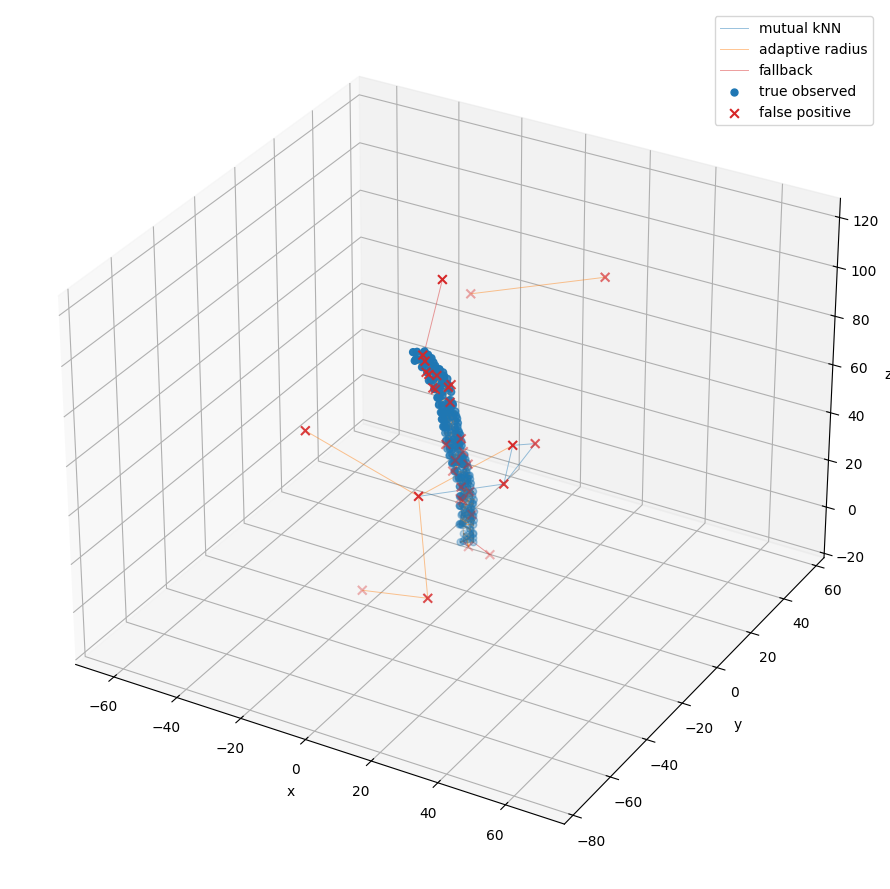

In [266]:
plot_observed_graph(
    graph=observed_graph,
    observed=observed_helix,
)

In [267]:
message_passing_graph = (
    prepare_directed_message_passing_graph(
        observed_graph
    )
)

# Target building

In [268]:
@dataclass
class ObservedNodeTargets:
    is_true_node: np.ndarray
    is_false_positive: np.ndarray

    has_position_target: np.ndarray
    clean_position: np.ndarray
    position_correction: np.ndarray

    clean_node_index: np.ndarray
    strand_id: np.ndarray
    sequence_index: np.ndarray

In [269]:
@dataclass
class ObservedEdgeTargets:
    both_nodes_are_true: np.ndarray
    same_strand: np.ndarray

    is_true_filament_edge: np.ndarray # Connect two real consecutive subunits
    is_gap_boundary_edge: np.ndarray # Connect two observed extrenes from a gap
    is_negative_edge: np.ndarray # Spatial edge that is not represented with the previous two

    has_local_structure_target: np.ndarray

    sequence_separation: np.ndarray
    missing_nodes_between: np.ndarray

    accumulated_rise: np.ndarray
    accumulated_twist_rad: np.ndarray

    mean_local_rise: np.ndarray
    mean_local_twist_rad: np.ndarray
    mean_backbone_curvature: np.ndarray

### Completion targets

In [270]:
@dataclass
class CompletionTargets:
    missing_clean_node_index: np.ndarray
    missing_position: np.ndarray

    strand_id: np.ndarray
    sequence_index: np.ndarray
    gap_id: np.ndarray

    left_clean_node_index: np.ndarray
    right_clean_node_index: np.ndarray

    left_observed_node_index: np.ndarray
    right_observed_node_index: np.ndarray

### Clean target graph

In [271]:
@dataclass
class CleanTargetGraph:
    node_positions: np.ndarray
    node_strand_id: np.ndarray
    node_sequence_index: np.ndarray
    node_backbone_curvature: np.ndarray

    undirected_edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray

    edge_local_rise: np.ndarray
    edge_local_twist_rad: np.ndarray
    edge_mean_backbone_curvature: np.ndarray

### Global targets

In [272]:
@dataclass
class GlobalHelixTargets:
    n_strands: int

    global_rise: float
    global_twist_rad: float
    global_radius: float

    nominal_rise: float
    nominal_twist_rad: float
    nominal_radius: float

    mean_backbone_curvature: float
    max_backbone_curvature: float

### Complete container

In [273]:
@dataclass
class HelixTrainingTargets:
    observed_node_targets: ObservedNodeTargets
    observed_edge_targets: ObservedEdgeTargets

    completion_targets: CompletionTargets
    clean_target_graph: CleanTargetGraph
    global_targets: GlobalHelixTargets

### Observed Target Nodes

In [297]:
def build_observed_node_targets(
        observed: ObservedHelixGeometry,
) -> ObservedNodeTargets:
    """
    Build targets per node of the observed graph
    """
    observed_positions = observed.observed_positions
    observed_to_clean = (
        observed.observed_to_clean_index
    )

    n_observed = len(observed_positions)

    if observed_to_clean.shape != (n_observed,):
        raise ValueError(
            "observed_to_clean_index has an invalid shape"
        )

    is_true_node = observed_to_clean >= 0
    is_false_positive = ~is_true_node
    has_position_target = is_true_node.copy()

    clean_position = np.zeros(
        (n_observed, 3),
        dtype=np.float64,
    )

    position_correction = np.zeros(
        (n_observed, 3),
        dtype=np.float64,
    )

    strand_id = np.full(
        n_observed,
        -1,
        dtype=np.int64,
    )

    sequence_index = np.full(
        n_observed,
        -1,
        dtype=np.int64,
    )

    true_observed_indices = np.flatnonzero(
        is_true_node
    )

    clean_indices = observed_to_clean[
        true_observed_indices
    ]

    clean_position[true_observed_indices] = (
        observed.clean_helix.positions[
            clean_indices
        ]
    )

    position_correction[true_observed_indices] = (
        clean_position[true_observed_indices]
        - observed_positions[true_observed_indices]
    )

    strand_id[true_observed_indices] = (
        observed.clean_helix.strand_id[
            clean_indices
        ]
    )

    sequence_index[true_observed_indices] = (
        observed.clean_helix.sequence_index[
            clean_indices
        ]
    )

    return ObservedNodeTargets(
        is_true_node=is_true_node,
        is_false_positive=is_false_positive,
        has_position_target=has_position_target,
        clean_position=clean_position,
        position_correction=position_correction,
        clean_node_index=observed_to_clean.copy(),
        strand_id=strand_id,
        sequence_index=sequence_index,
    )


### Encode undirected edges

In [ ]:
def encode_undirected_edge_pairs(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Encode each edge u < v as u * n_nodes + v
    """
    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=n_nodes,
    )

    return (
        edge_index[0] * np.int64(n_nodes)
        + edge_index[1]
    )

### Lookup encoded edge values

In [277]:
def lookup_encoded_edge_values(
    query_codes: np.ndarray,
    reference_codes: np.ndarray,
    reference_values: np.ndarray,
    default_value: int | float = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Lookup values asociated to the codes of the edges

    Returns
    -------
    found
        Boolean mask with shape equal to query_codes
    values
        Found values or default_value
    """
    query_codes = np.asarray(
        query_codes,
        dtype=np.int64,
    )
    reference_codes = np.asarray(
        reference_codes,
        dtype=np.int64,
    )
    reference_values = np.asarray(reference_values)

    if query_codes.ndim != 1:
        raise ValueError(
            "query_codes must be one-dimensional"
        )

    if reference_codes.ndim != 1:
        raise ValueError(
            "reference_codes must be one-dimensional"
        )

    if reference_values.shape != reference_codes.shape:
        raise ValueError(
            "reference_values and reference_codes must"
            "have the same shape"
        )

    output = np.full(
        query_codes.shape,
        default_value,
        dtype=reference_values.dtype,
    )

    found = np.zeros(
        query_codes.shape,
        dtype=bool,
    )

    if len(reference_codes) == 0:
        return found, output

    order = np.argsort(reference_codes)
    sorted_codes = reference_codes[order]
    sorted_values = reference_values[order]

    positions = np.searchsorted(
        sorted_codes,
        query_codes,
    )

    in_bounds = positions < len(sorted_codes)

    safe_positions = np.minimum(
        positions,
        len(sorted_codes) - 1,
    )

    found = (
        in_bounds
        & (
            sorted_codes[safe_positions]
            == query_codes
        )
    )

    output[found] = sorted_values[
        safe_positions[found]
    ]

    return found, output

### True edge codes

In [278]:
def build_clean_true_edge_codes(
    clean_helix: CleanHelixGeometry,
) -> np.ndarray:
    """
    Encode consecutive connections of the clean graph
    """
    return encode_undirected_edge_pairs(
        edge_index=clean_helix.undirected_edge_index,
        n_nodes=len(clean_helix.positions),
    )

In [279]:
def build_gap_boundary_codes(
    gap_table: GapTable,
    n_clean_nodes: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Encode each pair of clena nodes that delimite a gap

    Returns
    -------
    boundary_codes
        Shape (G,)
    gap_sizes
        Shape (G,)
    """
    left = gap_table.left_clean_node_index
    right = gap_table.right_clean_node_index

    if left.shape != right.shape:
        raise ValueError(
            "gap boundary arrays have inconsistent shapes"
        )

    if len(left) == 0:
        return(
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    boundary_edges = np.stack(
        [
            np.minimum(left, right),
            np.maximum(left, right),
        ],
        axis=0,
    )

    boundary_codes = encode_undirected_edge_pairs(
        edge_index=boundary_edges,
        n_nodes=n_clean_nodes,
    )

    return (
        boundary_codes,
        gap_table.gap_size.astype(
            np.int64,
            copy=True,
        ),
    )

### Mean interval curvature

In [281]:
def compute_interval_mean_values(
    values: np.ndarray,
    start_index: np.ndarray,
    end_index: np.ndarray,
    valid_mask: np.ndarray,
) -> np.ndarray:
    """
    Calculate inclusive mean between index pairs
    """

    values = np.asarray(
        values,
        dtype=np.float64,
    )
    start_index = np.asarray(
        start_index,
        dtype=np.int64,
    )
    end_index = np.asarray(
        end_index,
        dtype=np.int64,
    )
    valid_mask = np.asarray(
        valid_mask,
        dtype=bool,
    )

    if start_index.shape != end_index.shape:
        raise ValueError(
            "start_index and end_index must have the same shape"
        )

    if valid_mask.shape != start_index.shape:
        raise ValueError(
            "valid_mask has an invalid shape"
        )

    output = np.zeros(
        start_index.shape,
        dtype=np.float64,
    )

    if not np.any(valid_mask):
        return output

    cumulative = np.concatenate([
        np.array([0.0], dtype=np.float64),
        np.cumsum(values, dtype=np.float64),
    ])

    valid_start = start_index[valid_mask]
    valid_end = end_index[valid_mask]

    if np.any(valid_start < 0):
        raise ValueError(
            "start_index contains negative valid indices"
        )

    if np.any(valid_end >= len(values)):
        raise ValueError(
            "end_index contains out-of-range valid indices"
        )

    interval_sum = (
        cumulative[valid_end + 1]
        - cumulative[valid_start]
    )

    interval_length = (
        valid_end - valid_start + 1
    )

    output[valid_mask] = (
        interval_sum / interval_length
    )

    return output

In [299]:
def build_observed_edge_targets(
    observed: ObservedHelixGeometry,
    graph: ObservedGraph,
) -> ObservedEdgeTargets:
    """
    Classify observed edges and build local targets
    """
    n_clean = len(
        observed.clean_helix.positions
    )
    n_observed = len(
        observed.observed_positions
    )

    if len(graph.node_positions) != n_observed:
        raise ValueError(
            "graph and observed geometry contain differen numbers of nodes"
        )

    edge_index = graph.undirected_edge_index
    n_edges = edge_index.shape[1]

    source_observed = edge_index[0]
    target_observed = edge_index[1]

    source_clean = (
        observed.observed_to_clean_index[
            source_observed
        ]
    )
    target_clean = (
        observed.observed_to_clean_index[
            target_observed
        ]
    )

    both_nodes_are_true = (
        (source_clean >= 0)
        & (target_clean >= 0)
    )

    same_strand = np.zeros(
        n_edges,
        dtype=bool,
    )

    source_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )
    target_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    source_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    source_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    true_edge_codes = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    if np.any(both_nodes_are_true):
        valid_indices = np.flatnonzero(
            both_nodes_are_true
        )

        valid_source_clean = source_clean[
            valid_indices
        ]
        valid_target_clean = target_clean[
            valid_indices
        ]

        source_strand = (
            observed.clean_helix.strand_id[
                valid_source_clean
            ]
        )
        target_strand = (
            observed.clean_helix.strand_id[
                valid_target_clean
            ]
        )

        same_strand[valid_indices] = (
            source_strand == target_strand
        )

        source_sequence[valid_indices] = (
            observed.clean_helix.sequence_index[
                valid_source_clean
            ]
        )
        target_sequence[valid_indices] = (
            observed.clean_helix.sequence_index[
                valid_target_clean
            ]
        )

        source_arc_length[valid_indices] = (
            observed.clean_helix.arc_length[
                valid_source_clean
            ]
        )
        target_arc_length[valid_indices] = (
            observed.clean_helix.arc_length[
                valid_target_clean
            ]
        )

        source_phase[valid_indices] = (
            observed.clean_helix.phase_rad[
                valid_source_clean
            ]
        )
        target_phase[valid_indices] = (
            observed.clean_helix.phase_rad[
                valid_target_clean
            ]
        )

        clean_min = np.minimum(
            valid_source_clean,
            valid_target_clean,
        )
        clean_max = np.maximum(
            valid_source_clean,
            valid_target_clean,
        )

        true_edge_codes[valid_indices] = (
            clean_min * np.int64(n_clean)
            + clean_max
        )
    
    reference_true_codes = (
        build_clean_true_edge_codes(
            observed.clean_helix
        )
    )

    is_true_filament_edge = (
        both_nodes_are_true
        & np.isin(
            true_edge_codes,
            reference_true_codes,
        )
    )

    (
        gap_boundary_codes,
        gap_sizes,
    ) = build_gap_boundary_codes(
        gap_table=observed.gap_table,
        n_clean_nodes=n_clean,
    )

    (
        is_gap_boundary_edge,
        gap_size_lookup,
    ) = lookup_encoded_edge_values(
        query_codes=true_edge_codes,
        reference_codes=gap_boundary_codes,
        reference_values=gap_sizes,
        default_value=0,
    )

    is_gap_boundary_edge &= both_nodes_are_true

    is_negative_edge = ~(
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    has_local_structure_target = (
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    sequence_separation = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    valid_same_strand = (
        both_nodes_are_true
        & same_strand
    )

    sequence_separation[valid_same_strand] = (
        np.abs(
            target_sequence[valid_same_strand]
            - source_sequence[valid_same_strand]
        )
    )

    missing_nodes_between = np.zeros(
        n_edges,
        dtype=np.int64,
    )
    missing_nodes_between[
        is_gap_boundary_edge
    ] = gap_size_lookup[
        is_gap_boundary_edge
    ]

    accumulated_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    accumulated_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    if np.any(valid_same_strand):
        accumulated_rise[valid_same_strand] = (
            np.abs(
                target_arc_length[valid_same_strand]
                - source_arc_length[valid_same_strand]
            )
        )

        lower_sequence_first = (
            source_sequence <= target_sequence
        )

        forward_twist = (
            target_phase - source_phase
        )
        reverse_twist = (
            source_phase - target_phase
        )

        accumulated_twist_rad[
            valid_same_strand
        ] = np.where(
            lower_sequence_first[
                valid_same_strand
            ],
            forward_twist[valid_same_strand],
            reverse_twist[valid_same_strand],
        )

    mean_local_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    mean_local_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    nonzero_separation = (
        has_local_structure_target
        & (sequence_separation > 0)
    )

    mean_local_rise[nonzero_separation] = (
        accumulated_rise[nonzero_separation]
        / sequence_separation[nonzero_separation]
    )

    mean_local_twist_rad[nonzero_separation] = (
        accumulated_twist_rad[
            nonzero_separation
        ]
        / sequence_separation[
            nonzero_separation
        ]
    )

    lower_clean_index = np.minimum(
        source_clean,
        target_clean,
    )
    upper_clean_index = np.maximum(
        source_clean,
        target_clean,
    )

    safe_lower_clean = np.where(
        valid_same_strand,
        lower_clean_index,
        0,
    )
    safe_upper_clean = np.where(
        valid_same_strand,
        upper_clean_index,
        0,
    )

    mean_backbone_curvature = (
        compute_interval_mean_values(
            values=(
                observed.clean_helix.backbone_curvature
            ),
            start_index=safe_lower_clean,
            end_index=safe_upper_clean,
            valid_mask=has_local_structure_target,
        )
    )

    return ObservedEdgeTargets(
        both_nodes_are_true=both_nodes_are_true,
        same_strand=same_strand,
        is_true_filament_edge=(
            is_true_filament_edge
        ),
        is_gap_boundary_edge=is_gap_boundary_edge,
        is_negative_edge=is_negative_edge,
        has_local_structure_target=has_local_structure_target,
        sequence_separation=sequence_separation,
        missing_nodes_between=missing_nodes_between,
        accumulated_rise=accumulated_rise,
        accumulated_twist_rad=accumulated_twist_rad,
        mean_local_rise=mean_local_rise,
        mean_local_twist_rad=mean_local_twist_rad,
        mean_backbone_curvature=mean_backbone_curvature,
    )


### Assing missing nodes to gaps

In [301]:
def build_missing_node_gap_mapping(
    gap_table:GapTable,
    n_clean_nodes: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Assign clean missing node its gap and the limits

    Returns
    -------
    clean_gap_id
    clean_left_boundary
    clean_right_boundary

    The three arrays are (N_clean,) and value -1 for the nodes that are not part of the gap
    """
    clean_gap_id = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )
    clean_left_boundary = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )
    clean_right_boundary = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )

    for gap_position, missing_indices in enumerate(
        gap_table.missing_clean_node_indices
    ):
        gap_id = int(
            gap_table.gap_id[gap_position]
        )
        left_index = int(gap_table.left_clean_node_index[
            gap_position
        ])
        right_index = int(
            gap_table.right_clean_node_index[
                gap_position
            ]
        )

        clean_gap_id[missing_indices] = gap_id
        clean_left_boundary[missing_indices] = left_index
        clean_right_boundary[missing_indices] = right_index

    return (
        clean_gap_id,
        clean_left_boundary,
        clean_right_boundary,
    )


### Completion targets

In [285]:
def build_completion_targets(
    observed: ObservedHelixGeometry,
) -> CompletionTargets:
    """
    Build a register per missing node
    """
    clean_helix = observed.clean_helix
    n_clean = len(clean_helix.positions)

    missing_clean_node_index = np.flatnonzero(
        observed.clean_is_missing
    ).astype(np.int64)

    (
        clean_gap_id,
        clean_left_boundary,
        clean_right_boundary,
    ) = build_missing_node_gap_mapping(
        gap_table=observed.gap_table,
        n_clean_nodes=n_clean,
    )

    left_clean_node_index = (
        clean_left_boundary[
            missing_clean_node_index
        ]
    )
    right_clean_node_index = (
        clean_right_boundary[
            missing_clean_node_index
        ]
    )

    if len(missing_clean_node_index) > 0:
        if np.any(left_clean_node_index < 0):
            raise ValueError(
                "some missing nodes have no left gap boundary"
            )

        if np.any(right_clean_node_index < 0):
            raise ValueError(
                "some missing nodes have no right gap boundary"
            )

    left_observed_node_index = (
        observed.clean_to_observed_index[
            left_clean_node_index
        ]
        if len(missing_clean_node_index) > 9
        else np.empty(0, dtype=np.int64)
    )

    right_observed_node_index = (
        observed.clean_to_observed_index[
            right_clean_node_index
        ]
        if len(missing_clean_node_index) > 0
        else np.empty(0, dtype=np.int64)
    )

    return CompletionTargets(
        missing_clean_node_index=(
            missing_clean_node_index
        ),
        missing_position=clean_helix.positions[
            missing_clean_node_index
        ].copy(),
        strand_id=clean_helix.strand_id[
            missing_clean_node_index
        ].copy(),
        sequence_index=clean_helix.sequence_index[
            missing_clean_node_index
        ].copy(),
        gap_id=clean_gap_id[
            missing_clean_node_index
        ].copy(),
        left_clean_node_index=(
            left_clean_node_index.copy()
        ),
        right_clean_node_index=(
            right_clean_node_index.copy()
        ),
        left_observed_node_index=(
            left_observed_node_index.copy()
        ),
        right_observed_node_index=(
            right_observed_node_index.copy()
        ),
    )

### Complete target graph

In [303]:
def build_clean_target_graph(
    clean_helix: CleanHelixGeometry,
) -> CleanTargetGraph:
    """
    Build clean complete graph with undirected graph
    """
    node_positions = np.asarray(
        clean_helix.positions,
        dtype=np.float64,
    )

    edge_index = canonicalize_undirected_edges(
        edge_index=clean_helix.undirected_edge_index,
        n_nodes=len(node_positions),
    )

    edge_displacement, edge_distance = (
        compute_undirected_edge_geometry(
            positions=node_positions,
            edge_index=edge_index,
        )
    )

    source = edge_index[0]
    target = edge_index[1]

    edge_mean_backbone_curvature = 0.5 * (
        clean_helix.backbone_curvature[source]
        + clean_helix.backbone_curvature[target]
    )

    if clean_helix.local_rise.shape != (
        edge_index.shape[1],
    ):
        raise ValueError(
            "clean local_rise does not match target edges"
        )

    if clean_helix.local_twist_rad.shape != (
        edge_index.shape[1],
    ): 
        raise ValueError(
            "clean local_twist_rad does not match target edges"
        )

    return CleanTargetGraph(
        node_positions=node_positions.copy(),
        node_strand_id=(clean_helix.strand_id.copy()),
        node_sequence_index=(clean_helix.sequence_index.copy()),
        node_backbone_curvature=(clean_helix.backbone_curvature.copy()),
        undirected_edge_index=edge_index,
        edge_distance=edge_distance,
        edge_displacement=edge_displacement,
        edge_local_rise=(clean_helix.local_rise.copy()),
        edge_local_twist_rad=(clean_helix.local_twist_rad.copy()),
        edge_mean_backbone_curvature=(edge_mean_backbone_curvature)
    )


### Global targets

In [307]:
def build_global_helix_targets(
        clean_helix: CleanHelixGeometry,
) -> GlobalHelixTargets:
    """
    Build global targets withount counting many times the same backbone with different strands
    """
    shared_backbone_curvature = (
        clean_helix.backbone_curvature.reshape(
            clean_helix.n_strands,
            clean_helix.n_nodes_per_strand,
        )[0]
    )

    return GlobalHelixTargets(
        n_strands=int(clean_helix.n_strands),
        global_rise=float(
            clean_helix.global_rise
        ),
        global_twist_rad=float(
            clean_helix.global_twist_rad
        ),
        global_radius=float(
            clean_helix.global_radius
        ),
        nominal_rise=float(
            clean_helix.nominal_rise
        ),
        nominal_twist_rad=float(
            clean_helix.nominal_twist_rad
        ),
        nominal_radius=float(
            clean_helix.nominal_radius
        ),
        mean_backbone_curvature=float(
            np.mean(shared_backbone_curvature)
        ),
        max_backbone_curvature=float(
            np.max(shared_backbone_curvature)
        ),
    )

### Helix training targets

In [291]:
def build_helix_training_targets(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
) -> HelixTrainingTargets:
    """
    Build all the training target for a sample
    """
    if not np.array_equal(
        observed.observed_positions,
        observed_graph.node_positions,
    ):
        raise ValueError(
            "observed graph node order does not match the observed geometry"
        )

    observed_node_targets = (
        build_observed_node_targets(
            observed=observed
        )
    )

    observed_edge_targets = (
        build_observed_edge_targets(
            observed=observed,
            graph=observed_graph,
        )
    )

    completion_targets = (
        build_completion_targets(
            observed=observed
        )
    )

    clean_target_graph = (
        build_clean_target_graph(
            clean_helix=observed.clean_helix
        )
    )

    global_targets = (
        build_global_helix_targets(
            clean_helix=observed.clean_helix
        )
    )

    return HelixTrainingTargets(
        observed_node_targets=(
            observed_node_targets
        ),
        observed_edge_targets=(
            observed_edge_targets
        ),
        completion_targets=(
            completion_targets
        ),
        clean_target_graph=(
            clean_target_graph
        ),
        global_targets=global_targets,
    )

In [294]:
def validate_observed_node_targets(
    observed: ObservedHelixGeometry,
    targets: ObservedNodeTargets,
) -> dict[str, bool]:
    """
    Valida etiquetas y correcciones por nodo observado.
    """
    n_observed = len(
        observed.observed_positions
    )

    one_dimensional_fields = {
        "is_true_node": targets.is_true_node,
        "is_false_positive": (
            targets.is_false_positive
        ),
        "has_position_target": (
            targets.has_position_target
        ),
        "clean_node_index": (
            targets.clean_node_index
        ),
        "strand_id": targets.strand_id,
        "sequence_index": targets.sequence_index,
    }

    for name, values in one_dimensional_fields.items():
        if values.shape != (n_observed,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    if targets.clean_position.shape != (
        n_observed,
        3,
    ):
        raise ValueError(
            "clean_position has an invalid shape"
        )

    if targets.position_correction.shape != (
        n_observed,
        3,
    ):
        raise ValueError(
            "position_correction has an invalid shape"
        )

    true_mask = targets.is_true_node
    false_mask = targets.is_false_positive

    reconstructed_clean_position = (
        observed.observed_positions
        + targets.position_correction
    )

    return {
        "true_and_false_are_complementary": bool(
            np.array_equal(
                false_mask,
                ~true_mask,
            )
        ),
        "position_mask_matches_true_nodes": bool(
            np.array_equal(
                targets.has_position_target,
                true_mask,
            )
        ),
        "true_indices_are_valid": bool(
            np.all(
                targets.clean_node_index[
                    true_mask
                ] >= 0
            )
        ),
        "false_indices_are_minus_one": bool(
            np.all(
                targets.clean_node_index[
                    false_mask
                ] == -1
            )
        ),
        "false_strands_are_minus_one": bool(
            np.all(
                targets.strand_id[false_mask]
                == -1
            )
        ),
        "false_sequences_are_minus_one": bool(
            np.all(
                targets.sequence_index[false_mask]
                == -1
            )
        ),
        "correction_recovers_clean_position": bool(
            np.allclose(
                reconstructed_clean_position[
                    true_mask
                ],
                targets.clean_position[
                    true_mask
                ],
            )
        ),
    }

def validate_observed_edge_targets(
    graph: ObservedGraph,
    targets: ObservedEdgeTargets,
) -> dict[str, bool]:
    """
    Valida la clasificación y targets de aristas observadas.
    """
    n_edges = graph.undirected_edge_index.shape[1]

    boolean_fields = {
        "both_nodes_are_true": (
            targets.both_nodes_are_true
        ),
        "same_strand": targets.same_strand,
        "is_true_filament_edge": (
            targets.is_true_filament_edge
        ),
        "is_gap_boundary_edge": (
            targets.is_gap_boundary_edge
        ),
        "is_negative_edge": (
            targets.is_negative_edge
        ),
        "has_local_structure_target": (
            targets.has_local_structure_target
        ),
    }

    integer_fields = {
        "sequence_separation": (
            targets.sequence_separation
        ),
        "missing_nodes_between": (
            targets.missing_nodes_between
        ),
    }

    float_fields = {
        "accumulated_rise": (
            targets.accumulated_rise
        ),
        "accumulated_twist_rad": (
            targets.accumulated_twist_rad
        ),
        "mean_local_rise": (
            targets.mean_local_rise
        ),
        "mean_local_twist_rad": (
            targets.mean_local_twist_rad
        ),
        "mean_backbone_curvature": (
            targets.mean_backbone_curvature
        ),
    }

    all_fields = {
        **boolean_fields,
        **integer_fields,
        **float_fields,
    }

    for name, values in all_fields.items():
        if values.shape != (n_edges,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    positive = (
        targets.is_true_filament_edge
        | targets.is_gap_boundary_edge
    )

    target_type_count = (
        targets.is_true_filament_edge.astype(
            np.int8
        )
        + targets.is_gap_boundary_edge.astype(
            np.int8
        )
        + targets.is_negative_edge.astype(
            np.int8
        )
    )

    return {
        "edge_classes_are_exclusive": bool(
            np.all(target_type_count == 1)
        ),
        "structure_mask_is_correct": bool(
            np.array_equal(
                targets.has_local_structure_target,
                positive,
            )
        ),
        "positive_edges_have_true_nodes": bool(
            np.all(
                targets.both_nodes_are_true[
                    positive
                ]
            )
        ),
        "positive_edges_are_same_strand": bool(
            np.all(
                targets.same_strand[positive]
            )
        ),
        "true_edges_are_consecutive": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_true_filament_edge
                ] == 1
            )
        ),
        "true_edges_have_no_missing_between": bool(
            np.all(
                targets.missing_nodes_between[
                    targets.is_true_filament_edge
                ] == 0
            )
        ),
        "gap_edges_have_missing_nodes": bool(
            np.all(
                targets.missing_nodes_between[
                    targets.is_gap_boundary_edge
                ] > 0
            )
        ),
        "gap_separation_is_consistent": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_gap_boundary_edge
                ]
                == (
                    targets.missing_nodes_between[
                        targets.is_gap_boundary_edge
                    ]
                    + 1
                )
            )
        ),
        "local_rise_is_positive": bool(
            np.all(
                targets.mean_local_rise[
                    positive
                ] > 0.0
            )
        ),
        "float_targets_are_finite": bool(
            all(
                np.all(np.isfinite(values))
                for values in float_fields.values()
            )
        ),
    }

def validate_completion_targets(
    observed: ObservedHelixGeometry,
    targets: CompletionTargets,
) -> dict[str, bool]:
    """
    Valida los targets de nodos ausentes.
    """
    n_missing = observed.n_missing

    one_dimensional_fields = {
        "missing_clean_node_index": (
            targets.missing_clean_node_index
        ),
        "strand_id": targets.strand_id,
        "sequence_index": targets.sequence_index,
        "gap_id": targets.gap_id,
        "left_clean_node_index": (
            targets.left_clean_node_index
        ),
        "right_clean_node_index": (
            targets.right_clean_node_index
        ),
        "left_observed_node_index": (
            targets.left_observed_node_index
        ),
        "right_observed_node_index": (
            targets.right_observed_node_index
        ),
    }

    for name, values in one_dimensional_fields.items():
        if values.shape != (n_missing,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    if targets.missing_position.shape != (
        n_missing,
        3,
    ):
        raise ValueError(
            "missing_position has an invalid shape"
        )

    if n_missing == 0:
        return {
            "empty_completion_is_valid": True,
        }

    expected_missing_indices = np.flatnonzero(
        observed.clean_is_missing
    )

    expected_positions = (
        observed.clean_helix.positions[
            expected_missing_indices
        ]
    )

    return {
        "missing_indices_are_correct": bool(
            np.array_equal(
                targets.missing_clean_node_index,
                expected_missing_indices,
            )
        ),
        "missing_positions_are_correct": bool(
            np.allclose(
                targets.missing_position,
                expected_positions,
            )
        ),
        "gap_ids_are_valid": bool(
            np.all(targets.gap_id >= 0)
        ),
        "left_boundaries_are_observed": bool(
            np.all(
                observed.clean_is_observed[
                    targets.left_clean_node_index
                ]
            )
        ),
        "right_boundaries_are_observed": bool(
            np.all(
                observed.clean_is_observed[
                    targets.right_clean_node_index
                ]
            )
        ),
        "left_observed_indices_are_valid": bool(
            np.all(
                targets.left_observed_node_index
                >= 0
            )
        ),
        "right_observed_indices_are_valid": bool(
            np.all(
                targets.right_observed_node_index
                >= 0
            )
        ),
    }

def validate_clean_target_graph(
    graph: CleanTargetGraph,
) -> dict[str, bool]:
    """
    Valida el grafo limpio completo.
    """
    n_nodes = len(graph.node_positions)
    n_edges = graph.undirected_edge_index.shape[1]

    if graph.node_positions.shape != (n_nodes, 3):
        raise ValueError(
            "target node_positions has an invalid shape"
        )

    if graph.undirected_edge_index.shape != (
        2,
        n_edges,
    ):
        raise ValueError(
            "target edge_index has an invalid shape"
        )

    source = graph.undirected_edge_index[0]
    target = graph.undirected_edge_index[1]

    reconstructed_displacement = (
        graph.node_positions[target]
        - graph.node_positions[source]
    )

    reconstructed_distance = np.linalg.norm(
        reconstructed_displacement,
        axis=1,
    )

    return {
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edges_are_unique": bool(
            len(
                np.unique(
                    graph.undirected_edge_index.T,
                    axis=0,
                )
            )
            == n_edges
        ),
        "edges_remain_inside_strands": bool(
            np.all(
                graph.node_strand_id[source]
                == graph.node_strand_id[target]
            )
        ),
        "edges_join_consecutive_nodes": bool(
            np.all(
                graph.node_sequence_index[target]
                - graph.node_sequence_index[source]
                == 1
            )
        ),
        "displacements_are_correct": bool(
            np.allclose(
                graph.edge_displacement,
                reconstructed_displacement,
            )
        ),
        "distances_are_correct": bool(
            np.allclose(
                graph.edge_distance,
                reconstructed_distance,
            )
        ),
        "rise_is_positive": bool(
            np.all(graph.edge_local_rise > 0.0)
        ),
        "all_values_are_finite": bool(
            all([
                np.all(
                    np.isfinite(
                        graph.node_positions
                    )
                ),
                np.all(
                    np.isfinite(
                        graph.edge_distance
                    )
                ),
                np.all(
                    np.isfinite(
                        graph.edge_local_rise
                    )
                ),
                np.all(
                    np.isfinite(
                        graph.edge_local_twist_rad
                    )
                ),
            ])
        ),
    }

def validate_helix_training_targets(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    targets: HelixTrainingTargets,
) -> dict[str, Any]:
    """
    Ejecuta todas las validaciones de targets.
    """
    node_checks = validate_observed_node_targets(
        observed=observed,
        targets=targets.observed_node_targets,
    )

    edge_checks = validate_observed_edge_targets(
        graph=observed_graph,
        targets=targets.observed_edge_targets,
    )

    completion_checks = (
        validate_completion_targets(
            observed=observed,
            targets=targets.completion_targets,
        )
    )

    target_graph_checks = (
        validate_clean_target_graph(
            graph=targets.clean_target_graph
        )
    )

    checks = {}

    checks.update({
        f"node_{name}": value
        for name, value in node_checks.items()
    })

    checks.update({
        f"edge_{name}": value
        for name, value in edge_checks.items()
    })

    checks.update({
        f"completion_{name}": value
        for name, value in completion_checks.items()
    })

    checks.update({
        f"target_graph_{name}": value
        for name, value in target_graph_checks.items()
    })

    edge_targets = targets.observed_edge_targets

    metrics = {
        "n_observed_nodes": len(
            observed_graph.node_positions
        ),
        "n_observed_edges": (
            observed_graph
            .undirected_edge_index
            .shape[1]
        ),
        "n_true_filament_candidate_edges": int(
            edge_targets
            .is_true_filament_edge
            .sum()
        ),
        "n_gap_boundary_candidate_edges": int(
            edge_targets
            .is_gap_boundary_edge
            .sum()
        ),
        "n_negative_candidate_edges": int(
            edge_targets
            .is_negative_edge
            .sum()
        ),
        "n_missing_target_nodes": len(
            targets
            .completion_targets
            .missing_clean_node_index
        ),
        "n_target_nodes": len(
            targets
            .clean_target_graph
            .node_positions
        ),
        "n_target_edges": (
            targets
            .clean_target_graph
            .undirected_edge_index
            .shape[1]
        ),
        "target_n_strands": (
            targets.global_targets.n_strands
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Input function

In [311]:
@dataclass
class ModelGraphInput:
    node_positions: np.ndarray
    edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray

def build_model_graph_input(
    observed_graph: ObservedGraph,
) -> ModelGraphInput:
    """
    Build exclusivelly available tensors in inference

    Graph is expanded in both directions for message passing
    """
    directed = (
        prepare_directed_message_passing_graph(
            observed_graph
        )
    )

    return ModelGraphInput(
        node_positions=(
            directed.node_positions.astype(
                np.float32,
                copy=True,
            )
        ),
        edge_index=(
            directed.edge_index.astype(
                np.int64,
                copy=True,
            )
        ),
        edge_distance=(
            directed.edge_distance.astype(
                np.int32,
                copy=True,
            )
        ),
        edge_displacement=(
            directed.edge_displacement.astype(
                np.float32,
                copy=True,
            )
        ),
    )

In [308]:
training_targets = build_helix_training_targets(
    observed=observed_helix,
    observed_graph=observed_graph,
)

In [309]:
target_validation = (
    validate_helix_training_targets(
        observed=observed_helix,
        observed_graph=observed_graph,
        targets=training_targets,
    )
)

target_validation

{'is_valid': True,
 'checks': {'node_true_and_false_are_complementary': True,
  'node_position_mask_matches_true_nodes': True,
  'node_true_indices_are_valid': True,
  'node_false_indices_are_minus_one': True,
  'node_false_strands_are_minus_one': True,
  'node_false_sequences_are_minus_one': True,
  'node_correction_recovers_clean_position': True,
  'edge_edge_classes_are_exclusive': True,
  'edge_structure_mask_is_correct': True,
  'edge_positive_edges_have_true_nodes': True,
  'edge_positive_edges_are_same_strand': True,
  'edge_true_edges_are_consecutive': True,
  'edge_true_edges_have_no_missing_between': True,
  'edge_gap_edges_have_missing_nodes': True,
  'edge_gap_separation_is_consistent': True,
  'edge_local_rise_is_positive': True,
  'edge_float_targets_are_finite': True,
  'completion_missing_indices_are_correct': True,
  'completion_missing_positions_are_correct': True,
  'completion_gap_ids_are_valid': True,
  'completion_left_boundaries_are_observed': True,
  'completion

In [312]:
model_input = build_model_graph_input(
    observed_graph=observed_graph
)

print(
    "nodes:",
    model_input.node_positions.shape,
)

print(
    "directed message-passing edges:",
    model_input.edge_index.shape,
)

nodes: (252, 3)
directed message-passing edges: (2, 2996)


In [313]:
node_targets = (
    training_targets.observed_node_targets
)

edge_targets = (
    training_targets.observed_edge_targets
)

completion_targets = (
    training_targets.completion_targets
)

print(
    "true observed nodes:",
    int(node_targets.is_true_node.sum()),
)

print(
    "false positives:",
    int(node_targets.is_false_positive.sum()),
)

print(
    "true filament edges:",
    int(
        edge_targets
        .is_true_filament_edge
        .sum()
    ),
)

print(
    "gap boundary edges present in graph:",
    int(
        edge_targets
        .is_gap_boundary_edge
        .sum()
    ),
)

print(
    "missing nodes:",
    len(
        completion_targets
        .missing_clean_node_index
    ),
)

true observed nodes: 219
false positives: 33
true filament edges: 179
gap boundary edges present in graph: 27
missing nodes: 72


# GAP CANDIDATES

In [314]:
GAP_CANDIDATE_SOURCE_OBSERVED_GRAPH = np.uint8(1)
GAP_CANDIDATE_SOURCE_LARGE_KNN = np.uint8(2)
GAP_CANDIDATE_SOURCE_ADAPTIVE_RADIUS = np.uint8(4)

## Configuration

In [336]:
@dataclass(frozen=True)
class GapCandidateConfig:
    include_observed_graph_edges: bool = True

    include_large_knn: bool = True
    candidate_k: int = 24

    include_adaptive_radius: bool = True
    adaptive_radius_factor: float = 4.0
    adaptive_rule: str = "union"

    maximum_candidate_distance: float | None = None
    maximum_candidate_edges: int | None = None

    query_workers: int | None = 1

In [316]:
@dataclass
class GapCandidateGraph:
    node_positions: np.ndarray

    undirected_edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray
    edge_source_mask: np.ndarray

    is_observed_graph_edge: np.ndarray

    config: GapCandidateConfig

### Update observed edge targets

In [346]:
@dataclass
class ObservedEdgeTargets:
    both_nodes_are_true: np.ndarray
    same_strand: np.ndarray

    is_true_filament_edge: np.ndarray
    is_gap_boundary_edge: np.ndarray
    is_negative_edge: np.ndarray

    has_local_structure_target: np.ndarray

    sequence_separation: np.ndarray
    missing_nodes_between: np.ndarray
    gap_id: np.ndarray

    accumulated_rise: np.ndarray
    accumulated_twist_rad: np.ndarray

    mean_local_rise: np.ndarray
    mean_local_twist_rad: np.ndarray
    mean_backbone_curvature: np.ndarray

In [318]:
def validate_gap_candidate_config(
    config: GapCandidateConfig,
    n_nodes: int,
) -> None:
    """
    Valida la configuración del grafo de candidatos.
    """
    if n_nodes < 2:
        raise ValueError(
            "at least two nodes are required"
        )

    boolean_fields = {
        "include_observed_graph_edges": (
            config.include_observed_graph_edges
        ),
        "include_large_knn": (
            config.include_large_knn
        ),
        "include_adaptive_radius": (
            config.include_adaptive_radius
        ),
    }

    for name, value in boolean_fields.items():
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError(f"{name} must be boolean")

    if not any(boolean_fields.values()):
        raise ValueError(
            "at least one candidate construction method "
            "must be enabled"
        )

    if not isinstance(
        config.candidate_k,
        (int, np.integer),
    ):
        raise ValueError(
            "candidate_k must be an integer"
        )

    if config.candidate_k < 1:
        raise ValueError(
            "candidate_k must be at least one"
        )

    if (
        not np.isfinite(
            config.adaptive_radius_factor
        )
        or config.adaptive_radius_factor <= 0.0
    ):
        raise ValueError(
            "adaptive_radius_factor must be positive"
        )

    if config.adaptive_rule not in {
        "mutual",
        "union",
    }:
        raise ValueError(
            "adaptive_rule must be 'mutual' or 'union'"
        )

    if config.maximum_candidate_distance is not None:
        if (
            not np.isfinite(
                config.maximum_candidate_distance
            )
            or config.maximum_candidate_distance <= 0.0
        ):
            raise ValueError(
                "maximum_candidate_distance must be positive"
            )

    if config.maximum_candidate_edges is not None:
        if not isinstance(
            config.maximum_candidate_edges,
            (int, np.integer),
        ):
            raise ValueError(
                "maximum_candidate_edges must be an integer"
            )

        if config.maximum_candidate_edges < 1:
            raise ValueError(
                "maximum_candidate_edges must be positive"
            )

    resolve_query_workers(config.query_workers)

### Identify shared edges

In [322]:
def find_edges_in_reference_graph(
    query_edge_index: np.ndarray,
    reference_edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Show which query edges appears in the reference graph

    Returns
    -------
    np.ndarray
        Boolean mask (E_query,)
    """
    query_codes = encode_undirected_edge_pairs(
        edge_index=query_edge_index,
        n_nodes=n_nodes,
    )

    reference_codes = encode_undirected_edge_pairs(
        edge_index=reference_edge_index,
        n_nodes=n_nodes,
    )

    return np.isin(
        query_codes,
        reference_codes,
    )

### Protect if the graph is very dense

In [320]:
def validate_candidate_edge_count(
    n_edges: int,
    config: GapCandidateConfig,
) -> None:
    """
    Stop the generation if the number of candidates is higher than the limit
    """
    if (
        config.maximum_candidate_edges is not None
        and n_edges > config.maximum_candidate_edges
    ):
        raise ValueError(
            "gap candidate graph contains "
            f"{n_edges} edges, exceeding "
            f"maximum_candidate_edges="
            f"{config.maximum_candidate_edges}. "
            "Reduce candidate_k or adaptive_radius_factor."
        )

### Build candidate graph

In [323]:
def build_gap_candidate_graph(
        observed_graph:ObservedGraph,
        config: GapCandidateConfig,
) -> GapCandidateGraph:
    """
    Build candidate pairs exclusivelly from information available during inference
    """
    positions = validate_graph_positions(
        observed_graph.node_positions
    )

    n_nodes = len(positions)

    validate_gap_candidate_config(
        config=config,
        n_nodes=n_nodes,
    )

    tagged_edge_sets = []

    if config.include_observed_graph_edges:
        tagged_edge_sets.append((
            observed_graph.undirected_edge_index,
            GAP_CANDIDATE_SOURCE_OBSERVED_GRAPH,
        ))

    if config.include_large_knn:
        _, candidate_neighbor_indices = query_knn(
            positions=positions,
            k_neighbors=config.candidate_k,
            query_workers=resolve_query_workers(
                config.query_workers
            ),
        )

        large_knn_edges = build_symmetric_knn_edges(
            neighbor_indices=(
                candidate_neighbor_indices
            ),
            n_nodes=n_nodes,
        )

        large_knn_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=large_knn_edges,
            maximum_distance=(
                config.maximum_candidate_distance
            ),
        )

        tagged_edge_sets.append((
            large_knn_edges,
            GAP_CANDIDATE_SOURCE_LARGE_KNN,
        ))

    if config.include_adaptive_radius:
        adaptive_edges = (
            build_adaptive_radius_edges(
                positions=positions,
                local_scale=(
                    observed_graph.node_local_scale
                ),
                radius_factor=(
                    config.adaptive_radius_factor
                ),
                rule=config.adaptive_rule,
                maximum_edge_distance=(
                    config.maximum_candidate_distance
                ),
            )
        )

        tagged_edge_sets.append((
            adaptive_edges,
            GAP_CANDIDATE_SOURCE_ADAPTIVE_RADIUS,
        ))

    (
        candidate_edge_index,
        candidate_source_mask,
    ) = merge_tagged_undirected_edges(
        n_nodes=n_nodes,
        tagged_edge_sets=tagged_edge_sets,
    )

    validate_candidate_edge_count(
        n_edges=candidate_edge_index.shape[1],
        config=config,
    )

    (
        candidate_displacement,
        candidate_distance,
    ) = compute_undirected_edge_geometry(
        positions=positions,
        edge_index=candidate_edge_index,
    )

    is_observed_graph_edge = (
        find_edges_in_reference_graph(
            query_edge_index=candidate_edge_index,
            reference_edge_index=(
                observed_graph.undirected_edge_index
            ),
            n_nodes=n_nodes,
        )
    )

    return GapCandidateGraph(
        node_positions=positions.copy(),
        undirected_edge_index=(
            candidate_edge_index
        ),
        edge_distance=candidate_distance,
        edge_displacement=candidate_displacement,
        edge_source_mask=candidate_source_mask,
        is_observed_graph_edge=(
            is_observed_graph_edge
        ),
        config=config,
    )


In [342]:
def build_gap_boundary_metadata(
    gap_table: GapTable,
    n_clean_nodes: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Encode gap limit and return size and ID

    Returns
    -------
    boundary_codes
        Shape (G,)
    gap_sizes
        Shape (G,)
    gap_ids
        Shape (G,)
    """
    left = np.asarray(
        gap_table.left_clean_node_index,
        dtype=np.int64,
    )
    right = np.asarray(
        gap_table.right_clean_node_index,
        dtype=np.int64,
    )

    if left.shape != right.shape:
        raise ValueError(
            "gap boundaries have inconsistent shapes"
        )

    if len(left) == 0:
        return(
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    boundary_edge_index = np.stack(
        [
            np.minimum(left, right),
            np.maximum(left, right),
        ],
        axis=0,
    )

    boundary_codes = encode_undirected_edge_pairs(
        edge_index=boundary_edge_index,
        n_nodes=n_clean_nodes,
    )

    if len(np.unique(boundary_codes)) != len(boundary_codes):
        raise ValueError(
            "gap boundary pairs must be unique"
        )

    return (
        boundary_codes,
        gap_table.gap_size.astype(
            np.int64,
            copy=True,
        ),
        gap_table.gap_id.astype(
            np.int64,
            copy=True,
        ),
    )

### Build general targets for any edge set

In [344]:
def build_edge_targets_for_edge_index(
    observed: ObservedHelixGeometry,
    edge_index: np.ndarray,    
) -> ObservedEdgeTargets:
    """
    Build targets for any pair observed set

    It can be used for principal graph and gap candidate
    """
    n_clean = len(
        observed.clean_helix.positions
    )
    n_observed = len(
        observed.observed_positions
    )

    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=n_observed,
    )

    n_edges = edge_index.shape[1]

    source_observed = edge_index[0]
    target_observed = edge_index[1]

    source_clean = (
        observed.observed_to_clean_index[
            source_observed
        ]
    )
    target_clean = (
        observed.observed_to_clean_index[
            target_observed
        ]
    )

    both_nodes_are_true = (
        (source_clean >= 0)
        & (target_clean >= 0)
    )

    same_strand = np.zeros(
        n_edges,
        dtype=bool,
    )

    source_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )
    target_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    source_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    source_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_phase = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    clean_pair_codes = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    true_edge_indices = np.flatnonzero(
        both_nodes_are_true
    )

    if len(true_edge_indices) > 0:
        valid_source_clean = source_clean[
            true_edge_indices
        ]
        valid_target_clean = target_clean[
            true_edge_indices
        ]

        source_strand = (
            observed.clean_helix.strand_id[valid_source_clean]
        )
        target_strand = (
            observed.clean_helix.strand_id[
                valid_target_clean
            ]
        )

        same_strand[true_edge_indices] = (
            source_strand == target_strand
        )

        source_sequence[true_edge_indices] = (
            observed.clean_helix.sequence_index[
                valid_source_clean
            ]
        )
        target_sequence[true_edge_indices] = (
            observed.clean_helix.sequence_index[
                valid_target_clean
            ]
        )

        source_arc_length[true_edge_indices] = (
            observed.clean_helix.arc_length[
                valid_source_clean
            ]
        )
        target_arc_length[true_edge_indices] = (
            observed.clean_helix.arc_length[
                valid_target_clean
            ]
        )

        source_phase[true_edge_indices] = (
            observed.clean_helix.phase_rad[
                valid_source_clean
            ]
        )
        target_phase[true_edge_indices] = (
            observed.clean_helix.phase_rad[
                valid_target_clean
            ]
        )

        clean_minimum = np.minimum(
            valid_source_clean,
            valid_target_clean,
        )
        clean_maximum = np.maximum(
            valid_source_clean,
            valid_target_clean,
        )

        clean_pair_codes[true_edge_indices] = (
            clean_minimum * np.int64(n_clean)
            + clean_maximum
        )

    clean_true_edge_codes = (
        build_clean_true_edge_codes(
            clean_helix=observed.clean_helix
        )
    )

    is_true_filament_edge = (
        both_nodes_are_true
        & np.isin(
            clean_pair_codes,
            clean_true_edge_codes,
        )
    )

    (
        gap_boundary_codes,
        reference_gap_sizes,
        reference_gap_ids,
    ) = build_gap_boundary_metadata(
        gap_table=observed.gap_table,
        n_clean_nodes=n_clean,
    )

    (
        found_gap_boundary,
        gap_size_lookup,
    ) = lookup_encoded_edge_values(
        query_codes=clean_pair_codes,
        reference_codes=gap_boundary_codes,
        reference_values=reference_gap_sizes,
        default_value=0,
    )

    (
        found_gap_id,
        gap_id_lookup,
    ) = lookup_encoded_edge_values(
        query_codes=clean_pair_codes,
        reference_codes=gap_boundary_codes,
        reference_values=reference_gap_ids,
        default_value=-1,
    )

    is_gap_boundary_edge = (
        both_nodes_are_true
        & found_gap_boundary
        & found_gap_id
    )

    is_negative_edge = ~(
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    has_local_structure_target = (
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    sequence_separation = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    valid_same_strand = (
        both_nodes_are_true
        & same_strand
    )

    sequence_separation[valid_same_strand] = (
        np.abs(
            target_sequence[valid_same_strand]
            - source_sequence[valid_same_strand]
        )
    )

    missing_nodes_between = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    missing_nodes_between[
        is_gap_boundary_edge
    ] = gap_size_lookup[
        is_gap_boundary_edge
    ]

    gap_id = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    gap_id[is_gap_boundary_edge] = (
        gap_id_lookup[
            is_gap_boundary_edge
        ]
    )

    accumulated_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    accumulated_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    if np.any(valid_same_strand):
        accumulated_rise[valid_same_strand] = (
            np.abs(
                target_arc_length[
                    valid_same_strand
                ]
                - source_arc_length[
                    valid_same_strand
                ]
            )
        )

        source_comes_first = (
            source_sequence <= target_sequence
        )

        forward_twist = (
            target_phase - source_phase
        )
        reverse_twist = (
            source_phase - target_phase
        )

        accumulated_twist_rad[
            valid_same_strand
        ] = np.where(
            source_comes_first[
                valid_same_strand
            ],
            forward_twist[
                valid_same_strand
            ],
            reverse_twist[
                valid_same_strand
            ],
        )

    mean_local_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    mean_local_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    valid_structure = (
        has_local_structure_target
        & (sequence_separation > 0)
    )

    mean_local_rise[valid_structure] = (
        accumulated_rise[valid_structure]
        / sequence_separation[valid_structure]
    )

    mean_local_twist_rad[valid_structure] = (
        accumulated_twist_rad[valid_structure]
        / sequence_separation[valid_structure]
    )

    lower_clean_index = np.minimum(
        source_clean,
        target_clean,
    )
    upper_clean_index = np.maximum(
        source_clean,
        target_clean,
    )

    safe_lower_index = np.where(
        valid_structure,
        lower_clean_index,
        0,
    )
    safe_upper_index = np.where(
        valid_structure,
        upper_clean_index,
        0,
    )

    mean_backbone_curvature = (
        compute_interval_mean_values(
            values=(
                observed.clean_helix
                .backbone_curvature
            ),
            start_index=safe_lower_index,
            end_index=safe_upper_index,
            valid_mask=valid_structure,
        )
    )

    return ObservedEdgeTargets(
        both_nodes_are_true=both_nodes_are_true,
        same_strand=same_strand,
        is_true_filament_edge=(
            is_true_filament_edge
        ),
        is_gap_boundary_edge=(
            is_gap_boundary_edge
        ),
        is_negative_edge=is_negative_edge,
        has_local_structure_target=(
            has_local_structure_target
        ),
        sequence_separation=(
            sequence_separation
        ),
        missing_nodes_between=(
            missing_nodes_between
        ),
        gap_id=gap_id,
        accumulated_rise=accumulated_rise,
        accumulated_twist_rad=(
            accumulated_twist_rad
        ),
        mean_local_rise=mean_local_rise,
        mean_local_twist_rad=(
            mean_local_twist_rad
        ),
        mean_backbone_curvature=(
            mean_backbone_curvature
        ),
    )

### Redefine build_observed_edge_targets

In [326]:
def build_observed_edge_targets(
    observed: ObservedHelixGeometry,
    graph: ObservedGraph,
) -> ObservedEdgeTargets:
    """
    Build targets for the principal graph edges
    """
    if len(graph.node_positions) != len(
        observed.observed_positions
    ):
        raise ValueError(
            "graph and observed geometry have different "
            "numbers of nodes"
        )

    return build_edge_targets_for_edge_index(
        observed=observed,
        edge_index=graph.undirected_edge_index,
    )

In [327]:
def build_gap_candidate_targets(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> ObservedEdgeTargets:
    """
    Build target for gap cadidante pairs
    """
    if not np.array_equal(
        observed.observed_positions,
        candidate_graph.node_positions,
    ):
        raise ValueError(
            "candidate graph node order does not match "
            "observed geometry"
        )

    return build_edge_targets_for_edge_index(
        observed=observed,
        edge_index=(
            candidate_graph.undirected_edge_index
        ),
    )

### True gap limits in observed indices

In [ ]:
def build_observed_gap_boundary_edges(
    observed: ObservedHelixGeometry,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns clean limits for each gap to observed indices

    Returns
    -------
    observed_boundary_edges
        Shape (2, G).
    gap_ids
        Shape (G,).
    """
    gap_table = observed.gap_table

    n_gaps = len(gap_table.gap_id)

    if n_gaps == 0:
        return (
            np.empty((2, 0), dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    left_observed = (
        observed.clean_to_observed_index[
            gap_table.left_clean_node_index
        ]
    )

    right_observed = (
        observed.clean_to_observed_index[
            gap_table.right_clean_node_index
        ]
    )

    if np.any(left_observed < 0):
        raise ValueError(
            "some left gap boundaries are not observed"
        )

    if np.any(right_observed < 0):
        raise ValueError(
            "some right gap boundaries are not observed"
        )

    observed_boundary_edges = np.stack(
        [
            np.minimum(
                left_observed,
                right_observed,
            ),
            np.maximum(
                left_observed,
                right_observed,
            ),
        ],
        axis=0,
    )

    return (
        observed_boundary_edges,
        gap_table.gap_id.astype(
            np.int64,
            copy=True,
        ),
    )

### Recall candidate gaps

In [ ]:
def compute_gap_candidate_recall(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> dict[str, Any]:
    """
    Calcutates which true gap rate appears in the candidates
    """
    (
        true_boundary_edges,
        true_gap_ids,
    ) = build_observed_gap_boundary_edges(
        observed=observed
    )

    n_gaps = true_boundary_edges.shape[1]

    if n_gaps == 0:
        return {
            "n_gaps": 0,
            "n_recovered_gaps": 0,
            "recall": 1.0,
            "recovered_gap_mask": np.empty(
                0,
                dtype=bool,
            ),
            "missing_gap_ids": np.empty(
                0,
                dtype=np.int64,
            ),
        }

    n_observed = len(
        observed.observed_positions
    )

    true_codes = encode_undirected_edge_pairs(
        edge_index=true_boundary_edges,
        n_nodes=n_observed,
    )

    candidate_codes = encode_undirected_edge_pairs(
        edge_index=(
            candidate_graph.undirected_edge_index
        ),
        n_nodes=n_observed,
    )

    recovered_gap_mask = np.isin(
        true_codes,
        candidate_codes,
    )

    n_recovered = int(
        recovered_gap_mask.sum()
    )

    return {
        "n_gaps": n_gaps,
        "n_recovered_gaps": n_recovered,
        "recall": float(
            n_recovered / n_gaps
        ),
        "recovered_gap_mask": (
            recovered_gap_mask
        ),
        "missing_gap_ids": (
            true_gap_ids[
                ~recovered_gap_mask
            ]
        ),
    }

In [330]:
def summarize_gap_recall_by_size(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> dict[int, dict[str, float | int]]:
    """
    Summarize recall for each gap length
    """
    recall_result = compute_gap_candidate_recall(
        observed=observed,
        candidate_graph=candidate_graph,
    )

    if recall_result["n_gaps"] == 0:
        return {}

    recovered = recall_result[
        "recovered_gap_mask"
    ]

    gap_sizes = observed.gap_table.gap_size

    summary = {}

    for gap_size in np.unique(gap_sizes):
        size_mask = gap_sizes == gap_size

        n_total = int(size_mask.sum())
        n_recovered = int(
            np.sum(recovered[size_mask])
        )

        summary[int(gap_size)] = {
            "n_gaps": n_total,
            "n_recovered": n_recovered,
            "recall": float(
                n_recovered / n_total
            ),
        }

    return summary

### Distance between the limits of each gap

In [331]:
def compute_true_gap_boundary_distances(
    observed: ObservedHelixGeometry,
) -> np.ndarray:
    """
    Calculates euclidean distance between observed extremes of each gap
    """
    (
        boundary_edges,
        _,
    ) = build_observed_gap_boundary_edges(
        observed=observed
    )

    if boundary_edges.shape[1] == 0:
        return np.empty(
            0,
            dtype=np.float64,
        )

    positions = observed.observed_positions

    displacement = (
        positions[boundary_edges[1]]
        - positions[boundary_edges[0]]
    )

    return np.linalg.norm(
        displacement,
        axis=1,
    )

### Validation

In [332]:
def validate_gap_candidate_graph(
    candidate_graph: GapCandidateGraph,
    observed_graph: ObservedGraph,
) -> dict[str, Any]:
    """
    Valida el conjunto de candidatos.
    """
    n_nodes = len(
        candidate_graph.node_positions
    )
    n_edges = (
        candidate_graph
        .undirected_edge_index
        .shape[1]
    )

    if candidate_graph.node_positions.shape != (
        n_nodes,
        3,
    ):
        raise ValueError(
            "candidate node_positions has an invalid shape"
        )

    if candidate_graph.undirected_edge_index.shape != (
        2,
        n_edges,
    ):
        raise ValueError(
            "candidate edge_index has an invalid shape"
        )

    if candidate_graph.edge_distance.shape != (
        n_edges,
    ):
        raise ValueError(
            "candidate edge_distance has an invalid shape"
        )

    if candidate_graph.edge_displacement.shape != (
        n_edges,
        3,
    ):
        raise ValueError(
            "candidate edge_displacement has an invalid shape"
        )

    if candidate_graph.edge_source_mask.shape != (
        n_edges,
    ):
        raise ValueError(
            "candidate edge_source_mask has an invalid shape"
        )

    if candidate_graph.is_observed_graph_edge.shape != (
        n_edges,
    ):
        raise ValueError(
            "is_observed_graph_edge has an invalid shape"
        )

    source = (
        candidate_graph.undirected_edge_index[0]
    )
    target = (
        candidate_graph.undirected_edge_index[1]
    )

    reconstructed_displacement = (
        candidate_graph.node_positions[target]
        - candidate_graph.node_positions[source]
    )

    reconstructed_distance = np.linalg.norm(
        reconstructed_displacement,
        axis=1,
    )

    expected_observed_membership = (
        find_edges_in_reference_graph(
            query_edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            reference_edge_index=(
                observed_graph
                .undirected_edge_index
            ),
            n_nodes=n_nodes,
        )
    )

    observed_edges_in_candidates = (
        find_edges_in_reference_graph(
            query_edge_index=(
                observed_graph
                .undirected_edge_index
            ),
            reference_edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            n_nodes=n_nodes,
        )
    )

    unique_edges = np.unique(
        candidate_graph.undirected_edge_index.T,
        axis=0,
    )

    checks = {
        "same_node_positions_as_observed_graph": bool(
            np.array_equal(
                candidate_graph.node_positions,
                observed_graph.node_positions,
            )
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edges_are_unique": bool(
            len(unique_edges) == n_edges
        ),
        "edge_indices_are_valid": bool(
            n_edges == 0
            or (
                np.min(source) >= 0
                and np.max(target) < n_nodes
            )
        ),
        "edge_distances_are_correct": bool(
            np.allclose(
                candidate_graph.edge_distance,
                reconstructed_distance,
            )
        ),
        "edge_displacements_are_correct": bool(
            np.allclose(
                candidate_graph.edge_displacement,
                reconstructed_displacement,
            )
        ),
        "source_masks_are_nonzero": bool(
            np.all(
                candidate_graph.edge_source_mask > 0
            )
        ),
        "observed_membership_is_correct": bool(
            np.array_equal(
                candidate_graph.is_observed_graph_edge,
                expected_observed_membership,
            )
        ),
    }

    if (
        candidate_graph
        .config
        .include_observed_graph_edges
    ):
        checks[
            "all_observed_edges_are_candidates"
        ] = bool(
            np.all(observed_edges_in_candidates)
        )

    metrics = {
        "n_nodes": n_nodes,
        "n_candidate_edges": n_edges,
        "n_observed_graph_edges": (
            observed_graph
            .undirected_edge_index
            .shape[1]
        ),
        "candidate_to_observed_edge_ratio": float(
            n_edges
            / max(
                observed_graph
                .undirected_edge_index
                .shape[1],
                1,
            )
        ),
        "mean_candidate_distance": float(
            np.mean(
                candidate_graph.edge_distance
            )
        ),
        "max_candidate_distance": float(
            np.max(
                candidate_graph.edge_distance
            )
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

In [347]:
def validate_observed_edge_targets(
    edge_index: np.ndarray,
    targets: ObservedEdgeTargets,
) -> dict[str, bool]:
    """
    Valida targets asociados a cualquier conjunto de aristas.
    """
    n_edges = edge_index.shape[1]

    fields = {
        "both_nodes_are_true": (
            targets.both_nodes_are_true
        ),
        "same_strand": targets.same_strand,
        "is_true_filament_edge": (
            targets.is_true_filament_edge
        ),
        "is_gap_boundary_edge": (
            targets.is_gap_boundary_edge
        ),
        "is_negative_edge": (
            targets.is_negative_edge
        ),
        "has_local_structure_target": (
            targets.has_local_structure_target
        ),
        "sequence_separation": (
            targets.sequence_separation
        ),
        "missing_nodes_between": (
            targets.missing_nodes_between
        ),
        "gap_id": targets.gap_id,
        "accumulated_rise": (
            targets.accumulated_rise
        ),
        "accumulated_twist_rad": (
            targets.accumulated_twist_rad
        ),
        "mean_local_rise": (
            targets.mean_local_rise
        ),
        "mean_local_twist_rad": (
            targets.mean_local_twist_rad
        ),
        "mean_backbone_curvature": (
            targets.mean_backbone_curvature
        ),
    }

    for name, values in fields.items():
        if values.shape != (n_edges,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    positive = (
        targets.is_true_filament_edge
        | targets.is_gap_boundary_edge
    )

    class_count = (
        targets.is_true_filament_edge.astype(
            np.int8
        )
        + targets.is_gap_boundary_edge.astype(
            np.int8
        )
        + targets.is_negative_edge.astype(
            np.int8
        )
    )

    float_values = [
        targets.accumulated_rise,
        targets.accumulated_twist_rad,
        targets.mean_local_rise,
        targets.mean_local_twist_rad,
        targets.mean_backbone_curvature,
    ]

    return {
        "edge_classes_are_exclusive": bool(
            np.all(class_count == 1)
        ),
        "structure_mask_is_correct": bool(
            np.array_equal(
                targets.has_local_structure_target,
                positive,
            )
        ),
        "positive_edges_have_true_nodes": bool(
            np.all(
                targets.both_nodes_are_true[
                    positive
                ]
            )
        ),
        "positive_edges_are_same_strand": bool(
            np.all(
                targets.same_strand[positive]
            )
        ),
        "true_edges_are_consecutive": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_true_filament_edge
                ] == 1
            )
        ),
        "true_edges_have_gap_id_minus_one": bool(
            np.all(
                targets.gap_id[
                    targets.is_true_filament_edge
                ] == -1
            )
        ),
        "negative_edges_have_gap_id_minus_one": bool(
            np.all(
                targets.gap_id[
                    targets.is_negative_edge
                ] == -1
            )
        ),
        "gap_edges_have_valid_gap_id": bool(
            np.all(
                targets.gap_id[
                    targets.is_gap_boundary_edge
                ] >= 0
            )
        ),
        "gap_edges_have_missing_nodes": bool(
            np.all(
                targets.missing_nodes_between[
                    targets.is_gap_boundary_edge
                ] > 0
            )
        ),
        "gap_separation_is_correct": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_gap_boundary_edge
                ]
                == (
                    targets.missing_nodes_between[
                        targets.is_gap_boundary_edge
                    ]
                    + 1
                )
            )
        ),
        "positive_rise_is_positive": bool(
            np.all(
                targets.mean_local_rise[
                    positive
                ] > 0.0
            )
        ),
        "float_targets_are_finite": bool(
            all(
                np.all(np.isfinite(values))
                for values in float_values
            )
        ),
    }

### Construction and evaluation

In [360]:
gap_candidate_config = GapCandidateConfig(
    include_observed_graph_edges=True,

    include_large_knn=True,
    candidate_k=24,

    include_adaptive_radius=False,
    adaptive_radius_factor=4.0,
    adaptive_rule="union",

    maximum_candidate_distance=None,
    maximum_candidate_edges=100_000,

    query_workers=1,
)

In [367]:
gap_candidate_graph = (
    build_gap_candidate_graph(
        observed_graph=observed_graph,
        config=gap_candidate_config,
    )
)

In [368]:
gap_candidate_targets = (
    build_gap_candidate_targets(
        observed=observed_helix,
        candidate_graph=gap_candidate_graph,
    )
)

In [369]:
candidate_graph_validation = (
    validate_gap_candidate_graph(
        candidate_graph=gap_candidate_graph,
        observed_graph=observed_graph,
    )
)

candidate_target_validation = (
    validate_observed_edge_targets(
        edge_index=(
            gap_candidate_graph
            .undirected_edge_index
        ),
        targets=gap_candidate_targets,
    )
)

candidate_graph_validation

{'is_valid': True,
 'checks': {'same_node_positions_as_observed_graph': True,
  'edges_are_canonical': True,
  'edges_are_unique': True,
  'edge_indices_are_valid': True,
  'edge_distances_are_correct': True,
  'edge_displacements_are_correct': True,
  'source_masks_are_nonzero': True,
  'observed_membership_is_correct': True,
  'all_observed_edges_are_candidates': True},
 'metrics': {'n_nodes': 252,
  'n_candidate_edges': 3351,
  'n_observed_graph_edges': 1498,
  'candidate_to_observed_edge_ratio': 2.2369826435246996,
  'mean_candidate_distance': 6.484020120626856,
  'max_candidate_distance': 56.09871853393965}}

In [370]:
candidate_target_validation

{'edge_classes_are_exclusive': True,
 'structure_mask_is_correct': True,
 'positive_edges_have_true_nodes': True,
 'positive_edges_are_same_strand': True,
 'true_edges_are_consecutive': True,
 'true_edges_have_gap_id_minus_one': True,
 'negative_edges_have_gap_id_minus_one': True,
 'gap_edges_have_valid_gap_id': True,
 'gap_edges_have_missing_nodes': True,
 'gap_separation_is_correct': True,
 'positive_rise_is_positive': True,
 'float_targets_are_finite': True}

In [371]:
gap_recall = compute_gap_candidate_recall(
    observed=observed_helix,
    candidate_graph=gap_candidate_graph,
)

gap_recall

{'n_gaps': 37,
 'n_recovered_gaps': 35,
 'recall': 0.9459459459459459,
 'recovered_gap_mask': array([ True,  True,  True,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]),
 'missing_gap_ids': array([ 5, 16])}

In [372]:
gap_recall_by_size = (
    summarize_gap_recall_by_size(
        observed=observed_helix,
        candidate_graph=gap_candidate_graph,
    )
)

gap_recall_by_size

{1: {'n_gaps': 16, 'n_recovered': 14, 'recall': 0.875},
 2: {'n_gaps': 13, 'n_recovered': 13, 'recall': 1.0},
 3: {'n_gaps': 4, 'n_recovered': 4, 'recall': 1.0},
 4: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0},
 5: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0}}

In [373]:
gap_boundary_distances = (
    compute_true_gap_boundary_distances(
        observed=observed_helix
    )
)

if len(gap_boundary_distances) > 0:
    gap_distance_summary = {
        "minimum": float(
            np.min(gap_boundary_distances)
        ),
        "mean": float(
            np.mean(gap_boundary_distances)
        ),
        "p95": float(
            np.quantile(
                gap_boundary_distances,
                0.95,
            )
        ),
        "maximum": float(
            np.max(gap_boundary_distances)
        ),
    }
else:
    gap_distance_summary = {
        "minimum": None,
        "mean": None,
        "p95": None,
        "maximum": None,
    }

gap_distance_summary

{'minimum': 2.6485900268258074,
 'mean': 4.040377026585154,
 'p95': 6.5230866627211785,
 'maximum': 7.651113621310531}

# Evaluate gap configuration

In [379]:
def evaluate_gap_candidate_config(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    config: GapCandidateConfig,
) -> dict[str, Any]:
    """
    Construye y evalúa una configuración de candidatos sobre una muestra.

    Returns
    -------
    dict
        Configuración, recall, densidad y resultados por tamaño.
    """
    candidate_graph = build_gap_candidate_graph(
        observed_graph=observed_graph,
        config=config,
    )

    graph_validation = (
        validate_gap_candidate_graph(
            candidate_graph=candidate_graph,
            observed_graph=observed_graph,
        )
    )

    if not graph_validation["is_valid"]:
        raise ValueError(
            "candidate graph validation failed: "
            f"{graph_validation['checks']}"
        )

    candidate_targets = (
        build_gap_candidate_targets(
            observed=observed,
            candidate_graph=candidate_graph,
        )
    )

    target_validation = (
        validate_observed_edge_targets(
            edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            targets=candidate_targets,
        )
    )

    if not all(target_validation.values()):
        failed_checks = [
            name
            for name, passed
            in target_validation.items()
            if not passed
        ]

        raise ValueError(
            "candidate target validation failed: "
            f"{failed_checks}"
        )

    recall_result = (
        compute_gap_candidate_recall(
            observed=observed,
            candidate_graph=candidate_graph,
        )
    )

    recall_by_size = (
        summarize_gap_recall_by_size(
            observed=observed,
            candidate_graph=candidate_graph,
        )
    )

    n_nodes = len(
        candidate_graph.node_positions
    )
    n_candidate_edges = (
        candidate_graph
        .undirected_edge_index
        .shape[1]
    )
    n_observed_edges = (
        observed_graph
        .undirected_edge_index
        .shape[1]
    )

    n_positive_candidates = int(
        candidate_targets
        .is_gap_boundary_edge
        .sum()
    )

    return {
        "config": config,
        "candidate_graph": candidate_graph,
        "candidate_targets": candidate_targets,

        "candidate_k": config.candidate_k,
        "n_nodes": n_nodes,
        "n_candidate_edges": n_candidate_edges,
        "n_observed_edges": n_observed_edges,

        "candidate_edge_ratio": float(
            n_candidate_edges
            / max(n_observed_edges, 1)
        ),
        "candidate_mean_degree": float(
            2.0 * n_candidate_edges
            / max(n_nodes, 1)
        ),

        "n_gaps": recall_result["n_gaps"],
        "n_recovered_gaps": (
            recall_result["n_recovered_gaps"]
        ),
        "recall": recall_result["recall"],
        "missing_gap_ids": (
            recall_result["missing_gap_ids"]
        ),
        "recall_by_size": recall_by_size,

        "n_positive_candidates": (
            n_positive_candidates
        ),
        "positive_candidate_fraction": float(
            n_positive_candidates
            / max(n_candidate_edges, 1)
        ),
    }

### Sweep gap k candidates

In [375]:
def sweep_gap_candidate_k(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    base_config: GapCandidateConfig,
    candidate_k_values: list[int],
) -> list[dict[str, Any]]:
    """
    Evalúa diferentes valores de candidate_k.

    El radio adaptativo permanece según base_config.
    """
    if len(candidate_k_values) == 0:
        raise ValueError(
            "candidate_k_values cannot be empty"
        )

    results = []

    for candidate_k in candidate_k_values:
        if candidate_k < 1:
            raise ValueError(
                "all candidate_k values must be positive"
            )

        current_config = replace(
            base_config,
            candidate_k=int(candidate_k),
        )

        result = evaluate_gap_candidate_config(
            observed=observed,
            observed_graph=observed_graph,
            config=current_config,
        )

        results.append(result)

    return results

In [376]:
def summarize_gap_candidate_sweep(
    sweep_results: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    Extrae las métricas principales de un barrido.
    """
    summary = []

    for result in sweep_results:
        minimum_size_recall = 1.0

        if len(result["recall_by_size"]) > 0:
            minimum_size_recall = min(
                size_result["recall"]
                for size_result
                in result["recall_by_size"].values()
            )

        size_one_result = (
            result["recall_by_size"].get(1)
        )

        summary.append({
            "candidate_k": (
                result["candidate_k"]
            ),
            "n_candidate_edges": (
                result["n_candidate_edges"]
            ),
            "candidate_edge_ratio": (
                result["candidate_edge_ratio"]
            ),
            "candidate_mean_degree": (
                result["candidate_mean_degree"]
            ),
            "global_recall": result["recall"],
            "minimum_size_recall": (
                minimum_size_recall
            ),
            "size_1_recall": (
                None
                if size_one_result is None
                else size_one_result["recall"]
            ),
            "missing_gap_ids": (
                result["missing_gap_ids"].tolist()
            ),
        })

    return summary

In [377]:
base_gap_candidate_config = (
    GapCandidateConfig(
        include_observed_graph_edges=True,

        include_large_knn=True,
        candidate_k=24,

        include_adaptive_radius=False,
        adaptive_radius_factor=4.0,
        adaptive_rule="union",

        maximum_candidate_distance=None,
        maximum_candidate_edges=100_000,

        query_workers=1,
    )
)

In [380]:
candidate_k_sweep = sweep_gap_candidate_k(
    observed=observed_helix,
    observed_graph=observed_graph,
    base_config=base_gap_candidate_config,
    candidate_k_values=[
        24,
        32,
        40,
        48,
        64,
    ],
)

In [381]:
candidate_k_summary = (
    summarize_gap_candidate_sweep(
        candidate_k_sweep
    )
)

candidate_k_summary

[{'candidate_k': 24,
  'n_candidate_edges': 3351,
  'candidate_edge_ratio': 2.2369826435246996,
  'candidate_mean_degree': 26.595238095238095,
  'global_recall': 0.9459459459459459,
  'minimum_size_recall': 0.875,
  'size_1_recall': 0.875,
  'missing_gap_ids': [5, 16]},
 {'candidate_k': 32,
  'n_candidate_edges': 4487,
  'candidate_edge_ratio': 2.9953271028037385,
  'candidate_mean_degree': 35.611111111111114,
  'global_recall': 0.972972972972973,
  'minimum_size_recall': 0.9375,
  'size_1_recall': 0.9375,
  'missing_gap_ids': [16]},
 {'candidate_k': 40,
  'n_candidate_edges': 5625,
  'candidate_edge_ratio': 3.755006675567423,
  'candidate_mean_degree': 44.642857142857146,
  'global_recall': 1.0,
  'minimum_size_recall': 1.0,
  'size_1_recall': 1.0,
  'missing_gap_ids': []},
 {'candidate_k': 48,
  'n_candidate_edges': 6740,
  'candidate_edge_ratio': 4.499332443257677,
  'candidate_mean_degree': 53.492063492063494,
  'global_recall': 1.0,
  'minimum_size_recall': 1.0,
  'size_1_recall':

In [382]:
def select_smallest_valid_candidate_config(
    sweep_results: list[dict[str, Any]],
    minimum_global_recall: float = 0.98,
    minimum_recall_per_size: float = 0.95,
) -> dict[str, Any] | None:
    """
    Selecciona el resultado válido con menos aristas.

    Esta selección es provisional hasta evaluarla sobre múltiples muestras.
    """
    valid_results = []

    for result in sweep_results:
        global_recall_is_valid = (
            result["recall"]
            >= minimum_global_recall
        )

        size_recalls = [
            size_result["recall"]
            for size_result
            in result["recall_by_size"].values()
        ]

        size_recall_is_valid = (
            len(size_recalls) == 0
            or min(size_recalls)
            >= minimum_recall_per_size
        )

        if (
            global_recall_is_valid
            and size_recall_is_valid
        ):
            valid_results.append(result)

    if len(valid_results) == 0:
        return None

    return min(
        valid_results,
        key=lambda result: (
            result["n_candidate_edges"]
        ),
    )

In [383]:
selected_result = (
    select_smallest_valid_candidate_config(
        sweep_results=candidate_k_sweep,
        minimum_global_recall=0.98,
        minimum_recall_per_size=0.95,
    )
)

In [384]:
if selected_result is None:
    print(
        "No candidate_k satisfies the recall thresholds"
    )
else:
    print({
        "candidate_k": (
            selected_result["candidate_k"]
        ),
        "n_candidate_edges": (
            selected_result["n_candidate_edges"]
        ),
        "global_recall": (
            selected_result["recall"]
        ),
        "recall_by_size": (
            selected_result["recall_by_size"]
        ),
    })

{'candidate_k': 40, 'n_candidate_edges': 5625, 'global_recall': 1.0, 'recall_by_size': {1: {'n_gaps': 16, 'n_recovered': 16, 'recall': 1.0}, 2: {'n_gaps': 13, 'n_recovered': 13, 'recall': 1.0}, 3: {'n_gaps': 4, 'n_recovered': 4, 'recall': 1.0}, 4: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0}, 5: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0}}}
